In [ ]:
# Pengelolaan data
import pandas as pd
import numpy as np
import os
import re

# Pencocokan teks
from difflib import get_close_matches

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing dan pembagian data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Algoritma Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluasi Model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Data Siswa dan Nilai 2021-2022.xlsx to Data Siswa dan Nilai 2021-2022.xlsx
Saving Data Siswa dan Nilai 2022-2023.xlsx to Data Siswa dan Nilai 2022-2023.xlsx
Saving Data Siswa dan Nilai 2023-2024.xlsx to Data Siswa dan Nilai 2023-2024.xlsx
Saving Data Siswa dan Nilai 2024-2025.xlsx to Data Siswa dan Nilai 2024-2025.xlsx
Saving Data Siswa dan Nilai 2025-2026.xlsx to Data Siswa dan Nilai 2025-2026.xlsx


In [ ]:
# Melihat file yang berhasil di-upload
print("File yang berhasil di-upload:")
for file in uploaded.keys():
    print("-", file)

File yang berhasil di-upload:
- Data Siswa dan Nilai 2021-2022.xlsx
- Data Siswa dan Nilai 2022-2023.xlsx
- Data Siswa dan Nilai 2023-2024.xlsx
- Data Siswa dan Nilai 2024-2025.xlsx
- Data Siswa dan Nilai 2025-2026.xlsx


In [ ]:
dataframes = []

for file in uploaded.keys():
    if file.endswith('.xlsx'):

        # Membaca Excel dengan header pada baris ke-3
        df = pd.read_excel(file, header=2)

        # Mengambil tahun ajaran dari nama file
        tahun_ajaran = (
            file.replace("Data Siswa dan Nilai ", "")
                .replace(".xlsx", "")
        )

        # Menambahkan tahun ajaran
        df["Tahun Ajaran"] = tahun_ajaran

        dataframes.append(df)

# Menggabungkan seluruh dataset
data = pd.concat(dataframes, ignore_index=True)

print("Jumlah data:", len(data))

Jumlah data: 2332


# EDA New

Pemeriksaan awal data


In [ ]:
print("Jumlah data:", len(data))
print("Jumlah baris dan kolom:", data.shape)

print("\nNama kolom:")
print(data.columns.tolist())

print("\nTipe data:")
print(data.dtypes)

Jumlah data: 2332
Jumlah baris dan kolom: (2332, 21)

Nama kolom:
['No.', 'NIS', 'NISN', 'Nama Siswa', 'Jenis Kelamin', 'Kelas', 'Tingkat', 'Wali Kelas', 'Rata-rata (Semester 1)', 'Rata-rata (Semester 2)', 'Rata-rata (Semester 3)', 'Rata-rata (Semester 4)', 'Rata-rata (Semester 5)', 'Rata-rata (Semester 6)', 'Rata-rata (Keseluruhan)', 'Rangking (per jurusan)', 'Rangking (keseluruhan)', 'Alamat', 'Asal Sekolah', 'Ketgori Capaian Siswa', 'Tahun Ajaran']

Tipe data:
No.                          int64
NIS                          int64
NISN                         int64
Nama Siswa                  object
Jenis Kelamin               object
Kelas                       object
Tingkat                      int64
Wali Kelas                  object
Rata-rata (Semester 1)     float64
Rata-rata (Semester 2)     float64
Rata-rata (Semester 3)     float64
Rata-rata (Semester 4)     float64
Rata-rata (Semester 5)     float64
Rata-rata (Semester 6)     float64
Rata-rata (Keseluruhan)    float64
Rangkin

In [ ]:
# Pemeriksaan missing value
missing_value = data.isnull().sum()

print("Jumlah missing value:")
print(missing_value)

Jumlah missing value:
No.                          0
NIS                          0
NISN                         0
Nama Siswa                   0
Jenis Kelamin                0
Kelas                        0
Tingkat                      0
Wali Kelas                   0
Rata-rata (Semester 1)      14
Rata-rata (Semester 2)      11
Rata-rata (Semester 3)      75
Rata-rata (Semester 4)     146
Rata-rata (Semester 5)     444
Rata-rata (Semester 6)     444
Rata-rata (Keseluruhan)      0
Rangking (per jurusan)       0
Rangking (keseluruhan)       0
Alamat                       0
Asal Sekolah                 0
Ketgori Capaian Siswa        0
Tahun Ajaran                 0
dtype: int64


In [ ]:
# Pemeriksaan data duplikat
jumlah_duplikat = data.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


In [ ]:
# Menampilkan statistik deskriptif
data.describe().T

,count,mean,std,min,25%,50%,75%,max
No.,2332.0,2.355729e+02,1.378546e+02,1.00,117.00,2.340000e+02,350.00,5.280000e+02
NIS,2332.0,2.211532e+05,1.641410e+04,192037.00,212447.00,2.226620e+05,232888.25,2.532330e+05
NISN,2332.0,1.404460e+08,5.494737e+08,3.00,53843647.00,6.795277e+07,82797926.00,9.996905e+09
Tingkat,2332.0,1.102787e+01,8.152315e-01,10.00,10.00,1.100000e+01,12.00,1.200000e+01
Rata-rata (Semester 1),2318.0,8.094369e+01,5.838324e+00,1.19,79.59,8.141000e+01,83.18,9.063000e+01
Rata-rata (Semester 2),2321.0,8.071249e+01,9.053580e+00,0.00,79.58,8.159000e+01,83.57,9.171000e+01
Rata-rata (Semester 3),2257.0,8.298071e+01,9.182088e+00,0.00,82.00,8.418000e+01,86.48,1.000000e+02
Rata-rata (Semester 4),2186.0,8.326819e+01,1.101490e+01,0.00,82.67,8.505000e+01,87.15,9.257000e+01
Rata-rata (Semester 5),1888.0,8.448476e+01,7.936230e+00,0.00,83.07,8.536000e+01,87.46,9.320000e+01
Rata-rata (Semester 6),1888.0,8.514780e+01,7.528214e+00,0.00,83.69,8.594000e+01,88.25,9.562000e+01


In [ ]:
# Pemeriksaan data kategorikal

print("Jenis Kelamin:")
print(data["Jenis Kelamin"].value_counts())

print("\nAsal Sekolah:")
print(data["Asal Sekolah"].value_counts())

print("\nAlamat:")
print(data["Alamat"].value_counts())

Jenis Kelamin:
Jenis Kelamin
Laki-laki    1208
Perempuan    1124
Name: count, dtype: int64

Asal Sekolah:
Asal Sekolah
SMPN 7 Pekanbaru                                          121
SMPN 11 Pekanbaru                                          93
SMPN 14 Pekanbaru                                          85
SMPN 10 Pekanbaru                                          79
SMPN 13 Pekanbaru                                          70
                                                         ... 
MTsS Al Marzuqin Pekanbaru                                  1
SMP Negeri 27 Pekanbaru                                     1
Pondok Pesantren Salafiyyah Syekh Muhammad Djamil Jaho      1
UPT SMPN 1 Perhentian Raja                                  1
SMP IT Al- Hafit                                            1
Name: count, Length: 433, dtype: int64

Alamat:
Alamat
JL. SUMATRA RT.04 RW.12 KEL. SIALANG SAKTI KEC. TENAYAN RAYA                                      6
Jl. Singgalang VII                          

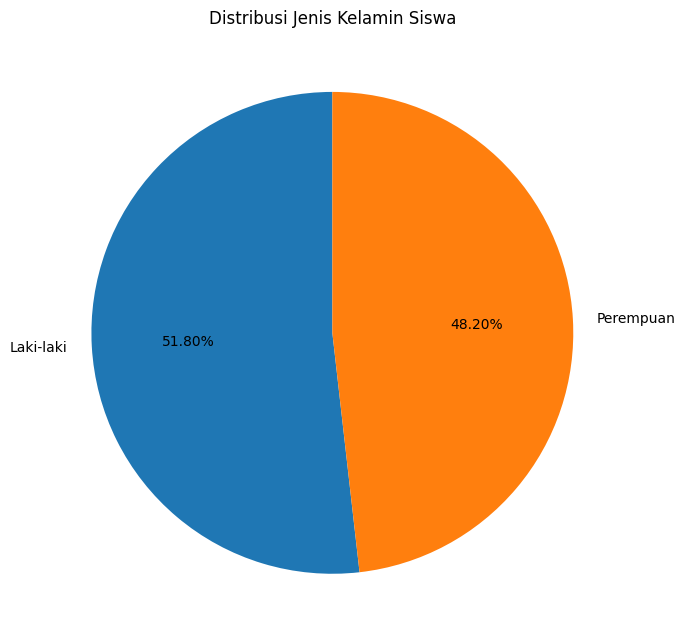

In [ ]:
#Distribusi jenis kelamin
distribusi_jk = data["Jenis Kelamin"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    distribusi_jk.values,
    labels=distribusi_jk.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Distribusi Jenis Kelamin Siswa")
plt.tight_layout()
plt.show()

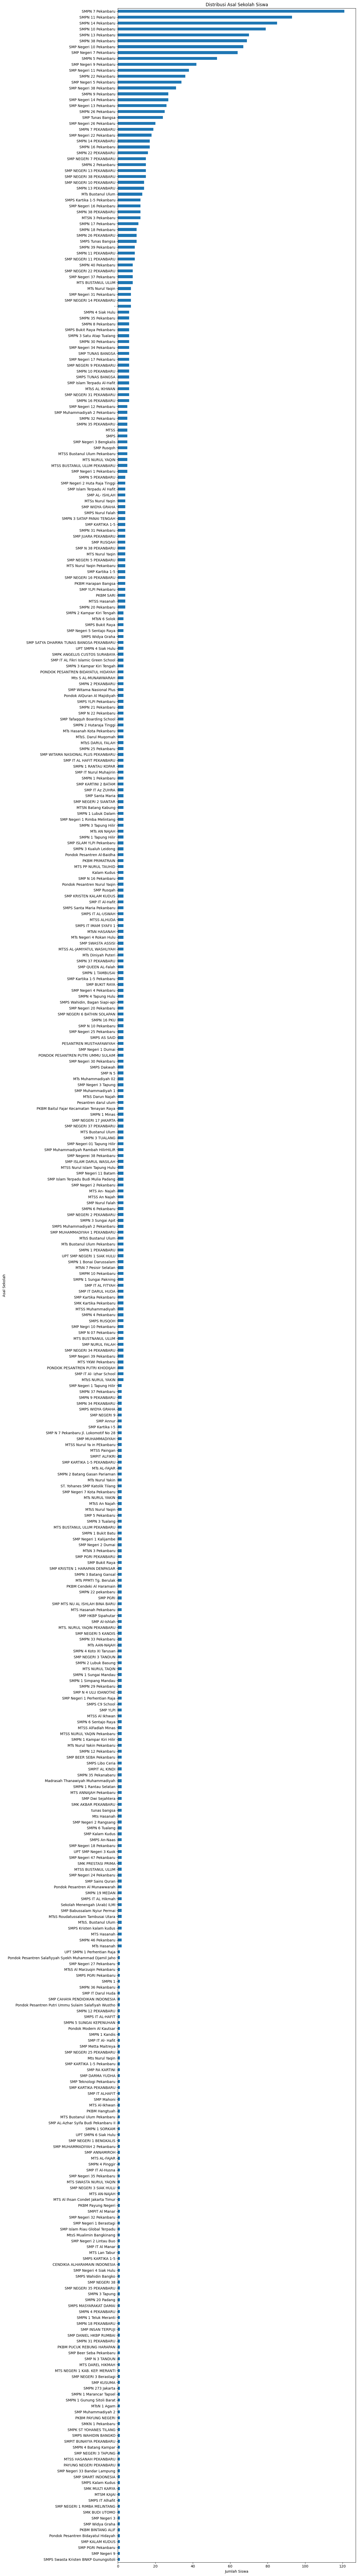

In [ ]:
#Distibusi asal sekolah
distribusi_sekolah = data["Asal Sekolah"].value_counts()

plt.figure(figsize=(14, 100))

distribusi_sekolah.sort_values().plot(
    kind="barh"
)

plt.title("Distribusi Asal Sekolah Siswa")
plt.xlabel("Jumlah Siswa")
plt.ylabel("Asal Sekolah")
plt.tight_layout()
plt.show()

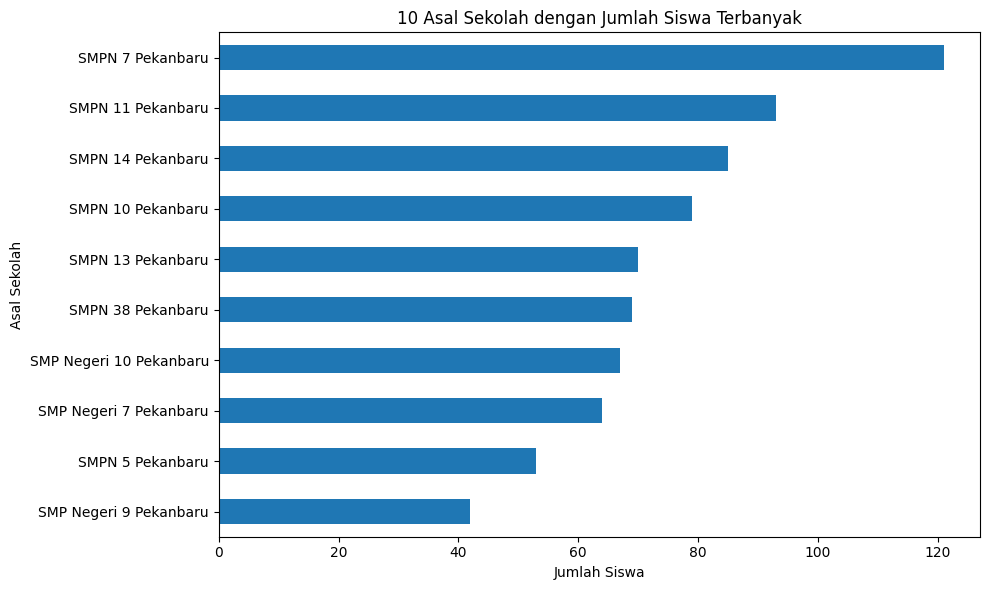

In [ ]:
top_10_sekolah = data["Asal Sekolah"].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_10_sekolah.sort_values().plot(
    kind="barh"
)

plt.title("10 Asal Sekolah dengan Jumlah Siswa Terbanyak")
plt.xlabel("Jumlah Siswa")
plt.ylabel("Asal Sekolah")
plt.tight_layout()
plt.show()

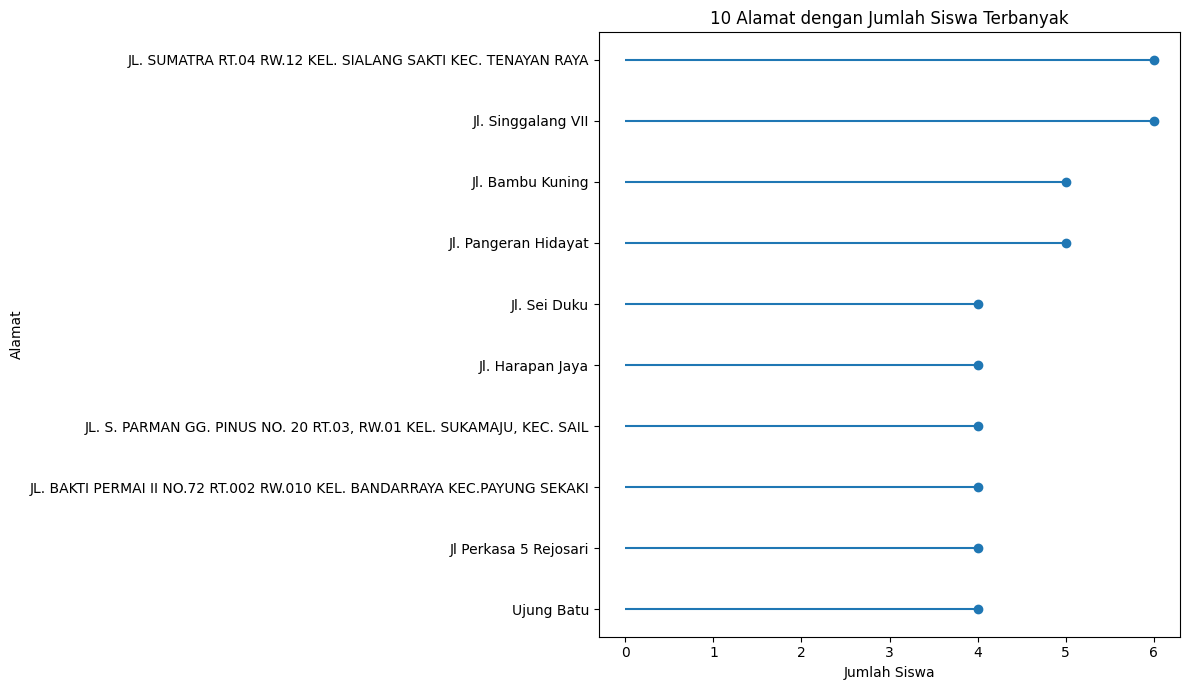

In [ ]:
top_10_alamat = data["Alamat"].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 7))

y = range(len(top_10_alamat))

plt.hlines(
    y=y,
    xmin=0,
    xmax=top_10_alamat.values
)

plt.plot(
    top_10_alamat.values,
    y,
    "o"
)

plt.yticks(
    y,
    top_10_alamat.index
)

plt.xlabel("Jumlah Siswa")
plt.ylabel("Alamat")
plt.title("10 Alamat dengan Jumlah Siswa Terbanyak")

plt.tight_layout()
plt.show()

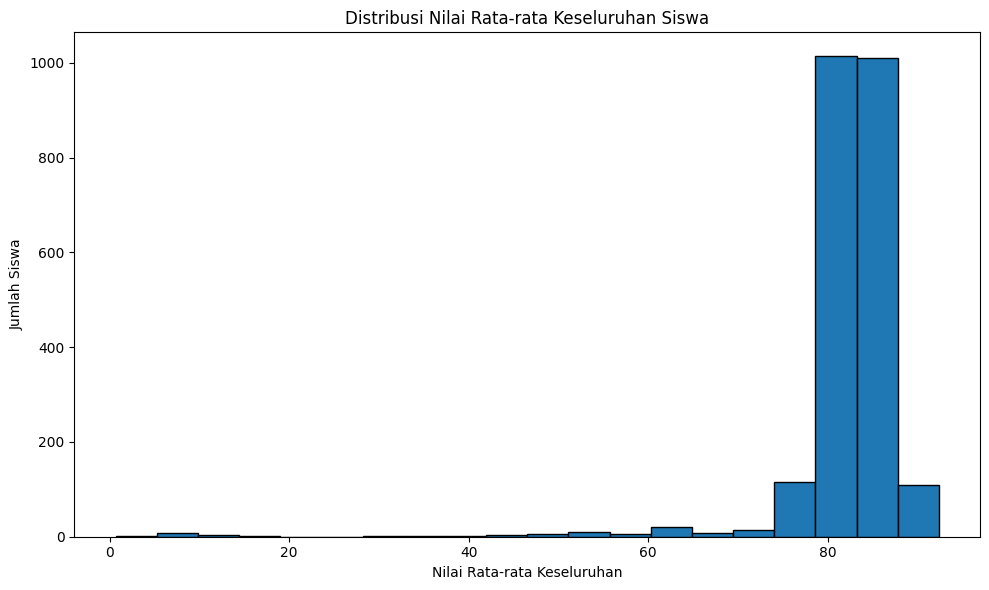

In [ ]:
#Distribusi nilai rata-rata keseluruhan
plt.figure(figsize=(10, 6))

plt.hist(
    data["Rata-rata (Keseluruhan)"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribusi Nilai Rata-rata Keseluruhan Siswa")
plt.xlabel("Nilai Rata-rata Keseluruhan")
plt.ylabel("Jumlah Siswa")

plt.tight_layout()
plt.show()

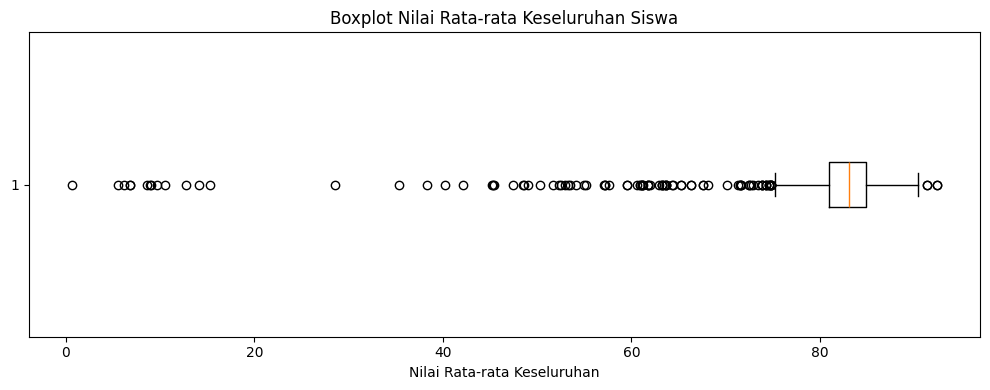

In [ ]:
#Outlier nilai rata-rata
plt.figure(figsize=(10, 4))

plt.boxplot(
    data["Rata-rata (Keseluruhan)"].dropna(),
    vert=False
)

plt.title("Boxplot Nilai Rata-rata Keseluruhan Siswa")
plt.xlabel("Nilai Rata-rata Keseluruhan")

plt.tight_layout()
plt.show()

/tmp/ipykernel_464/1391865648.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


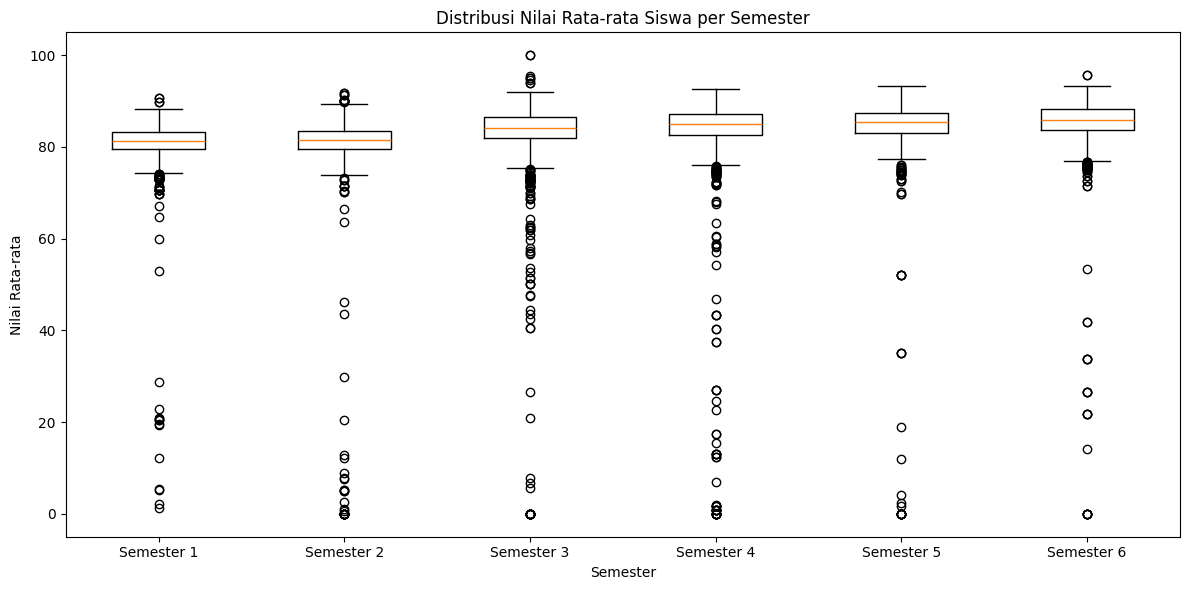

In [ ]:
#Distribusi nilai rata-rata semester 1-6
kolom_semester = [
    "Rata-rata (Semester 1)",
    "Rata-rata (Semester 2)",
    "Rata-rata (Semester 3)",
    "Rata-rata (Semester 4)",
    "Rata-rata (Semester 5)",
    "Rata-rata (Semester 6)"
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    [data[kolom].dropna() for kolom in kolom_semester],
    labels=["Semester 1", "Semester 2", "Semester 3",
            "Semester 4", "Semester 5", "Semester 6"]
)

plt.title("Distribusi Nilai Rata-rata Siswa per Semester")
plt.xlabel("Semester")
plt.ylabel("Nilai Rata-rata")

plt.tight_layout()
plt.show()

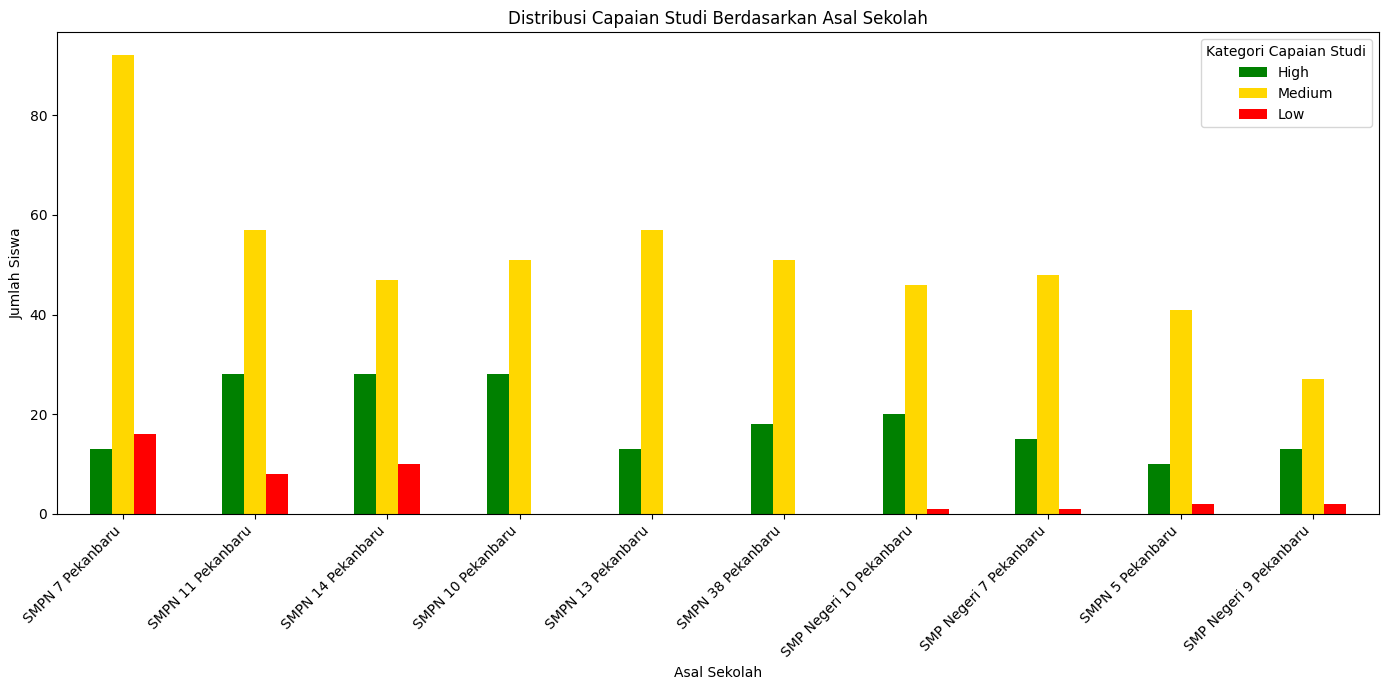

In [ ]:
#Distribusi capaian studi berdasarkan asal sekolah
target_sementara = np.where(
    data["Rata-rata (Keseluruhan)"] > 85,
    "High",
    np.where(
        data["Rata-rata (Keseluruhan)"] >= 78,
        "Medium",
        "Low"
    )
)

# Membuat data sementara tanpa mengubah data asli
eda_sekolah = data[["Asal Sekolah"]].copy()
eda_sekolah["Target"] = target_sementara

# Ambil 10 sekolah dengan jumlah siswa terbanyak
top_sekolah = eda_sekolah["Asal Sekolah"].value_counts().head(10).index

distribusi_sekolah = pd.crosstab(
    eda_sekolah["Asal Sekolah"],
    eda_sekolah["Target"]
).reindex(top_sekolah, fill_value=0)

# Pastikan urutan kategori
distribusi_sekolah = distribusi_sekolah.reindex(
    columns=["High", "Medium", "Low"],
    fill_value=0
)

# Grafik
ax = distribusi_sekolah.plot(
    kind="bar",
    figsize=(14, 7),
    color=["green", "gold", "red"]
)

plt.title("Distribusi Capaian Studi Berdasarkan Asal Sekolah")
plt.xlabel("Asal Sekolah")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Kategori Capaian Studi"
)

plt.tight_layout()
plt.show()

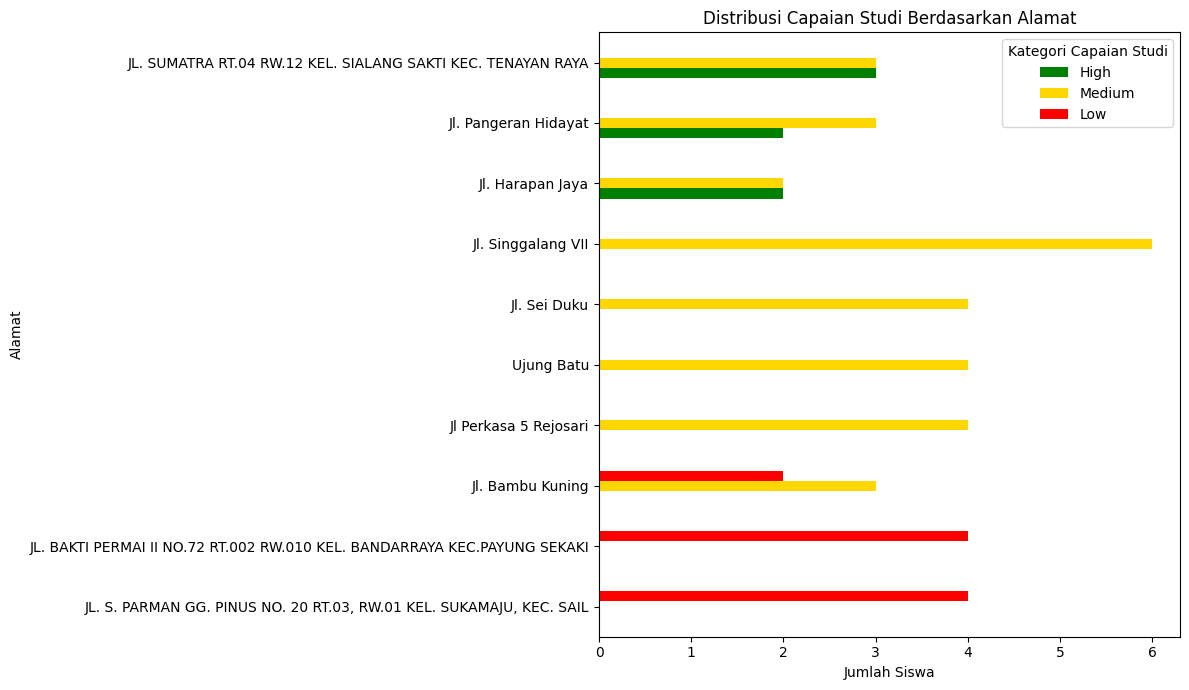

In [ ]:
#Distribusi capaian studi berdasarkan alamat
eda_alamat = data[["Alamat"]].copy()
eda_alamat["Target"] = target_sementara

# 10 alamat dengan jumlah siswa terbanyak
top_alamat = eda_alamat["Alamat"].value_counts().head(10).index

distribusi_alamat = pd.crosstab(
    eda_alamat["Alamat"],
    eda_alamat["Target"]
).reindex(top_alamat, fill_value=0)

# Urutan kategori
distribusi_alamat = distribusi_alamat.reindex(
    columns=["High", "Medium", "Low"],
    fill_value=0
)

# Grafik horizontal
ax = distribusi_alamat.sort_values(
    by=["High", "Medium", "Low"]
).plot(
    kind="barh",
    figsize=(12, 7),
    color=["green", "gold", "red"]
)

plt.title("Distribusi Capaian Studi Berdasarkan Alamat")
plt.xlabel("Jumlah Siswa")
plt.ylabel("Alamat")

plt.legend(title="Kategori Capaian Studi")

plt.tight_layout()
plt.show()

# Prapemrosesan Data -> Pembersihan Data

In [ ]:
# Menyeragamkan format data kategorikal
kolom_kategorikal = [
    "Jenis Kelamin",
    "Asal Sekolah",
    "Alamat"
]

for kolom in kolom_kategorikal:
    data[kolom] = data[kolom].astype(str).str.strip()

In [ ]:
print(data.dtypes)

No.                          int64
NIS                          int64
NISN                         int64
Nama Siswa                  object
Jenis Kelamin               object
Kelas                       object
Tingkat                      int64
Wali Kelas                  object
Rata-rata (Semester 1)     float64
Rata-rata (Semester 2)     float64
Rata-rata (Semester 3)     float64
Rata-rata (Semester 4)     float64
Rata-rata (Semester 5)     float64
Rata-rata (Semester 6)     float64
Rata-rata (Keseluruhan)    float64
Rangking (per jurusan)       int64
Rangking (keseluruhan)       int64
Alamat                      object
Asal Sekolah                object
Ketgori Capaian Siswa       object
Tahun Ajaran                object
dtype: object


In [ ]:
# Menampilkan seluruh nama asal sekolah
sekolah = sorted(data["Asal Sekolah"].dropna().unique())

for i, nama in enumerate(sekolah, 1):
    print(i, ":", nama)

1 : -
2 : CENDIKIA ALHARAMAIN INDONESIA
3 : Kalam Kudus
4 : MTS AL-FAJAR
5 : MTS AN-NAJAH
6 : MTS ANNAJAH Pekanbaru
7 : MTS Al Ihsan Condet Jakarta Timur
8 : MTS Al-Ikhwan
9 : MTS An- Najah
10 : MTS BUSTANUL ULUM
11 : MTS BUSTANUL ULUM PEKANBARU
12 : MTS BUSTNANUL ULUM
13 : MTS Bustanul Ulum
14 : MTS Bustanul Ulum Pekanbaru
15 : MTS DAREL HIKMAH
16 : MTS Hasanah
17 : MTS Hasanah Pekanbaru
18 : MTS Lan Tabur
19 : MTS NEGERI 1 KAB. KEP. MERANTI
20 : MTS NURUL TAQIN
21 : MTS NURUL YAQIN
22 : MTS Nurul Yaqin
23 : MTS Nurul Yaqin Pekanbaru
24 : MTS PP NURUL TAUHID
25 : MTS SWASTA NURUL YAQIN
26 : MTS YKWI Pekanbaru
27 : MTS. NURUL YAQIN PEKANBARU
28 : MTSM KAJAI
29 : MTSN 3 Pekanbaru
30 : MTSN Batang Kabung
31 : MTSS
32 : MTSS AL-JAMIYATUL WASHLIYAH
33 : MTSS ALHUDA
34 : MTSS Al Ikhwan
35 : MTSS AlFadlah Minas
36 : MTSS An Najah
37 : MTSS BUSTANUL ULUM
38 : MTSS BUSTANUL ULUM PEKANBARU
39 : MTSS Bustanul Ulum Pekanbaru
40 : MTSS HASANAH PEKANBARU
41 : MTSS Hasanah
42 : MTSS Muhammadiyah
43 

In [ ]:
import re

def normalisasi_sekolah(nama):
    nama = str(nama).strip()

    # Menyeragamkan huruf
    nama = nama.upper()

    # Menghapus spasi berlebih
    nama = re.sub(r'\s+', ' ', nama)

    # Menyeragamkan beberapa bentuk singkatan
    nama = re.sub(r'^SMP\s*N\s*', 'SMP NEGERI ', nama)
    nama = re.sub(r'^SMPN\s*', 'SMP NEGERI ', nama)

    # Memperbaiki beberapa kesalahan penulisan umum
    nama = nama.replace('SMP NEGERI 01 ', 'SMP NEGERI 1 ')
    nama = nama.replace('SMP NEGERI 02 ', 'SMP NEGERI 2 ')
    nama = nama.replace('SMP NEGERI 03 ', 'SMP NEGERI 3 ')
    nama = nama.replace('SMP NEGERI 04 ', 'SMP NEGERI 4 ')
    nama = nama.replace('SMP NEGERI 05 ', 'SMP NEGERI 5 ')
    nama = nama.replace('SMP NEGERI 06 ', 'SMP NEGERI 6 ')
    nama = nama.replace('SMP NEGERI 07 ', 'SMP NEGERI 7 ')
    nama = nama.replace('SMP NEGERI 08 ', 'SMP NEGERI 8 ')
    nama = nama.replace('SMP NEGERI 09 ', 'SMP NEGERI 9 ')

    return nama

data["Asal Sekolah"] = data["Asal Sekolah"].apply(normalisasi_sekolah)

In [ ]:
print("Jumlah kategori Asal Sekolah setelah penyeragaman:")
print(data["Asal Sekolah"].nunique())

Jumlah kategori Asal Sekolah setelah penyeragaman:
352


In [ ]:
sekolah_bersih = sorted(data["Asal Sekolah"].unique())

for i, nama in enumerate(sekolah_bersih, 1):
    print(i, ":", nama)

1 : -
2 : CENDIKIA ALHARAMAIN INDONESIA
3 : KALAM KUDUS
4 : MADRASAH THANAWIYAH MUHAMMADIYAH
5 : MTS AAN-NAJAH
6 : MTS AL IHSAN CONDET JAKARTA TIMUR
7 : MTS AL-FAJAR
8 : MTS AL-IKHWAN
9 : MTS AN NAJAH
10 : MTS AN- NAJAH
11 : MTS AN-NAJAH
12 : MTS ANNAJAH PEKANBARU
13 : MTS BUSTANUL ULUM
14 : MTS BUSTANUL ULUM PEKANBARU
15 : MTS BUSTNANUL ULUM
16 : MTS DAREL HIKMAH
17 : MTS DINIYAH PUTERI
18 : MTS HASANAH
19 : MTS HASANAH KOTA PEKANBARU
20 : MTS HASANAH PEKANBARU
21 : MTS LAN TABUR
22 : MTS MUHAMMADIYAH 02
23 : MTS NEGERI 1 KAB. KEP. MERANTI
24 : MTS NEGERI 4 ROKAN HULU
25 : MTS NURUL TAQIN
26 : MTS NURUL YAKIN
27 : MTS NURUL YAKIN PEKANBARU
28 : MTS NURUL YAQIN
29 : MTS NURUL YAQIN PEKANBARU
30 : MTS PP NURUL TAUHID
31 : MTS PPMTI TG. BERULAK
32 : MTS S AL-MUNAWWARAH
33 : MTS SWASTA NURUL YAQIN
34 : MTS YKWI PEKANBARU
35 : MTS. NURUL YAQIN PEKANBARU
36 : MTSM KAJAI
37 : MTSN 1 AGAM
38 : MTSN 3 PEKANBARU
39 : MTSN 6 SOLOK
40 : MTSN 7 PESISIR SELATAN
41 : MTSN BATANG KABUNG
42 : MTSN HAS

In [ ]:
from difflib import get_close_matches

sekolah = sorted(data["Asal Sekolah"].dropna().unique())

for nama in sekolah:
    mirip = get_close_matches(nama, sekolah, n=5, cutoff=0.85)

    if len(mirip) > 1:
        print("\n", nama)
        print("   ", mirip)


 MTS AAN-NAJAH
    ['MTS AAN-NAJAH', 'MTS AN-NAJAH', 'MTS AN- NAJAH', 'MTS AN NAJAH']

 MTS AL-IKHWAN
    ['MTS AL-IKHWAN', 'MTSS AL IKHWAN']

 MTS AN NAJAH
    ['MTS AN NAJAH', 'MTSS AN NAJAH', 'MTS AN- NAJAH', 'MTS AN-NAJAH', 'MTS AAN-NAJAH']

 MTS AN- NAJAH
    ['MTS AN- NAJAH', 'MTS AN-NAJAH', 'MTS AN NAJAH', 'MTSS AN NAJAH', 'MTS AAN-NAJAH']

 MTS AN-NAJAH
    ['MTS AN-NAJAH', 'MTS AN- NAJAH', 'MTS AAN-NAJAH', 'MTS AN NAJAH', 'MTSS AN NAJAH']

 MTS ANNAJAH PEKANBARU
    ['MTS ANNAJAH PEKANBARU', 'MTS HASANAH PEKANBARU']

 MTS BUSTANUL ULUM
    ['MTS BUSTANUL ULUM', 'MTSS BUSTANUL ULUM', 'MTS BUSTNANUL ULUM', 'MTSS. BUSTANUL ULUM']

 MTS BUSTANUL ULUM PEKANBARU
    ['MTS BUSTANUL ULUM PEKANBARU', 'MTSS BUSTANUL ULUM PEKANBARU']

 MTS BUSTNANUL ULUM
    ['MTS BUSTNANUL ULUM', 'MTS BUSTANUL ULUM', 'MTSS BUSTANUL ULUM', 'MTSS. BUSTANUL ULUM']

 MTS HASANAH
    ['MTS HASANAH', 'MTSS HASANAH', 'MTSN HASANAH']

 MTS HASANAH KOTA PEKANBARU
    ['MTS HASANAH KOTA PEKANBARU', 'MTS HASANAH 

In [ ]:
# Menyeragamkan format nama sekolah
data["Asal Sekolah"] = (
    data["Asal Sekolah"]
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(".", "", regex=False)
)

print("Jumlah kategori setelah penyeragaman format:")
print(data["Asal Sekolah"].nunique())

Jumlah kategori setelah penyeragaman format:
350


In [ ]:
print("Jumlah kategori Asal Sekolah setelah cleaning:")
print(data["Asal Sekolah"].nunique())

Jumlah kategori Asal Sekolah setelah cleaning:
350


In [ ]:
print("Jumlah kategori sebelum cleaning:", 350)
print("Jumlah kategori setelah cleaning:", ...)

Jumlah kategori sebelum cleaning: 350
Jumlah kategori setelah cleaning: Ellipsis


In [ ]:
print("Jumlah kategori sebelum cleaning:", 350)
print("Jumlah kategori setelah cleaning:", data["Asal Sekolah"].nunique())

Jumlah kategori sebelum cleaning: 350
Jumlah kategori setelah cleaning: 350


In [ ]:
print("Jumlah kategori Asal Sekolah saat ini:",
      data["Asal Sekolah"].nunique())

Jumlah kategori Asal Sekolah saat ini: 350


In [ ]:
jumlah_sekolah_akhir = data["Asal Sekolah"].nunique()

print("Jumlah kategori Asal Sekolah setelah cleaning:",
      jumlah_sekolah_akhir)

Jumlah kategori Asal Sekolah setelah cleaning: 350


In [ ]:
print(data["Alamat"].value_counts())

Alamat
JL. SUMATRA RT.04 RW.12 KEL. SIALANG SAKTI KEC. TENAYAN RAYA                                      6
Jl. Singgalang VII                                                                                6
Jl. Pangeran Hidayat                                                                              5
Jl. Bambu Kuning                                                                                  5
JL. S. PARMAN GG. PINUS NO. 20 RT.03, RW.01 KEL. SUKAMAJU, KEC. SAIL                              4
                                                                                                 ..
Jl. Serasi RT.05 RW.11 Kel. Air Dingin Kec. Bukit Raya Pekanbaru                                  1
Jl. Belimbing Gg. Anggur I No. 12 RT.03 RW.06 Kel. Wonorejo Kec. Marpoyan Damai Kota Pekanbaru    1
Jl. Katio Ujung RT.05 RW. 19 Kel. Tangkerang Tengah Kec. Marpoyan Damai Pekanbaru                 1
Jl. S.Parman Gg. Vinus RT.03 RW.01 Kel. Sukamaju Kec. Sail                                   

In [ ]:
# Menyeragamkan format alamat
data["Alamat"] = (
    data["Alamat"]
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(".", "", regex=False)
)

print("Jumlah alamat setelah penyeragaman format:")
print(data["Alamat"].nunique())

Jumlah alamat setelah penyeragaman format:
1091


In [ ]:
print(data["Alamat"].value_counts())

Alamat
JL SUMATRA RT04 RW12 KEL SIALANG SAKTI KEC TENAYAN RAYA                               6
JL SINGGALANG VII                                                                     6
JL HARAPAN JAYA                                                                       5
JL PANGERAN HIDAYAT                                                                   5
JL SUMBER SARI                                                                        5
                                                                                     ..
JL SENTOSA GG PRIBADI RT 04 RW 11 KEL TANGKERANG UTARA KEC BUKIT RAYA PEKANBARU       1
JL HASANUDDIN GG ABIDIN 1 A NO5 RT01 RW04 KEL RINTIS KEC LIMA PULUH KOTA PEKANBARU    1
JL KALI PUTIH NO 55 RT01 RW07 KEL TANGKERANG UTARA KEC BUKIT RAYA KOTA PEKANBARU      1
JL TERATAI NO 1 RT02 RW26 KEL SIDOMULYO BARAT KEC TAMPAN KOTA PEKANBARU               1
JL AIR DINGIN GG MDA NO3 RT03 RW04 KEL AIR DINGIN KEC BUKIT RAYA PEKANBARU            1
Name: count, Length: 1091

In [ ]:
print("Jumlah alamat setelah cleaning:",
      data["Alamat"].nunique())

Jumlah alamat setelah cleaning: 1091


In [ ]:
print("Jumlah data siswa:", len(data))
print("Jumlah baris dan kolom:", data.shape)

Jumlah data siswa: 2332
Jumlah baris dan kolom: (2332, 21)


In [ ]:
print("Jumlah data:", len(data))

print("\nJumlah data per tahun ajaran:")
print(data["Tahun Ajaran"].value_counts().sort_index())

Jumlah data: 2332

Jumlah data per tahun ajaran:
Tahun Ajaran
2021-2022    528
2022-2023    485
2023-2024    475
2024-2025    439
2025-2026    405
Name: count, dtype: int64


In [ ]:
data["Asal Sekolah"] = data["Asal Sekolah"].replace({
    "SMP NEGERI EGERI 5 PEKANBARU": "SMP NEGERI 5 PEKANBARU"
})

In [ ]:
data["Asal Sekolah"] = data["Asal Sekolah"].str.replace(
    "NEGERI EGERI",
    "NEGERI",
    regex=False
)

In [ ]:
daftar_sekolah = (
    data["Asal Sekolah"]
    .value_counts()
    .sort_index()
)

print("Jumlah kategori unik:", data["Asal Sekolah"].nunique())

display(daftar_sekolah.to_frame("Jumlah Siswa"))

Jumlah kategori unik: 320


,Jumlah Siswa
Asal Sekolah,
-,7
CENDIKIA ALHARAMAIN INDONESIA,1
KALAM KUDUS,3
MADRASAH THANAWIYAH MUHAMMADIYAH,2
MTS AAN-NAJAH,2
...,...
UPT SMP NEGERI 1 SIAK HULU,3
UPT SMP NEGERI 3 KUOK,2
UPT SMPN 1 PERHENTIAN RAJA,1


In [ ]:
data[data["Asal Sekolah"] == "-"][
    ["Asal Sekolah", "Nama Siswa", "Alamat"]
]

,Asal Sekolah,Nama Siswa,Alamat
158,-,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
183,-,JOVANDA YUSEP,JL KAPUR GG H JAFAR
414,-,MUSTAQIM,-
835,-,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
892,-,YUDHA ANGGARA,JL HANGTUAH GG MURNI
1476,-,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
1576,-,KHALIP ABYAN ARIEF,JL HANGTUAH UJUNG PERUM GREENDLAND NO A4


In [ ]:
data["Asal Sekolah"] = data["Asal Sekolah"].replace(
    "-",
    "TIDAK TERIDENTIFIKASI"
)

In [ ]:
tidak_teridentifikasi = data[
    (data["Asal Sekolah"] == "-") |
    (data["Alamat"] == "-")
]

print("Jumlah siswa dengan Asal Sekolah atau Alamat tidak tersedia:",
      len(tidak_teridentifikasi))

display(
    tidak_teridentifikasi[
        ["Asal Sekolah", "Alamat"]
    ]
)

Jumlah siswa dengan Asal Sekolah atau Alamat tidak tersedia: 1


,Asal Sekolah,Alamat
414,TIDAK TERIDENTIFIKASI,-


In [ ]:
data["Asal Sekolah"] = data["Asal Sekolah"].replace(
    "-",
    "TIDAK TERIDENTIFIKASI"
)

print("Jumlah Asal Sekolah tidak teridentifikasi:",
      (data["Asal Sekolah"] == "TIDAK TERIDENTIFIKASI").sum())

display(
    data[
        data["Asal Sekolah"] == "TIDAK TERIDENTIFIKASI"
    ][["Asal Sekolah", "Nama Siswa", "Alamat"]]
)

Jumlah Asal Sekolah tidak teridentifikasi: 7


,Asal Sekolah,Nama Siswa,Alamat
158,TIDAK TERIDENTIFIKASI,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
183,TIDAK TERIDENTIFIKASI,JOVANDA YUSEP,JL KAPUR GG H JAFAR
414,TIDAK TERIDENTIFIKASI,MUSTAQIM,-
835,TIDAK TERIDENTIFIKASI,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
892,TIDAK TERIDENTIFIKASI,YUDHA ANGGARA,JL HANGTUAH GG MURNI
1476,TIDAK TERIDENTIFIKASI,NURLIYANA,"JL BARUNA RT03 RW19 KEL TANGKERANG TENGAH, KEC..."
1576,TIDAK TERIDENTIFIKASI,KHALIP ABYAN ARIEF,JL HANGTUAH UJUNG PERUM GREENDLAND NO A4


In [ ]:
# Pemeriksaan tipe data
print("Tipe data setiap atribut:")
print(data.dtypes)

Tipe data setiap atribut:
No.                          int64
NIS                          int64
NISN                         int64
Nama Siswa                  object
Jenis Kelamin               object
Kelas                       object
Tingkat                      int64
Wali Kelas                  object
Rata-rata (Semester 1)     float64
Rata-rata (Semester 2)     float64
Rata-rata (Semester 3)     float64
Rata-rata (Semester 4)     float64
Rata-rata (Semester 5)     float64
Rata-rata (Semester 6)     float64
Rata-rata (Keseluruhan)    float64
Rangking (per jurusan)       int64
Rangking (keseluruhan)       int64
Alamat                      object
Asal Sekolah                object
Ketgori Capaian Siswa       object
Tahun Ajaran                object
dtype: object


# Penentuan Label

In [ ]:
#penentuan label
def tentukan_label(nilai):
    if nilai > 85:
        return "High"
    elif nilai >= 78:
        return "Medium"
    else:
        return "Low"


data["Target"] = data["Rata-rata (Keseluruhan)"].apply(tentukan_label)

print("Distribusi label capaian studi:")
print(data["Target"].value_counts())

Distribusi label capaian studi:
Target
Medium    1605
High       560
Low        167
Name: count, dtype: int64


In [ ]:
# Seleksi atribut

fitur = [
    "Asal Sekolah",
    "Alamat"
]

target = "Target"

X = data[fitur].copy()
y = data[target].copy()

print("Atribut input (X):")
print(X.columns.tolist())

print("\nVariabel target (Y):")
print(y.name)

print("\nUkuran data X:", X.shape)
print("Ukuran data Y:", y.shape)

Atribut input (X):
['Asal Sekolah', 'Alamat']

Variabel target (Y):
Target

Ukuran data X: (2332, 2)
Ukuran data Y: (2332,)


# Seleksi atribut

In [ ]:
fitur = [
    "Asal Sekolah",
    "Alamat"
]

target = "Target"

X = data[fitur].copy()
y = data[target].copy()

print("Atribut input (X):")
print(X.columns.tolist())

print("\nVariabel target (Y):")
print(y.name)

print("\nUkuran data X:", X.shape)
print("Ukuran data Y:", y.shape)

Atribut input (X):
['Asal Sekolah', 'Alamat']

Variabel target (Y):
Target

Ukuran data X: (2332, 2)
Ukuran data Y: (2332,)


In [ ]:
# Melihat jumlah data pada setiap kategori Asal Sekolah
print("Distribusi Asal Sekolah:")
print(data["Asal Sekolah"].value_counts())

# Melihat jumlah data pada setiap kategori Alamat
print("\nDistribusi Alamat:")
print(data["Alamat"].value_counts())

Distribusi Asal Sekolah:
Asal Sekolah
SMP NEGERI 7 PEKANBARU             222
SMP NEGERI 10 PEKANBARU            169
SMP NEGERI 11 PEKANBARU            149
SMP NEGERI 14 PEKANBARU            136
SMP NEGERI 38 PEKANBARU            131
                                  ... 
SMP CAHAYA PENDIDIKAN INDONESIA      1
SMP NEGERI 36 PEKANBARU              1
SMP NEGERI 1                         1
SMPS PGRI PEKANBARU                  1
MTSS AL MARZUQIN PEKANBARU           1
Name: count, Length: 320, dtype: int64

Distribusi Alamat:
Alamat
JL SUMATRA RT04 RW12 KEL SIALANG SAKTI KEC TENAYAN RAYA                               6
JL SINGGALANG VII                                                                     6
JL HARAPAN JAYA                                                                       5
JL PANGERAN HIDAYAT                                                                   5
JL SUMBER SARI                                                                        5
                           

In [ ]:
print("Asal Sekolah dengan jumlah siswa <= 3:")
print(data["Asal Sekolah"].value_counts()[
    data["Asal Sekolah"].value_counts() <= 3
])

print("\nAlamat dengan jumlah siswa <= 3:")
print(data["Alamat"].value_counts()[
    data["Alamat"].value_counts() <= 3
])

Asal Sekolah dengan jumlah siswa <= 3:
Asal Sekolah
SMP MUHAMMADIYAH 1                 3
SMP NEGERI 3 KUALUH LEIDONG        3
MTSN 6 SOLOK                       3
SMPS BUKIT RAYA                    3
SMP NEGERI 2 KAMPAR KIRI TENGAH    3
                                  ..
SMP CAHAYA PENDIDIKAN INDONESIA    1
SMP NEGERI 36 PEKANBARU            1
SMP NEGERI 1                       1
SMPS PGRI PEKANBARU                1
MTSS AL MARZUQIN PEKANBARU         1
Name: count, Length: 243, dtype: int64

Alamat dengan jumlah siswa <= 3:
Alamat
JL HASANUDDIN GG MUJAHADAH NO19 RT03 RW02 KEL RINTIS KEC LIMA PULUH                   3
JL PROYEK BARU NO 34 RT 05 RW 06, TANJUNG RHU, LIMAPULUH                              3
JL KESADARAN RT02 RW10 KEL TANGKERANG LABUAI                                          3
JL DATUK LAKSAMANA RT03 RW04 KEL SUKA MAJU KEC SAIL                                   3
JLN LUMBA LUMBA NO 54E                                                                3
                     

In [ ]:
# Pemeriksaan data setelah seleksi atribut

print("Jumlah data sebelum pengurangan:", len(data))

# Memastikan tidak ada data dengan target kosong
data_reduksi = data.dropna(subset=["Asal Sekolah", "Alamat", "Target"])

print("Jumlah data setelah pemeriksaan:", len(data_reduksi))
print("Jumlah data yang dikurangi:", len(data) - len(data_reduksi))

Jumlah data sebelum pengurangan: 2332
Jumlah data setelah pemeriksaan: 2332
Jumlah data yang dikurangi: 0


In [ ]:
# Melihat beberapa contoh alamat
print(data["Alamat"].head(30).to_string(index=False))

             JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
JL SETIA BUDI GG GEMURUH NO 47 KEL PESISIR KEC ...
                     JLUSAHA SUMBER SARI GGAMD VII
                          JL SUMBER SARI GG ARAFAH
JL CEMARA GG CEMARA 2 RT 002 RW005 KEL SUKAMAJU...
                                       JLFLAMBOYAN
JL AMD NO 172 RT 007 RW 005 KEL TANJUNG RHU KEC...
JL TANJUNG BATU NO 74 RT 001 RW 002, KELURAHAN ...
                               JL TEUKU UMAR NO 12
JL MADYA PURI PERUM PURI SEJAHTERA B/8 RT/01/RW...
RT 03 RW 02 KELURAHAN LEMBAH SARI KECAMATAN RUM...
RT 01 RW 02 KELURAHAN INDUSTRI TENAYAN, KECAMAT...
JL TANJUNG DATUK, GG USAHA UJUNG KEL RINTIS KEC...
JL KAMPAR GG SEMPIT, RT 03, RW 01, KELURAHAN SE...
                              JL KUANTAN 7, NO 88A
                                   AFD II AEK RASO
JL KUANTAN VII NO 8 A RT 04 RW 04 KELURAHAN TAN...
                              JL TEUKU UMAR NO82 E
JL S PARMAN GG PINUS NO 20 RT03, RW01 KEL SUKAM...
                               

In [ ]:
import re

def ambil_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Mencari bagian setelah KEC atau KECAMATAN
    pola = r'\bKEC(?:AMATAN)?\s+([^,]+)'
    hasil = re.search(pola, alamat)

    if hasil:
        return hasil.group(1).strip()

    return None

data["Wilayah Tempat Tinggal"] = data["Alamat"].apply(ambil_kecamatan)

print("Contoh hasil transformasi:")
print(
    data[["Alamat", "Wilayah Tempat Tinggal"]]
    .head(30)
    .to_string(index=False)
)

Contoh hasil transformasi:
                                                                          Alamat Wilayah Tempat Tinggal
                                           JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9                   None
                       JL SETIA BUDI GG GEMURUH NO 47 KEL PESISIR KEC LIMA PULUH             LIMA PULUH
                                                   JLUSAHA SUMBER SARI GGAMD VII                   None
                                                        JL SUMBER SARI GG ARAFAH                   None
                        JL CEMARA GG CEMARA 2 RT 002 RW005 KEL SUKAMAJU KEC SAIL                   SAIL
                                                                     JLFLAMBOYAN                   None
                      JL AMD NO 172 RT 007 RW 005 KEL TANJUNG RHU KEC LIMA PULUH             LIMA PULUH
    JL TANJUNG BATU NO 74 RT 001 RW 002, KELURAHAN PESISIR, KECAMATAN LIMA PULUH             LIMA PULUH
                                     

In [ ]:
print("\nJumlah data yang berhasil mendapatkan wilayah:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah data yang belum mendapatkan wilayah:")
print(data["Wilayah Tempat Tinggal"].isna().sum())

print("\nJumlah wilayah unik:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDaftar wilayah:")
print(data["Wilayah Tempat Tinggal"].value_counts())


Jumlah data yang berhasil mendapatkan wilayah:
1377

Jumlah data yang belum mendapatkan wilayah:
955

Jumlah wilayah unik:
70

Daftar wilayah:
Wilayah Tempat Tinggal
TENAYAN RAYA                      311
LIMA PULUH                        190
BUKIT RAYA                         92
TENAYAN RAYA KOTA PEKANBARU        92
TENAYAN RAYA PEKANBARU             76
                                 ... 
BINAWIDYA PEKANBARU                 2
MAHARATU PEKANBARU                  1
BANGKO PUSAKO KAB ROKAN HILIR       1
TEMBILAHAN KAB INDRAGIRI HILIR      1
PEKANBARUKOTA                       1
Name: count, Length: 70, dtype: int64


In [ ]:
# Melihat alamat yang belum berhasil mendapatkan wilayah

alamat_belum = data.loc[
    data["Wilayah Tempat Tinggal"].isna(),
    "Alamat"
]

print("Jumlah alamat yang belum mendapatkan wilayah:", len(alamat_belum))
print("\nContoh alamat yang belum teridentifikasi:")
print(alamat_belum.head(100).to_string(index=False))

Jumlah alamat yang belum mendapatkan wilayah: 955

Contoh alamat yang belum teridentifikasi:
             JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
                     JLUSAHA SUMBER SARI GGAMD VII
                          JL SUMBER SARI GG ARAFAH
                                       JLFLAMBOYAN
                               JL TEUKU UMAR NO 12
                              JL KUANTAN 7, NO 88A
                                   AFD II AEK RASO
                              JL TEUKU UMAR NO82 E
                                   JL GUNUNG AGUNG
                                      JL INDRAPURI
                              JL LOKOMOTIF 11 NO 3
                                  JL KARYA BERSAMA
                     JL MANDAU KM 48 DANAU LANCANG
                         JL SUTOMO GG SELAMAT NO20
                             JL KUANTAN VII NO 88A
                                   JL KAMPUNG BARU
                JL KANDIS GG IRMALA 3 HARAPAN RAYA
                                        

In [ ]:
import re

def ambil_kelurahan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    pola = r'\b(?:KEL|KELURAHAN)\s+([^,]+)'
    hasil = re.search(pola, alamat)

    if hasil:
        return hasil.group(1).strip()

    return None

data["Kelurahan"] = data["Alamat"].apply(ambil_kelurahan)

print("Jumlah alamat dengan informasi kelurahan:")
print(data["Kelurahan"].notna().sum())

print("\nJumlah kelurahan unik:")
print(data["Kelurahan"].nunique())

print("\nContoh kelurahan:")
print(data["Kelurahan"].value_counts().head(30))

Jumlah alamat dengan informasi kelurahan:
1332

Jumlah kelurahan unik:
220

Contoh kelurahan:
Kelurahan
TANJUNG RHU KEC LIMA PULUH                       67
REJOSARI KEC TENAYAN RAYA                        60
REJOSARI                                         42
TANJUNG RHU                                      39
SIALANG SAKTI KEC TENAYAN RAYA                   36
PESISIR                                          35
PESISIR KEC LIMA PULUH                           33
REJOSARI KEC TENAYAN RAYA PEKANBARU              31
SUKAMAJU KEC SAIL                                26
BENCAH LESUNG KEC TENAYAN RAYA                   24
INDUSTRI TENAYAN KEC TENAYAN RAYA                24
REJOSARI KEC TENAYAN RAYA KOTA PEKANBARU         23
BENCAH LESUNG KEC TENAYAN RAYA KOTA PEKANBARU    20
TANJUNG RHU KEC LIMAPULUH                        20
BAMBU KUNING KEC TENAYAN RAYA                    19
BAMBU KUNING                                     18
TANGKERANG UTARA                                 17
PESISIR KEC 

In [ ]:
import re

def ambil_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Menangkap nama kecamatan setelah KEC atau KECAMATAN
    pola = r'\bKECAMATAN\s+([A-Z ]+?)(?:,|$)|\bKEC\s+([A-Z ]+?)(?:,|$)'
    hasil = re.search(pola, alamat)

    if hasil:
        wilayah = hasil.group(1) if hasil.group(1) else hasil.group(2)

        # Menghilangkan informasi setelah nama wilayah
        wilayah = re.split(
            r'\b(?:KOTA|KAB|KABUPATEN|PEKANBARU)\b',
            wilayah
        )[0]

        return wilayah.strip()

    return None

data["Wilayah Tempat Tinggal"] = data["Alamat"].apply(ambil_kecamatan)

print("Jumlah data yang berhasil mendapatkan wilayah:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah wilayah unik:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDistribusi wilayah:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil mendapatkan wilayah:
1371

Jumlah wilayah unik:
41

Distribusi wilayah:
Wilayah Tempat Tinggal
TENAYAN RAYA                         479
LIMA PULUH                           248
BUKIT RAYA                           139
LIMAPULUH                            113
SAIL                                  89
KULIM                                 43
MARPOYAN DAMAI                        39
SENAPELAN                             32
                                      31
TAMPAN                                18
SIAK HULU                             18
RUMBAI PESISIR                        13
SUKAJADI                              13
TAPUNG HILIR                          11
RUMBAI                                 8
PAYUNG SEKAKI                          8
TAMBANG                                6
TUAH MADANI                            6
BINA WIDYA                             5
TAPUNG HULU                            3
KUBU                                   3
TAPUNG            

In [ ]:
# Daftar kecamatan resmi Kota Pekanbaru
daftar_kecamatan = [
    "BUKIT RAYA",
    "TENAYAN RAYA",
    "KULIM",
    "MARPOYAN DAMAI",
    "PAYUNG SEKAKI",
    "SAIL",
    "SENAPELAN",
    "SUKAJADI",
    "PEKANBARU KOTA",
    "LIMA PULUH",
    "RUMBAI",
    "RUMBAI BARAT",
    "RUMBAI TIMUR",
    "BINA WIDYA",
    "TUAH MADANI"
]

def cari_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Menyeragamkan beberapa penulisan
    alamat = alamat.replace("LIMAPULUH", "LIMA PULUH")
    alamat = alamat.replace("BINAWIDYA", "BINA WIDYA")
    alamat = alamat.replace("TENYAN RAYA", "TENAYAN RAYA")
    alamat = alamat.replace("TENAYAN RAUA", "TENAYAN RAYA")
    alamat = alamat.replace("MARPORAN DAMAI", "MARPOYAN DAMAI")
    alamat = alamat.replace("PEKANBARUKOTA", "PEKANBARU KOTA")

    for kecamatan in daftar_kecamatan:
        if kecamatan in alamat:
            return kecamatan

    return None

data["Wilayah Tempat Tinggal"] = data["Alamat"].apply(cari_kecamatan)

print("Jumlah data yang berhasil mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah data yang belum mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].isna().sum())

print("\nJumlah kecamatan:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDistribusi kecamatan:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil mendapatkan kecamatan:
1387

Jumlah data yang belum mendapatkan kecamatan:
945

Jumlah kecamatan:
13

Distribusi kecamatan:
Wilayah Tempat Tinggal
TENAYAN RAYA      522
LIMA PULUH        381
BUKIT RAYA        152
SAIL               96
KULIM              52
MARPOYAN DAMAI     47
SENAPELAN          32
PEKANBARU KOTA     29
RUMBAI             25
SUKAJADI           20
PAYUNG SEKAKI      15
TUAH MADANI         9
BINA WIDYA          7
Name: count, dtype: int64


In [ ]:
# Mengambil data yang belum mendapatkan kecamatan

data_belum = data[data["Wilayah Tempat Tinggal"].isna()].copy()

print("Jumlah data belum mendapatkan kecamatan:", len(data_belum))

# Melihat alamat yang memiliki informasi kelurahan
data_belum["Kelurahan"] = data_belum["Alamat"].str.extract(
    r'\b(?:KEL|KELURAHAN)\s+([^,]+)',
    expand=False
)

print("\nJumlah data yang memiliki informasi kelurahan:")
print(data_belum["Kelurahan"].notna().sum())

print("\nContoh kelurahan:")
print(data_belum["Kelurahan"].value_counts().head(50))

Jumlah data belum mendapatkan kecamatan: 945

Jumlah data yang memiliki informasi kelurahan:
84

Contoh kelurahan:
Kelurahan
TARAI BANGUN KEC TAMBANG                               6
DELIMA KEC TAMPAN                                      6
PANDAU JAYA KEC SIAK HULU                              6
KOTA BARU                                              4
INDUSTRI TENAYAN                                       3
KOTA GARO KEC TAPUNG HILIR KAB KAMPAR                  3
SUKAMAJU KEC SUKAMAJU                                  3
TANGKERANG UTARA                                       3
PETAPAHAN JAYA KEC TAPUNG                              3
SUNGAI KUBU HULU                                       3
TANGKERANG LABUAI                                      3
BALAM SEMPURNA KEC BALAI JAYA ROHIL                    3
REJOSARI                                               3
KOTABARU                                               3
TUAH KARYA KEC TAMPAN PEKANBARU                        3
SIALANGMUNGGU       

In [ ]:
import re

def cari_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Menyeragamkan beberapa penulisan
    alamat = alamat.replace("LIMAPULUH", "LIMA PULUH")
    alamat = alamat.replace("BINAWIDYA", "BINA WIDYA")
    alamat = alamat.replace("TENYAN RAYA", "TENAYAN RAYA")
    alamat = alamat.replace("TENAYAN RAUA", "TENAYAN RAYA")
    alamat = alamat.replace("MARPORAN DAMAI", "MARPOYAN DAMAI")
    alamat = alamat.replace("PEKANBARUKOTA", "PEKANBARU KOTA")

    # Mengambil nama setelah KEC atau KECAMATAN
    pola = r'\b(?:KEC|KECAMATAN)\s+(.+?)(?=\s+(?:KAB|KABUPATEN|KOTA)\b|,|$)'

    hasil = re.search(pola, alamat)

    if hasil:
        return hasil.group(1).strip()

    return None


# Membuat kembali variabel wilayah
data["Wilayah Tempat Tinggal"] = data["Alamat"].apply(cari_kecamatan)

print("Jumlah data yang berhasil mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah data yang belum mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].isna().sum())

print("\nJumlah kecamatan/wilayah unik:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDistribusi kecamatan:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil mendapatkan kecamatan:
1377

Jumlah data yang belum mendapatkan kecamatan:
955

Jumlah kecamatan/wilayah unik:
50

Distribusi kecamatan:
Wilayah Tempat Tinggal
TENAYAN RAYA                         409
LIMA PULUH                           311
BUKIT RAYA                           108
TENAYAN RAYA PEKANBARU                76
SAIL                                  67
LIMA PULUH PEKANBARU                  50
MARPOYAN DAMAI                        39
PEKANBARU                             32
KULIM                                 31
BUKIT RAYA PEKANBARU                  31
SENAPELAN                             27
SAIL PEKANBARU                        22
SIAK HULU                             18
KULIM PEKANBARU                       12
TAMPAN                                12
TAPUNG HILIR                          11
SUKAJADI                              10
RUMBAI PESISIR                        10
RUMBAI                                 8
TAMBANG                            

In [ ]:
# Daftar kecamatan yang ditemukan dalam data
daftar_kecamatan = [
    "TENAYAN RAYA",
    "LIMA PULUH",
    "BUKIT RAYA",
    "SAIL",
    "KULIM",
    "MARPOYAN DAMAI",
    "SENAPELAN",
    "PEKANBARU KOTA",
    "RUMBAI",
    "SUKAJADI",
    "PAYUNG SEKAKI",
    "TUAH MADANI",
    "BINA WIDYA",
    "TAMPAN",
    "SIAK HULU",
    "TAPUNG HILIR",
    "TAPUNG HULU",
    "TAPUNG",
    "RUMBAI PESISIR",
    "TAMBANG",
    "KUBU",
    "HUTARAJA TINGGI",
    "BANGKO PUSAKO",
    "BALAI JAYA",
    "PANGKALAN KURAS",
    "PERHENTIAN RAJA",
    "GUNUNG SAHILAN"
]

# Urutkan dari nama terpanjang agar tidak salah menangkap nama
daftar_kecamatan = sorted(daftar_kecamatan, key=len, reverse=True)

def cari_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Penyeragaman penulisan
    alamat = alamat.replace("LIMAPULUH", "LIMA PULUH")
    alamat = alamat.replace("BINAWIDYA", "BINA WIDYA")
    alamat = alamat.replace("TENYAN RAYA", "TENAYAN RAYA")
    alamat = alamat.replace("TENAYAN RAUA", "TENAYAN RAYA")
    alamat = alamat.replace("MARPORAN DAMAI", "MARPOYAN DAMAI")
    alamat = alamat.replace("PEKANBARUKOTA", "PEKANBARU KOTA")

    # Mencari nama kecamatan di dalam alamat
    for kecamatan in daftar_kecamatan:
        if kecamatan in alamat:
            return kecamatan

    return None


data["Wilayah Tempat Tinggal"] = data["Alamat"].apply(cari_kecamatan)

print("Jumlah data yang berhasil mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah data yang belum mendapatkan kecamatan:")
print(data["Wilayah Tempat Tinggal"].isna().sum())

print("\nJumlah wilayah unik:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDistribusi wilayah:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil mendapatkan kecamatan:
1469

Jumlah data yang belum mendapatkan kecamatan:
863

Jumlah wilayah unik:
27

Distribusi wilayah:
Wilayah Tempat Tinggal
TENAYAN RAYA       517
LIMA PULUH         381
BUKIT RAYA         151
SAIL                96
KULIM               52
MARPOYAN DAMAI      47
SENAPELAN           32
PEKANBARU KOTA      29
SIAK HULU           21
PAYUNG SEKAKI       21
SUKAJADI            20
TAMPAN              15
RUMBAI PESISIR      13
RUMBAI              12
TAPUNG HILIR        11
TUAH MADANI          9
BINA WIDYA           7
TAMBANG              6
PERHENTIAN RAJA      5
BANGKO PUSAKO        4
HUTARAJA TINGGI      3
KUBU                 3
TAPUNG HULU          3
TAPUNG               3
BALAI JAYA           3
GUNUNG SAHILAN       3
PANGKALAN KURAS      2
Name: count, dtype: int64


In [ ]:
data_belum = data[
    data["Wilayah Tempat Tinggal"].isna()
].copy()

print("Jumlah alamat yang belum teridentifikasi:",
      len(data_belum))

print("\n100 contoh alamat:")
print(
    data_belum["Alamat"]
    .head(100)
    .to_string(index=False)
)

Jumlah alamat yang belum teridentifikasi: 863

100 contoh alamat:
             JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
                     JLUSAHA SUMBER SARI GGAMD VII
                          JL SUMBER SARI GG ARAFAH
                                       JLFLAMBOYAN
                               JL TEUKU UMAR NO 12
                              JL KUANTAN 7, NO 88A
                                   AFD II AEK RASO
                              JL TEUKU UMAR NO82 E
                                   JL GUNUNG AGUNG
                                      JL INDRAPURI
                              JL LOKOMOTIF 11 NO 3
                                  JL KARYA BERSAMA
                     JL MANDAU KM 48 DANAU LANCANG
                         JL SUTOMO GG SELAMAT NO20
                             JL KUANTAN VII NO 88A
                                   JL KAMPUNG BARU
                JL KANDIS GG IRMALA 3 HARAPAN RAYA
                                         PEKANBARU
                

In [ ]:
# Mengisi wilayah yang belum dapat diidentifikasi

data["Wilayah Tempat Tinggal"] = data["Wilayah Tempat Tinggal"].fillna(
    "TIDAK TERIDENTIFIKASI"
)

print("Jumlah kategori wilayah:")
print(data["Wilayah Tempat Tinggal"].nunique())

print("\nDistribusi wilayah:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah kategori wilayah:
28

Distribusi wilayah:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    863
TENAYAN RAYA             517
LIMA PULUH               381
BUKIT RAYA               151
SAIL                      96
KULIM                     52
MARPOYAN DAMAI            47
SENAPELAN                 32
PEKANBARU KOTA            29
SIAK HULU                 21
PAYUNG SEKAKI             21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
KUBU                       3
TAPUNG HULU                3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
Name: count, dtype: int64


In [ ]:
# Pemeriksaan dan penyeragaman nama wilayah

# Melihat seluruh nama wilayah sebelum penyeragaman
print("Wilayah sebelum penyeragaman:")
print(data["Wilayah Tempat Tinggal"].value_counts())

# Penyeragaman beberapa variasi penulisan
penyeragaman_wilayah = {
    "LIMAPULUH": "LIMA PULUH",
    "LIMA PULUH PEKANBARU": "LIMA PULUH",
    "TENAYAN RAYA PEKANBARU": "TENAYAN RAYA",
    "BUKIT RAYA PEKANBARU": "BUKIT RAYA",
    "SAIL PEKANBARU": "SAIL",
    "KULIM PEKANBARU": "KULIM",
    "TANGKERANG SELATAN KEC BUKIT RAYA": "BUKIT RAYA",
    "REJOSARI KEL TENAYAN RAYA": "TENAYAN RAYA"
}

data["Wilayah Tempat Tinggal"] = (
    data["Wilayah Tempat Tinggal"]
    .replace(penyeragaman_wilayah)
)

print("\nWilayah setelah penyeragaman:")
print(data["Wilayah Tempat Tinggal"].value_counts())

print("\nJumlah wilayah unik setelah penyeragaman:")
print(data["Wilayah Tempat Tinggal"].nunique())

Wilayah sebelum penyeragaman:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    863
TENAYAN RAYA             517
LIMA PULUH               381
BUKIT RAYA               151
SAIL                      96
KULIM                     52
MARPOYAN DAMAI            47
SENAPELAN                 32
PEKANBARU KOTA            29
SIAK HULU                 21
PAYUNG SEKAKI             21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
KUBU                       3
TAPUNG HULU                3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
Name: count, dtype: int64

Wilayah setelah penyeragaman:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    863
TENAYAN RAYA             5

In [ ]:
# Pemetaan Kelurahan -> Kecamatan berdasarkan wilayah administrasi Pekanbaru

mapping_kelurahan = {
    # Tuah Madani
    "SIDOMULYO BARAT": "TUAH MADANI",
    "SIALANG MUNGGU": "TUAH MADANI",
    "TUAH KARYA": "TUAH MADANI",
    "TUAH MADANI": "TUAH MADANI",
    "AIR PUTIH": "TUAH MADANI",

    # Bina Widya
    "SIMPANG BARU": "BINA WIDYA",
    "DELIMA": "BINA WIDYA",
    "TOBEK GODANG": "BINA WIDYA",
    "BINA WIDYA": "BINA WIDYA",
    "SUNGAI SIBAM": "BINA WIDYA",

    # Payung Sekaki
    "AIR HITAM": "PAYUNG SEKAKI",
    "BANDAR RAYA": "PAYUNG SEKAKI",
    "LABUH BARU BARAT": "PAYUNG SEKAKI",
    "LABUH BARU TIMUR": "PAYUNG SEKAKI",
    "TIRTA SIAK": "PAYUNG SEKAKI",
    "TAMPAN": "PAYUNG SEKAKI",

    # Kulim
    "KULIM": "KULIM",
    "MENTANGOR": "KULIM",
    "PEBATUAN": "KULIM",
    "PEMATANG KAPAU": "KULIM",
    "SIALANG RAMPAI": "KULIM",

    # Tenayan Raya
    "SIALANG SAKTI": "TENAYAN RAYA",
    "BAMBU KUNING": "TENAYAN RAYA",
    "INDUSTRI TENAYAN": "TENAYAN RAYA",
    "MELEBUNG": "TENAYAN RAYA",
    "REJOSARI": "TENAYAN RAYA",
    "BENCAH LESUNG": "TENAYAN RAYA",
    "TANGKERANG TIMUR": "TENAYAN RAYA",
    "TUAH NEGERI": "TENAYAN RAYA",

    # Rumbai Timur
    "TEBING TINGGI OKURA": "RUMBAI TIMUR",
    "SUNGAI UKAI": "RUMBAI TIMUR",
    "SUNGAI AMBANG": "RUMBAI TIMUR",
    "LEMBAH SARI": "RUMBAI TIMUR",
    "LIMBUNGAN": "RUMBAI TIMUR",

    # Rumbai
    "LEMBAH DAMAI": "RUMBAI",
    "LIMBUNGAN BARU": "RUMBAI",
    "MERANTI PANDAK": "RUMBAI",
    "SRI MERANTI": "RUMBAI",
    "PALAS": "RUMBAI",
    "UMBAN SARI": "RUMBAI",

    # Rumbai Barat
    "MUARA FAJAR TIMUR": "RUMBAI BARAT",
    "MUARA FAJAR BARAT": "RUMBAI BARAT",
    "RUMBAI BUKIT": "RUMBAI BARAT",
    "RANTAU PANJANG": "RUMBAI BARAT",
    "MAHARANI": "RUMBAI BARAT",
    "AGROWISATA": "RUMBAI BARAT",

    # Bukit Raya
    "TANGKERANG LABUAI": "BUKIT RAYA",
    "SIMPANG TIGA": "BUKIT RAYA",
    "AIR DINGIN": "BUKIT RAYA",
    "TANGKERANG SELATAN": "BUKIT RAYA",
    "TANGKERANG UTARA": "SAIL",

    # Sail
    "CINTA RAJA": "SAIL",
    "SUKA MAJU": "SAIL",
    "SUKA MULYA": "SAIL",
    "SUKAMULYA": "SAIL",

    # Pekanbaru Kota
    "SIMPANG EMPAT": "PEKANBARU KOTA",
    "SUMAHILANG": "PEKANBARU KOTA",
    "TANAH DATAR": "PEKANBARU KOTA",
    "KOTA BARU": "PEKANBARU KOTA",
    "SUKARAMAI": "PEKANBARU KOTA",
    "KOTA TINGGI": "PEKANBARU KOTA",

    # Sukajadi
    "JADIREJO": "SUKAJADI",
    "KAMPUNG MELAYU": "SUKAJADI",
    "KAMPUNG TENGAH": "SUKAJADI",
    "KEDUNGSARI": "SUKAJADI",
    "HARJOSARI": "SUKAJADI",
    "SUKAJADI": "SUKAJADI",
    "PULAU KARAMAH": "SUKAJADI",

    # Senapelan
    "KAMPUNG BANDAR": "SENAPELAN",
    "KAMPUNG BARU": "SENAPELAN",
    "KAMPUNG DALAM": "SENAPELAN",
    "PADANG BULAN": "SENAPELAN",
    "PADANG TERUBUK": "SENAPELAN",
    "SAGO": "SENAPELAN",

    # Lima Puluh
    "RINTIS": "LIMA PULUH",
    "SEKIP": "LIMA PULUH",
    "PESISIR": "LIMA PULUH",
    "TANJUNG RHU": "LIMA PULUH",

    # Marpoyan Damai
    "TANGKERANG BARAT": "MARPOYAN DAMAI",
    "TANGKERANG TENGAH": "MARPOYAN DAMAI",
    "TANGKERANG TENGAH": "MARPOYAN DAMAI",
    "SIDOMULYO TIMUR": "MARPOYAN DAMAI",
    "WONOREJO": "MARPOYAN DAMAI",
    "MAHARATU": "MARPOYAN DAMAI",
    "PERHENTIAN MARPOYAN": "MARPOYAN DAMAI",
}

In [ ]:
def cari_kecamatan_dari_kelurahan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Cek dari nama kelurahan
    for kelurahan, kecamatan in mapping_kelurahan.items():
        if kelurahan in alamat:
            return kecamatan

    return None


# Hanya memproses data yang sebelumnya belum teridentifikasi
mask_belum = data["Wilayah Tempat Tinggal"].isna()

data.loc[mask_belum, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_belum, "Alamat"]
    .apply(cari_kecamatan_dari_kelurahan)
)

print("Jumlah data yang berhasil mendapatkan wilayah:")
print(data["Wilayah Tempat Tinggal"].notna().sum())

print("\nJumlah data yang masih belum teridentifikasi:")
print(data["Wilayah Tempat Tinggal"].isna().sum())

print("\nDistribusi wilayah:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil mendapatkan wilayah:
2332

Jumlah data yang masih belum teridentifikasi:
0

Distribusi wilayah:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    863
TENAYAN RAYA             517
LIMA PULUH               381
BUKIT RAYA               151
SAIL                      96
KULIM                     52
MARPOYAN DAMAI            47
SENAPELAN                 32
PEKANBARU KOTA            29
SIAK HULU                 21
PAYUNG SEKAKI             21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
KUBU                       3
TAPUNG HULU                3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
Name: count, dtype: int64


In [ ]:
data_tidak_teridentifikasi = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
][["Alamat"]]

print("Jumlah alamat yang belum teridentifikasi:", len(data_tidak_teridentifikasi))

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

display(data_tidak_teridentifikasi)

Jumlah alamat yang belum teridentifikasi: 863


,Alamat
0,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
2,JLUSAHA SUMBER SARI GGAMD VII
3,JL SUMBER SARI GG ARAFAH
5,JLFLAMBOYAN
8,JL TEUKU UMAR NO 12
...,...
2270,JL CEMPAKA NO 74B PEKANBARU
2302,"JL SUDIRMAN ,MUSTAFA YATIM P JANUARI TOWN HOUSE"
2306,JL CENDRAWASIH GG CENDRAWASIH NO 18 RT04 RW04 TANGKERANG TENGAH PEKANBARU
2326,PERUM JUNDUL LAMA BLOK K S 1-10


In [ ]:
data_tidak_teridentifikasi = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
][["Asal Sekolah", "Alamat"]]

display(data_tidak_teridentifikasi)

,Asal Sekolah,Alamat
0,SMP IT AL FITYAH,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
2,SMP NEGERI 7 PEKANBARU,JLUSAHA SUMBER SARI GGAMD VII
3,SMP NEGERI 14 PEKANBARU,JL SUMBER SARI GG ARAFAH
5,MTSS AN NAJAH,JLFLAMBOYAN
8,SMPS TUNAS BANGSA,JL TEUKU UMAR NO 12
...,...,...
2270,SMP NEGERI 2 PEKANBARU,JL CEMPAKA NO 74B PEKANBARU
2302,SMP NEGERI 17 PEKANBARU,"JL SUDIRMAN ,MUSTAFA YATIM P JANUARI TOWN HOUSE"
2306,SMP NEGERI 37 PEKANBARU,JL CENDRAWASIH GG CENDRAWASIH NO 18 RT04 RW04 TANGKERANG TENGAH PEKANBARU
2326,SMP TUNAS BANGSA,PERUM JUNDUL LAMA BLOK K S 1-10


In [ ]:
import re

In [ ]:
# Cari kembali data yang masih belum teridentifikasi
mask_belum = data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"

print("Data yang akan dicari kembali:", mask_belum.sum())

# Fungsi pencarian berdasarkan nama kelurahan
def cari_kecamatan_dari_kelurahan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # Normalisasi sederhana
    alamat = alamat.replace(",", " ")
    alamat = " ".join(alamat.split())

    for kelurahan, kecamatan in mapping_kelurahan.items():
        # Cari nama kelurahan sebagai kata utuh
        pola = r"\b" + re.escape(kelurahan) + r"\b"

        if re.search(pola, alamat):
            return kecamatan

    return None


# Terapkan hanya pada data yang belum teridentifikasi
hasil_kelurahan = data.loc[mask_belum, "Alamat"].apply(
    cari_kecamatan_dari_kelurahan
)

# Masukkan hasil yang berhasil ditemukan
data.loc[mask_belum, "Wilayah Tempat Tinggal"] = hasil_kelurahan

# Yang masih kosong dikembalikan menjadi kategori tidak teridentifikasi
data["Wilayah Tempat Tinggal"] = data["Wilayah Tempat Tinggal"].fillna(
    "TIDAK TERIDENTIFIKASI"
)

# Tampilkan hasil
print("Distribusi wilayah setelah pemetaan ulang:")
print(data["Wilayah Tempat Tinggal"].value_counts())

print("\nJumlah masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

Data yang akan dicari kembali: 863
Distribusi wilayah setelah pemetaan ulang:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    775
TENAYAN RAYA             556
LIMA PULUH               388
BUKIT RAYA               162
SAIL                     101
MARPOYAN DAMAI            57
KULIM                     54
SENAPELAN                 39
PEKANBARU KOTA            31
PAYUNG SEKAKI             26
SIAK HULU                 21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
KUBU                       3
TAPUNG HULU                3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
Name: count, dtype: int64

Jumlah masih belum teridentifikasi: 775


In [ ]:
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
][["Asal Sekolah", "Alamat"]].copy()

print("Jumlah data belum teridentifikasi:", len(data_belum))

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

display(data_belum.head(100))

Jumlah data belum teridentifikasi: 775


,Asal Sekolah,Alamat
0,SMP IT AL FITYAH,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
2,SMP NEGERI 7 PEKANBARU,JLUSAHA SUMBER SARI GGAMD VII
3,SMP NEGERI 14 PEKANBARU,JL SUMBER SARI GG ARAFAH
5,MTSS AN NAJAH,JLFLAMBOYAN
8,SMPS TUNAS BANGSA,JL TEUKU UMAR NO 12
14,SMP NEGERI 38 PEKANBARU,"JL KUANTAN 7, NO 88A"
15,SMPS,AFD II AEK RASO
17,SMP NEGERI 14 PEKANBARU,JL TEUKU UMAR NO82 E
19,SMP NEGERI 26 PEKANBARU,JL GUNUNG AGUNG
20,SMP NEGERI 11 PEKANBARU,JL INDRAPURI


In [ ]:
import re
import pandas as pd

# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
][["Asal Sekolah", "Alamat"]].copy()

# Normalisasi alamat
def normalisasi_alamat(alamat):
    if pd.isna(alamat):
        return ""

    alamat = str(alamat).upper()

    # Hilangkan tanda baca tertentu
    alamat = re.sub(r"[,./()-]", " ", alamat)

    # Tambahkan spasi pada beberapa singkatan yang menempel
    alamat = re.sub(r"([A-Z])([0-9])", r"\1 \2", alamat)
    alamat = re.sub(r"([0-9])([A-Z])", r"\1 \2", alamat)

    # Rapikan spasi
    alamat = re.sub(r"\s+", " ", alamat).strip()

    return alamat

data_belum["Alamat_Normal"] = data_belum["Alamat"].apply(
    normalisasi_alamat
)

display(data_belum.head(100))

,Asal Sekolah,Alamat,Alamat_Normal
0,SMP IT AL FITYAH,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9
2,SMP NEGERI 7 PEKANBARU,JLUSAHA SUMBER SARI GGAMD VII,JLUSAHA SUMBER SARI GGAMD VII
3,SMP NEGERI 14 PEKANBARU,JL SUMBER SARI GG ARAFAH,JL SUMBER SARI GG ARAFAH
5,MTSS AN NAJAH,JLFLAMBOYAN,JLFLAMBOYAN
8,SMPS TUNAS BANGSA,JL TEUKU UMAR NO 12,JL TEUKU UMAR NO 12
14,SMP NEGERI 38 PEKANBARU,"JL KUANTAN 7, NO 88A",JL KUANTAN 7 NO 88 A
15,SMPS,AFD II AEK RASO,AFD II AEK RASO
17,SMP NEGERI 14 PEKANBARU,JL TEUKU UMAR NO82 E,JL TEUKU UMAR NO 82 E
19,SMP NEGERI 26 PEKANBARU,JL GUNUNG AGUNG,JL GUNUNG AGUNG
20,SMP NEGERI 11 PEKANBARU,JL INDRAPURI,JL INDRAPURI


In [ ]:
import re
import pandas as pd

# Buat kolom Alamat_Normal pada DATA UTAMA
def normalisasi_alamat(alamat):
    if pd.isna(alamat):
        return ""

    alamat = str(alamat).upper()

    # Ganti tanda baca dengan spasi
    alamat = re.sub(r"[,./()-]", " ", alamat)

    # Pisahkan huruf dan angka yang menempel
    alamat = re.sub(r"([A-Z])([0-9])", r"\1 \2", alamat)
    alamat = re.sub(r"([0-9])([A-Z])", r"\1 \2", alamat)

    # Rapikan spasi
    alamat = re.sub(r"\s+", " ", alamat).strip()

    return alamat

data["Alamat_Normal"] = data["Alamat"].apply(normalisasi_alamat)

print("Kolom berhasil dibuat.")
print(data[["Alamat", "Alamat_Normal"]].head(10))

Kolom berhasil dibuat.
                                                                             Alamat  \
0                                             JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9   
1                         JL SETIA BUDI GG GEMURUH NO 47 KEL PESISIR KEC LIMA PULUH   
2                                                     JLUSAHA SUMBER SARI GGAMD VII   
3                                                          JL SUMBER SARI GG ARAFAH   
4                          JL CEMARA GG CEMARA 2 RT 002 RW005 KEL SUKAMAJU KEC SAIL   
5                                                                       JLFLAMBOYAN   
6                        JL AMD NO 172 RT 007 RW 005 KEL TANJUNG RHU KEC LIMA PULUH   
7      JL TANJUNG BATU NO 74 RT 001 RW 002, KELURAHAN PESISIR, KECAMATAN LIMA PULUH   
8                                                               JL TEUKU UMAR NO 12   
9  JL MADYA PURI PERUM PURI SEJAHTERA B/8 RT/01/RW016 KEL REJOSARI KEC TENAYAN RAYA   

                   

In [ ]:
import re

# Daftar petunjuk wilayah yang umum muncul pada alamat Pekanbaru
petunjuk_wilayah = [
    "TANGKERANG TENGAH",
    "TANGKERANG BARAT",
    "TANGKERANG TIMUR",
    "TANGKERANG UTARA",
    "TANGKERANG SELATAN",
    "HARAPAN RAYA",
    "GOBAH",
    "PANDAU PERMAI",
    "SUMBER SARI",
    "TANJUNG BATU",
    "TANJUNG DATUK",
    "TEUKU UMAR",
    "PANGERAN HIDAYAT",
    "SINGGALANG",
    "LOKOMOTIF",
    "HANGTUAH",
    "HANG TUAH",
    "HANG JEBAT",
    "KAPUR",
    "KAMPAR",
    "KUANTAN",
    "PESANTREN",
    "PARIT INDAH",
    "ROKAN",
    "CENDRAWASIH",
    "SIDOMULYO",
    "JUNDUL",
    "KARYA BAKTI",
    "KARYA BERSAMA",
    "INDRAPURI",
    "KALI PUTIH",
    "SEI DUKU",
    "SUNGAI DUKU",
    "SERAYU",
    "DAHLIA",
    "PEPAYA",
    "HASANUDIN",
    "AGUS SALIM",
    "SATRIA",
    "LUMBA-LUMBA",
    "LUMBA LUMBA"
]

def cari_petunjuk_wilayah(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    hasil = []

    for wilayah in petunjuk_wilayah:
        if re.search(r"\b" + re.escape(wilayah) + r"\b", alamat):
            hasil.append(wilayah)

    if hasil:
        return ", ".join(dict.fromkeys(hasil))

    return None


# Hanya periksa 775 data yang belum teridentifikasi
mask_belum = data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"

data.loc[mask_belum, "Petunjuk_Wilayah"] = (
    data.loc[mask_belum, "Alamat_Normal"]
    .apply(cari_petunjuk_wilayah)
)

print("Jumlah alamat dengan petunjuk wilayah:")
print(data.loc[mask_belum, "Petunjuk_Wilayah"].notna().sum())

print("\nJumlah yang belum memiliki petunjuk:")
print(data.loc[mask_belum, "Petunjuk_Wilayah"].isna().sum())

Jumlah alamat dengan petunjuk wilayah:
310

Jumlah yang belum memiliki petunjuk:
465


In [ ]:
hasil_petunjuk = data[
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI") &
    (data["Petunjuk_Wilayah"].notna())
][["Asal Sekolah", "Alamat", "Alamat_Normal", "Petunjuk_Wilayah"]]

display(hasil_petunjuk.head(100))

,Asal Sekolah,Alamat,Alamat_Normal,Petunjuk_Wilayah
2,SMP NEGERI 7 PEKANBARU,JLUSAHA SUMBER SARI GGAMD VII,JLUSAHA SUMBER SARI GGAMD VII,SUMBER SARI
3,SMP NEGERI 14 PEKANBARU,JL SUMBER SARI GG ARAFAH,JL SUMBER SARI GG ARAFAH,SUMBER SARI
8,SMPS TUNAS BANGSA,JL TEUKU UMAR NO 12,JL TEUKU UMAR NO 12,TEUKU UMAR
14,SMP NEGERI 38 PEKANBARU,"JL KUANTAN 7, NO 88A",JL KUANTAN 7 NO 88 A,KUANTAN
17,SMP NEGERI 14 PEKANBARU,JL TEUKU UMAR NO82 E,JL TEUKU UMAR NO 82 E,TEUKU UMAR
20,SMP NEGERI 11 PEKANBARU,JL INDRAPURI,JL INDRAPURI,INDRAPURI
24,SMP NEGERI 10 PEKANBARU,JL LOKOMOTIF 11 NO 3,JL LOKOMOTIF 11 NO 3,LOKOMOTIF
26,SMP NEGERI 38 PEKANBARU,JL KARYA BERSAMA,JL KARYA BERSAMA,KARYA BERSAMA
31,SMP NEGERI 3 SATU ATAP TUALANG,JL KUANTAN VII NO 88A,JL KUANTAN VII NO 88 A,KUANTAN
33,SMP NEGERI 1 RIMBA MELINTANG,JL KANDIS GG IRMALA 3 HARAPAN RAYA,JL KANDIS GG IRMALA 3 HARAPAN RAYA,HARAPAN RAYA


In [ ]:
mapping_petunjuk = {
    "INDRAPURI": "TENAYAN RAYA",
    "SUMBER SARI": "LIMA PULUH",
    "TEUKU UMAR": "LIMA PULUH",
    "TANJUNG DATUK": "LIMA PULUH"
}

def mapping_dari_petunjuk(petunjuk):
    if pd.isna(petunjuk):
        return None

    # Jika ada beberapa petunjuk, periksa satu per satu
    daftar = [x.strip() for x in str(petunjuk).split(",")]

    for item in daftar:
        if item in mapping_petunjuk:
            return mapping_petunjuk[item]

    return None


mask_belum = data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"

data.loc[mask_belum, "Kecamatan_Hasil"] = (
    data.loc[mask_belum, "Petunjuk_Wilayah"]
    .apply(mapping_dari_petunjuk)
)

print("Berhasil mendapat kecamatan:",
      data.loc[mask_belum, "Kecamatan_Hasil"].notna().sum())

print("Belum mendapat kecamatan:",
      data.loc[mask_belum, "Kecamatan_Hasil"].isna().sum())

Berhasil mendapat kecamatan: 70
Belum mendapat kecamatan: 705


In [ ]:
mask_705 = (
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI") &
    (data["Kecamatan_Hasil"].isna())
)

data_705 = data.loc[
    mask_705,
    ["Asal Sekolah", "Alamat", "Alamat_Normal"]
].copy()

# Cek informasi administratif yang tertulis di alamat
data_705["Ada_KEC"] = data_705["Alamat_Normal"].str.contains(
    r"\bKEC\b|\bKECAMATAN\b",
    regex=True,
    na=False
)

data_705["Ada_KEL"] = data_705["Alamat_Normal"].str.contains(
    r"\bKEL\b|\bKELURAHAN\b",
    regex=True,
    na=False
)

data_705["Ada_Pekanbaru"] = data_705["Alamat_Normal"].str.contains(
    r"\bPEKANBARU\b",
    regex=True,
    na=False
)

print("Total:", len(data_705))

print("\nAda KEC/KECAMATAN:")
print(data_705["Ada_KEC"].sum())

print("\nAda KEL/KELURAHAN:")
print(data_705["Ada_KEL"].sum())

print("\nAda PEKANBARU:")
print(data_705["Ada_Pekanbaru"].sum())

Total: 705

Ada KEC/KECAMATAN:
7

Ada KEL/KELURAHAN:
9

Ada PEKANBARU:
54


In [ ]:
display(
    data_705[
        data_705["Ada_KEC"] | data_705["Ada_KEL"]
    ][["Asal Sekolah", "Alamat", "Alamat_Normal"]].head(100)
)

,Asal Sekolah,Alamat,Alamat_Normal
111,SMP NEGERI 13 PEKANBARU,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU
789,SMP NEGERI 13 PEKANBARU,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU
1022,SMP NEGERI 16 PKU,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU
1430,SMP NEGERI 13 PEKANBARU,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU
1512,SMP NEGERI 11 PEKANBARU,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",JL KAPAS RT 003 RW 006 KELURAHAN REJO SARI KOTA PEKANBARU
1637,SMP NEGERI 16 PKU,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU
1975,SMPS PGRI PEKANBARU,JL PELITA JAYA RT05 RW08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,JL PELITA JAYA RT 05 RW 08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR
2067,SMP NEGERI 11 PEKANBARU,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",JL KAPAS RT 003 RW 006 KELURAHAN REJO SARI KOTA PEKANBARU
2189,SMP NEGERI 16 PKU,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU


In [ ]:
import re

def ekstrak_wilayah_administratif(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # 1. Cari bagian setelah KEC / KECAMATAN
    pola_kec = r'\bKECAMATAN\s+([A-Z\s]+?)(?=\s+KEL(?:URAHAN)?\b|\s+KAB\b|\s+KOTA\b|$)'
    hasil_kec = re.search(pola_kec, alamat)

    if hasil_kec:
        return hasil_kec.group(1).strip()

    pola_kec2 = r'\bKEC\s+([A-Z\s]+?)(?=\s+KEL(?:URAHAN)?\b|\s+KAB\b|\s+KOTA\b|$)'
    hasil_kec2 = re.search(pola_kec2, alamat)

    if hasil_kec2:
        return hasil_kec2.group(1).strip()

    return None


mask_belum = (
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI") &
    (data["Kecamatan_Hasil"].isna())
)

data.loc[mask_belum, "Kecamatan_Dari_Alamat"] = (
    data.loc[mask_belum, "Alamat_Normal"]
    .apply(ekstrak_wilayah_administratif)
)

print(
    "Berhasil ekstrak kecamatan:",
    data.loc[mask_belum, "Kecamatan_Dari_Alamat"].notna().sum()
)

print(
    "Belum berhasil:",
    data.loc[mask_belum, "Kecamatan_Dari_Alamat"].isna().sum()
)

Berhasil ekstrak kecamatan: 7
Belum berhasil: 698


In [ ]:
hasil_ekstraksi = data[
    data["Kecamatan_Dari_Alamat"].notna()
][[
    "Alamat",
    "Alamat_Normal",
    "Kecamatan_Dari_Alamat"
]]

display(hasil_ekstraksi)

,Alamat,Alamat_Normal,Kecamatan_Dari_Alamat
111,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
789,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
1022,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU,PEKANBARU
1430,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,JL DATUK LAKSMANA NO 16 RT 004 RW 003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
1637,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU,PEKANBARU
1975,JL PELITA JAYA RT05 RW08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,JL PELITA JAYA RT 05 RW 08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,TEMBILAHAN
2189,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",JALAN KARET RT 03 RW 02 KODE POS 28114 KEL KOTABARU KEC PEKANBARU,PEKANBARU


In [ ]:
# Hapus hasil ekstraksi sebelumnya
if "Kecamatan_Dari_Alamat" in data.columns:
    data.drop(columns=["Kecamatan_Dari_Alamat"], inplace=True)

In [ ]:
import re

def ekstrak_kelurahan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # KEL SUKAMAJU
    pola1 = r'\bKEL\s+(.+?)(?=\s+KEC\b|\s+KECAMATAN\b|\s+KAB\b|\s+KOTA\b|$)'
    hasil1 = re.search(pola1, alamat)

    if hasil1:
        return hasil1.group(1).strip()

    # KELURAHAN REJO SARI
    pola2 = r'\bKELURAHAN\s+(.+?)(?=\s+KEC\b|\s+KECAMATAN\b|\s+KAB\b|\s+KOTA\b|$)'
    hasil2 = re.search(pola2, alamat)

    if hasil2:
        return hasil2.group(1).strip()

    return None


mask_belum = (
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI") &
    (data["Kecamatan_Hasil"].isna())
)

data.loc[mask_belum, "Kelurahan_Dari_Alamat"] = (
    data.loc[mask_belum, "Alamat_Normal"]
    .apply(ekstrak_kelurahan)
)

print(
    "Berhasil menemukan nama kelurahan:",
    data.loc[mask_belum, "Kelurahan_Dari_Alamat"].notna().sum()
)

print(
    "Belum menemukan nama kelurahan:",
    data.loc[mask_belum, "Kelurahan_Dari_Alamat"].isna().sum()
)

Berhasil menemukan nama kelurahan: 9
Belum menemukan nama kelurahan: 696


In [ ]:
hasil_kelurahan = data[
    data["Kelurahan_Dari_Alamat"].notna()
][[
    "Alamat",
    "Kelurahan_Dari_Alamat"
]]

display(hasil_kelurahan)

,Alamat,Kelurahan_Dari_Alamat
111,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
789,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
1022,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU
1430,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU
1512,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI
1637,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU
1975,JL PELITA JAYA RT05 RW08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,TEMBILAHAN HILIR
2067,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI
2189,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU


In [ ]:
mapping_kelurahan = {
    "SUKAMAJU": "SAIL",
    "KOTABARU": "PEKANBARU KOTA",
    "REJO SARI": "TENAYAN RAYA",
    "REJOSARI": "TENAYAN RAYA",
    "TEMBILAHAN HILIR": "TEMBILAHAN HILIR"
}

data["Kecamatan_Dari_Kelurahan"] = (
    data["Kelurahan_Dari_Alamat"]
    .map(mapping_kelurahan)
)

hasil_mapping = data[
    data["Kecamatan_Dari_Kelurahan"].notna()
][[
    "Alamat",
    "Kelurahan_Dari_Alamat",
    "Kecamatan_Dari_Kelurahan"
]]

display(hasil_mapping)

,Alamat,Kelurahan_Dari_Alamat,Kecamatan_Dari_Kelurahan
111,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL
789,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL
1022,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA
1430,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL
1512,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI,TENAYAN RAYA
1637,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA
1975,JL PELITA JAYA RT05 RW08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,TEMBILAHAN HILIR,TEMBILAHAN HILIR
2067,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI,TENAYAN RAYA
2189,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA


In [ ]:
# Masukkan hasil mapping kelurahan ke Wilayah Tempat Tinggal
mask_mapping = data["Kecamatan_Dari_Kelurahan"].notna()

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Kecamatan_Dari_Kelurahan"]
)

print("Jumlah data yang berhasil diperbarui:",
      mask_mapping.sum())

print("\nDistribusi sementara Wilayah Tempat Tinggal:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang berhasil diperbarui: 9

Distribusi sementara Wilayah Tempat Tinggal:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    766
TENAYAN RAYA             558
LIMA PULUH               388
BUKIT RAYA               162
SAIL                     104
MARPOYAN DAMAI            57
KULIM                     54
SENAPELAN                 39
PEKANBARU KOTA            34
PAYUNG SEKAKI             26
SIAK HULU                 21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
TAPUNG HULU                3
KUBU                       3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
TEMBILAHAN HILIR           1
Name: count, dtype: int64


In [ ]:
display(
    data.loc[mask_mapping, [
        "Alamat",
        "Kelurahan_Dari_Alamat",
        "Kecamatan_Dari_Kelurahan",
        "Wilayah Tempat Tinggal"
    ]]
)

,Alamat,Kelurahan_Dari_Alamat,Kecamatan_Dari_Kelurahan,Wilayah Tempat Tinggal
111,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL,SAIL
789,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL,SAIL
1022,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA,PEKANBARU KOTA
1430,JL DATUK LAKSMANA NO 16 RT004 RW003 KEL SUKAMAJU KEC SUKAMAJU,SUKAMAJU,SAIL,SAIL
1512,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI,TENAYAN RAYA,TENAYAN RAYA
1637,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA,PEKANBARU KOTA
1975,JL PELITA JAYA RT05 RW08 KEL TEMBILAHAN HILIR KEC TEMBILAHAN KAB INDRAGIRI HILIR,TEMBILAHAN HILIR,TEMBILAHAN HILIR,TEMBILAHAN HILIR
2067,"JL KAPAS, RT003, RW006, KELURAHAN REJO SARI, KOTA PEKANBARU",REJO SARI,TENAYAN RAYA,TENAYAN RAYA
2189,"JALAN KARET, RT03, RW 02, KODE POS 28114, KEL KOTABARU, KEC PEKANBARU",KOTABARU,PEKANBARU KOTA,PEKANBARU KOTA


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi setiap alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = ["Alamat_Normal", "Jumlah_Siswa"]

# Tampilkan alamat yang muncul lebih dari 1 kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
]

print("Jumlah alamat unik yang belum teridentifikasi:",
      len(frekuensi_alamat))

print("Alamat yang muncul lebih dari 1 kali:",
      len(alamat_berulang))

print("Jumlah siswa yang berada pada alamat berulang:",
      alamat_berulang["Jumlah_Siswa"].sum())

display(alamat_berulang.head(100))

Jumlah alamat unik yang belum teridentifikasi: 414
Alamat yang muncul lebih dari 1 kali: 237
Jumlah siswa yang berada pada alamat berulang: 589


,Alamat_Normal,Jumlah_Siswa
0,JL SINGGALANG VII,6
1,JL PANGERAN HIDAYAT,5
2,JL SUMBER SARI,5
3,JL TANJUNG DATUK,5
4,JL HARAPAN JAYA,5
5,JL SEKUNTUM,4
6,UJUNG BATU,4
7,JL SEI DUKU,4
8,JL KUANTAN 7 NO 88 A,3
9,JLFLAMBOYAN,3


In [ ]:
# Tampilkan seluruh alamat berulang yang belum teridentifikasi
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 100)

display(alamat_berulang)

,Alamat_Normal,Jumlah_Siswa
0,JL SINGGALANG VII,6
1,JL PANGERAN HIDAYAT,5
2,JL SUMBER SARI,5
3,JL TANJUNG DATUK,5
4,JL HARAPAN JAYA,5
5,JL SEKUNTUM,4
6,UJUNG BATU,4
7,JL SEI DUKU,4
8,JL KUANTAN 7 NO 88 A,3
9,JLFLAMBOYAN,3


In [ ]:
alamat_berulang_lengkap = data_belum[
    data_belum["Alamat_Normal"].isin(
        alamat_berulang["Alamat_Normal"]
    )
][[
    "Alamat_Normal",
    "Alamat"
]].drop_duplicates()

alamat_berulang_lengkap = (
    alamat_berulang_lengkap
    .merge(
        alamat_berulang,
        on="Alamat_Normal",
        how="left"
    )
    .sort_values("Jumlah_Siswa", ascending=False)
)

display(alamat_berulang_lengkap)

,Alamat_Normal,Alamat,Jumlah_Siswa
18,JL SINGGALANG VII,JL SINGGALANG VII,6
66,JL HARAPAN JAYA,JL HARAPAN JAYA,5
69,JL PANGERAN HIDAYAT,JL PANGERAN HIDAYAT,5
164,JL TANJUNG DATUK,JL TANJUNG DATUK,5
194,JL SUMBER SARI,JL SUMBER SARI,5
21,JL SEI DUKU,JL SEI DUKU,4
171,JL SEKUNTUM,"JL, SEKUNTUM",4
150,UJUNG BATU,UJUNG BATU,4
165,JL SEKUNTUM,JL SEKUNTUM,4
8,JL INDRAPURI,JL INDRAPURI,3


In [ ]:
mapping_alamat = {

    # TENAYAN RAYA
    "JL SINGGALANG VII": "TENAYAN RAYA",
    "JALAN SINGGALANG VII": "TENAYAN RAYA",
    "JL INDRAPURI": "TENAYAN RAYA",
    "JL INDRA PURI": "TENAYAN RAYA",
    "JL GAHARU NO 17 PEKANBARU": "TENAYAN RAYA",

    # LIMA PULUH
    "JL SUMBER SARI": "LIMA PULUH",
    "JL SUMBER SARI GG FAMILY": "LIMA PULUH",
    "JL SUMBER SARI GG ARAFAH": "LIMA PULUH",
    "JL SUMBER SARI UJUNG GG BUNTU": "LIMA PULUH",
    "JL USAHA SUMBER SARI": "LIMA PULUH",
    "JL SUMBER SARI GG BATIN": "LIMA PULUH",

    "JL TANJUNG DATUK": "LIMA PULUH",
    "JL TANJUNG DATUK NO 305 RT 01 RW 05": "LIMA PULUH",
    "JL TANJUNG DATUK PERUM SUNGGARDEN BLOK B 15 RT 03 RW 03": "LIMA PULUH",
    "JL TANJUNG DATUK GG SETIA KAWAN NO 12": "LIMA PULUH",
    "JL TANJUNG DATUK GG SUBUR": "LIMA PULUH",
    "JL TANJUNG DATUK GG SABAR": "LIMA PULUH",
    "JL TANJUNG DATUK GG MENTENG NO 176 A 2": "LIMA PULUH",
    "JL TANJUNG DATUK UJUNG GG MESJID AL HIDAYAH N 0 121": "LIMA PULUH",
    "JL TJ DATUK GG BUNTU NO 36 B": "LIMA PULUH",
    "JL TJ DATUK NO 337": "LIMA PULUH",
    "JL TJ BATU NO 78": "LIMA PULUH",

    "JL TANJUNG BATU": "LIMA PULUH",
    "JL TANJUNG BATU NO 19": "LIMA PULUH",
    "JL TANJUNG BATU NO 96": "LIMA PULUH",

    "JL TEUKU UMAR NO 12": "LIMA PULUH",
    "JL TEUKU UMAR NO 82 E": "LIMA PULUH",
    "JL SETIA BUDI GG RIHADI NO 24": "LIMA PULUH",
    "JALAN DR SETIABUDI GG GEMURUH NO 47": "LIMA PULUH",
    "JL HASANUDIN GGABIDIN 1 A NO 26": "LIMA PULUH",
    "JL HASANUDIN GG SUKSES NO 28": "LIMA PULUH",
    "JL SEI DUKU": "LIMA PULUH",
    "JL SEI DUKU RT RW 002 007": "LIMA PULUH",
    "JL SUNGAI DUKU NO 339": "LIMA PULUH",
    "JL KUANTAN V NO 41 A": "LIMA PULUH",
    "JL KUANTAN 7 NO 88 A": "LIMA PULUH",
    "JL KUANTAN VII NO 88 A": "LIMA PULUH",
    "JL PROYEK BARU NO 56": "LIMA PULUH",
    "JLNPROYEK BARU": "LIMA PULUH",

    # PEKANBARU KOTA
    "JL PANGERAN HIDAYAT": "PEKANBARU KOTA",
    "JL PANGERAN HIDAYAT RT 03 RW 06": "PEKANBARU KOTA",
    "JL PANGERAN HIDAYAT GG NIKMAT": "PEKANBARU KOTA",
    "JL PANGERAN HIDAYAT GG IRSYAD NO 5 RT 003 RW 005 PEKANBARU": "PEKANBARU KOTA",
    "JL AGUS SALIM GG IRSYAD": "PEKANBARU KOTA",
    "JL AGUS SALIM GG IRSYAD NO 8": "PEKANBARU KOTA",
    "JL CUT NYAK DIEN NO 06": "PEKANBARU KOTA",

    # SAIL
    "JL DWIKORA NO 1 GOBAH": "SAIL",
    "JL DWIKORA NO 9": "SAIL",
    "JL SUKOHARJO": "SAIL",
    "JL THAMRIN NO 7 GOBAH": "SAIL",
    "JL THAMRIN GOBAH": "SAIL",
}

In [ ]:
data["Mapping_Sementara"] = data["Alamat_Normal"].map(mapping_alamat)

print("Berhasil dipetakan:",
      data["Mapping_Sementara"].notna().sum())

print("Belum dipetakan:",
      data["Mapping_Sementara"].isna().sum())

Berhasil dipetakan: 140
Belum dipetakan: 2192


In [ ]:
cek_mapping = (
    data[data["Mapping_Sementara"].notna()]
    .groupby("Mapping_Sementara")
    .size()
    .sort_values(ascending=False)
)

print("Distribusi 140 data yang berhasil dipetakan:")
print(cek_mapping)

Distribusi 140 data yang berhasil dipetakan:
Mapping_Sementara
LIMA PULUH        93
PEKANBARU KOTA    21
TENAYAN RAYA      16
SAIL              10
dtype: int64


In [ ]:
cek_detail_mapping = (
    data[data["Mapping_Sementara"].notna()]
    [["Alamat_Normal", "Mapping_Sementara"]]
    .drop_duplicates()
    .sort_values(["Mapping_Sementara", "Alamat_Normal"])
)

display(cek_detail_mapping)

,Alamat_Normal,Mapping_Sementara
603,JALAN DR SETIABUDI GG GEMURUH NO 47,LIMA PULUH
227,JL HASANUDIN GG SUKSES NO 28,LIMA PULUH
123,JL HASANUDIN GGABIDIN 1 A NO 26,LIMA PULUH
14,JL KUANTAN 7 NO 88 A,LIMA PULUH
233,JL KUANTAN V NO 41 A,LIMA PULUH
31,JL KUANTAN VII NO 88 A,LIMA PULUH
175,JL PROYEK BARU NO 56,LIMA PULUH
42,JL SEI DUKU,LIMA PULUH
581,JL SEI DUKU RT RW 002 007,LIMA PULUH
625,JL SETIA BUDI GG RIHADI NO 24,LIMA PULUH


In [ ]:
# Masukkan mapping yang sudah diperiksa ke kolom Wilayah Tempat Tinggal
mask_mapping = data["Mapping_Sementara"].notna()

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Mapping_Sementara"]
)

print("Jumlah data yang diperbarui:", mask_mapping.sum())

print("\nJumlah data yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nDistribusi Wilayah Tempat Tinggal:")
print(data["Wilayah Tempat Tinggal"].value_counts())

Jumlah data yang diperbarui: 140

Jumlah data yang masih belum teridentifikasi: 626

Distribusi Wilayah Tempat Tinggal:
Wilayah Tempat Tinggal
TIDAK TERIDENTIFIKASI    626
TENAYAN RAYA             574
LIMA PULUH               481
BUKIT RAYA               162
SAIL                     114
MARPOYAN DAMAI            57
PEKANBARU KOTA            55
KULIM                     54
SENAPELAN                 39
PAYUNG SEKAKI             26
SIAK HULU                 21
SUKAJADI                  20
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    6
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
HUTARAJA TINGGI            3
TAPUNG HULU                3
KUBU                       3
TAPUNG                     3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
TEMBILAHAN HILIR           1
Name: count, dty

In [ ]:
# Ambil hanya data yang masih belum teridentifikasi
data_belum_626 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Cari alamat yang mengandung kata petunjuk administratif
pola_admin = (
    r"KEC|KECAMATAN|KEL|KELURAHAN|KOTA|KAB|"
    r"PEKANBARU|KAMPAR|SIAK|ROKAN|INDRAGIRI|PELALAWAN"
)

data_admin = data_belum_626[
    data_belum_626["Alamat_Normal"]
    .str.contains(pola_admin, case=False, regex=True, na=False)
].copy()

print("Jumlah alamat yang memiliki petunjuk administratif:",
      len(data_admin))

display(
    data_admin[
        ["Alamat", "Alamat_Normal"]
    ].drop_duplicates()
)

Jumlah alamat yang memiliki petunjuk administratif: 99


,Alamat,Alamat_Normal
34,PEKANBARU,PEKANBARU
36,KAMPAR KIRI TENGAH RT 016 RW 007,KAMPAR KIRI TENGAH RT 016 RW 007
93,JL KAMBOJA INDAH NO 8 PEKANBARU,JL KAMBOJA INDAH NO 8 PEKANBARU
133,JLROKAN II,JLROKAN II
173,JL ROKAN GG BUNTU NO 50 D,JL ROKAN GG BUNTU NO 50 D
202,JL KAMPAR,JL KAMPAR
214,JL KAMPAR III,JL KAMPAR III
226,JL ROKAN,JL ROKAN
242,JL SUNGAI ROKAN,JL SUNGAI ROKAN
264,JL HANGTUAH GG KUANTAN PEKANBARU,JL HANGTUAH GG KUANTAN PEKANBARU


In [ ]:
# Cari pola KEC / KECAMATAN / KEL / KELURAHAN
pola_kec = r'KEC(?:AMATAN)?'
pola_kel = r'KEL(?:URAHAN)?'

data_admin["Ada_KEC"] = data_admin["Alamat_Normal"].str.contains(
    pola_kec, regex=True, na=False
)

data_admin["Ada_KEL"] = data_admin["Alamat_Normal"].str.contains(
    pola_kel, regex=True, na=False
)

print("Alamat dengan KEC/KECAMATAN:",
      data_admin["Ada_KEC"].sum())

print("Alamat dengan KEL/KELURAHAN:",
      data_admin["Ada_KEL"].sum())

print("Alamat dengan KEC atau KEL:",
      (data_admin["Ada_KEC"] | data_admin["Ada_KEL"]).sum())

Alamat dengan KEC/KECAMATAN: 8
Alamat dengan KEL/KELURAHAN: 16
Alamat dengan KEC atau KEL: 24


In [ ]:
hasil_pecahan_admin = data_admin[
    data_admin["Ada_KEC"] | data_admin["Ada_KEL"]
][[
    "Alamat",
    "Alamat_Normal"
]].drop_duplicates()

display(hasil_pecahan_admin)

,Alamat,Alamat_Normal
272,JL KELAPA SAWIT NO 20,JL KELAPA SAWIT NO 20
397,JL HANG JEBAT KAMPUNG KELAPA NO 17B,JL HANG JEBAT KAMPUNG KELAPA NO 17 B
419,JL HANG JEBAT GG KELAPA NO 51 A,JL HANG JEBAT GG KELAPA NO 51 A
423,JL HANGTUAH KP KELAPA NO 60,JL HANGTUAH KP KELAPA NO 60
439,JL HANGTUAH KAMPUNG KELAPA SUKAMULIA,JL HANGTUAH KAMPUNG KELAPA SUKAMULIA
443,JL HANGTUAH KAMPUNG KELAPA NO 31 G,JL HANGTUAH KAMPUNG KELAPA NO 31 G
451,JL HANG JEBAT KAMPUNG KELAPA GG PUSKESMAS NO 63B PEKANBARU,JL HANG JEBAT KAMPUNG KELAPA GG PUSKESMAS NO 63 B PEKANBARU
517,JL HANGTUAH KAMPUNG KELAPA NO 31 A,JL HANGTUAH KAMPUNG KELAPA NO 31 A
522,JL KELAPA GADING GG KAPULAGA,JL KELAPA GADING GG KAPULAGA
592,JL GUNUNG KELUD,JL GUNUNG KELUD


In [ ]:
# Pola administratif yang lebih ketat
# KEL harus diikuti spasi, sehingga KELAPA tidak dianggap KEL
pola_kel = r'\bKEL(?:URAHAN)?(?=\s+)'

# KEC bisa ditulis:
# KEC MINAS
# KECMINAS
# KECAMATAN MINAS
pola_kec = r'\bKEC(?:AMATAN)?(?=\s+|[A-Z])'

data_admin["Ada_KEC_Benar"] = data_admin["Alamat_Normal"].str.contains(
    pola_kec, regex=True, na=False
)

data_admin["Ada_KEL_Benar"] = data_admin["Alamat_Normal"].str.contains(
    pola_kel, regex=True, na=False
)

print("KEC/KECAMATAN yang terdeteksi:",
      data_admin["Ada_KEC_Benar"].sum())

print("KEL/KELURAHAN yang terdeteksi:",
      data_admin["Ada_KEL_Benar"].sum())

print("KEC atau KEL yang terdeteksi:",
      (
          data_admin["Ada_KEC_Benar"] |
          data_admin["Ada_KEL_Benar"]
      ).sum())

KEC/KECAMATAN yang terdeteksi: 8
KEL/KELURAHAN yang terdeteksi: 0
KEC atau KEL yang terdeteksi: 8


In [ ]:
hasil_admin_benar = data_admin[
    data_admin["Ada_KEC_Benar"] |
    data_admin["Ada_KEL_Benar"]
][[
    "Alamat",
    "Alamat_Normal",
    "Ada_KEC_Benar",
    "Ada_KEL_Benar"
]].drop_duplicates()

display(hasil_admin_benar)

,Alamat,Alamat_Normal,Ada_KEC_Benar,Ada_KEL_Benar
654,JLSURAU MUNAI SEJATI RT 01 RW 02 KABROKAN HULU KECRAMBAH HILIR DESA RAMBAH HILIR TIMUR,JLSURAU MUNAI SEJATI RT 01 RW 02 KABROKAN HULU KECRAMBAH HILIR DESA RAMBAH HILIR TIMUR,True,False
1029,"JLNSISINGA MANGA RAJA, RT/RW: 003/012, KECMINAS",JLNSISINGA MANGA RAJA RT RW: 003 012 KECMINAS,True,False
1562,"JL SUNGAI ROKAN NO 22 A, KECAMATAN TANJUNG DATUK, KOTA PEKANBARU",JL SUNGAI ROKAN NO 22 A KECAMATAN TANJUNG DATUK KOTA PEKANBARU,True,False


In [ ]:
def ekstrak_nama_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # KECAMATAN NAMA
    pola1 = r'\bKECAMATAN\s+(.+?)(?=\s+KOTA\b|\s+KAB\b|$)'
    hasil = re.search(pola1, alamat)

    if hasil:
        return hasil.group(1).strip()

    # KEC NAMA atau KECNAMA
    pola2 = r'\bKEC\s*([A-Z]+(?:\s+[A-Z]+)*?)(?=\s+DESA\b|\s+KEL\b|\s+KELURAHAN\b|\s+KOTA\b|\s+KAB\b|$)'
    hasil = re.search(pola2, alamat)

    if hasil:
        return hasil.group(1).strip()

    return None


data_admin["Nama_Kecamatan_Mentah"] = (
    data_admin["Alamat_Normal"]
    .apply(ekstrak_nama_kecamatan)
)

display(
    data_admin[
        data_admin["Nama_Kecamatan_Mentah"].notna()
    ][[
        "Alamat",
        "Nama_Kecamatan_Mentah"
    ]].drop_duplicates()
)

,Alamat,Nama_Kecamatan_Mentah
654,JLSURAU MUNAI SEJATI RT 01 RW 02 KABROKAN HULU KECRAMBAH HILIR DESA RAMBAH HILIR TIMUR,RAMBAH HILIR
1029,"JLNSISINGA MANGA RAJA, RT/RW: 003/012, KECMINAS",MINAS
1562,"JL SUNGAI ROKAN NO 22 A, KECAMATAN TANJUNG DATUK, KOTA PEKANBARU",TANJUNG DATUK


In [ ]:
def ekstrak_nama_kecamatan(alamat):
    if pd.isna(alamat):
        return None

    alamat = str(alamat).upper()

    # KECAMATAN NAMA
    pola1 = r'\bKECAMATAN\s+(.+?)(?=\s+KOTA\b|\s+KAB\b|$)'
    hasil = re.search(pola1, alamat)

    if hasil:
        return hasil.group(1).strip()

    # KEC NAMA atau KECNAMA
    pola2 = r'\bKEC\s*([A-Z]+(?:\s+[A-Z]+)*?)(?=\s+DESA\b|\s+KEL\b|\s+KELURAHAN\b|\s+KOTA\b|\s+KAB\b|$)'
    hasil = re.search(pola2, alamat)

    if hasil:
        return hasil.group(1).strip()

    return None


data_admin["Nama_Kecamatan_Mentah"] = (
    data_admin["Alamat_Normal"]
    .apply(ekstrak_nama_kecamatan)
)

display(
    data_admin[
        data_admin["Nama_Kecamatan_Mentah"].notna()
    ][[
        "Alamat",
        "Nama_Kecamatan_Mentah"
    ]].drop_duplicates()
)

,Alamat,Nama_Kecamatan_Mentah
654,JLSURAU MUNAI SEJATI RT 01 RW 02 KABROKAN HULU KECRAMBAH HILIR DESA RAMBAH HILIR TIMUR,RAMBAH HILIR
1029,"JLNSISINGA MANGA RAJA, RT/RW: 003/012, KECMINAS",MINAS
1562,"JL SUNGAI ROKAN NO 22 A, KECAMATAN TANJUNG DATUK, KOTA PEKANBARU",TANJUNG DATUK


In [ ]:
# Mapping kecamatan yang sudah terverifikasi
mapping_kec_valid = {
    "RAMBAH HILIR": "RAMBAH HILIR",
    "MINAS": "MINAS"
}

data_admin["Kecamatan_Valid"] = (
    data_admin["Nama_Kecamatan_Mentah"]
    .map(mapping_kec_valid)
)

# Hanya masukkan yang benar-benar valid
mask_kec_valid = data_admin["Kecamatan_Valid"].notna()

print("Data yang berhasil divalidasi:",
      mask_kec_valid.sum())

display(
    data_admin.loc[
        mask_kec_valid,
        ["Alamat", "Nama_Kecamatan_Mentah", "Kecamatan_Valid"]
    ].drop_duplicates()
)

Data yang berhasil divalidasi: 6


,Alamat,Nama_Kecamatan_Mentah,Kecamatan_Valid
654,JLSURAU MUNAI SEJATI RT 01 RW 02 KABROKAN HULU KECRAMBAH HILIR DESA RAMBAH HILIR TIMUR,RAMBAH HILIR,RAMBAH HILIR
1029,"JLNSISINGA MANGA RAJA, RT/RW: 003/012, KECMINAS",MINAS,MINAS


In [ ]:
# Ambil index data yang alamatnya sama
alamat_valid = set(
    data_admin.loc[
        mask_kec_valid,
        "Alamat_Normal"
    ]
)

# Mapping berdasarkan alamat
for alamat, wilayah in zip(
    data_admin.loc[mask_kec_valid, "Alamat_Normal"],
    data_admin.loc[mask_kec_valid, "Kecamatan_Valid"]
):
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 620


In [ ]:
# Ambil 620 alamat yang masih belum teridentifikasi
data_belum_620 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Cari alamat yang memiliki petunjuk administratif
pola_admin = (
    r"\bKEC\b|"
    r"\bKECAMATAN\b|"
    r"\bKEL\b|"
    r"\bKELURAHAN\b|"
    r"\bDESA\b|"
    r"\bKOTA\b|"
    r"\bKAB\b|"
    r"\bPEKANBARU\b|"
    r"\bKAMPAR\b|"
    r"\bSIAK\b|"
    r"\bROKAN\b|"
    r"\bINDRAGIRI\b|"
    r"\bPELALAWAN\b"
)

data_admin_620 = data_belum_620[
    data_belum_620["Alamat_Normal"].str.contains(
        pola_admin,
        regex=True,
        na=False
    )
].copy()

print("Jumlah siswa dengan petunjuk administratif:",
      len(data_admin_620))

print("Jumlah alamat unik:",
      data_admin_620["Alamat_Normal"].nunique())

display(
    data_admin_620[
        ["Alamat", "Alamat_Normal"]
    ].drop_duplicates()
)

Jumlah siswa dengan petunjuk administratif: 73
Jumlah alamat unik: 52


,Alamat,Alamat_Normal
34,PEKANBARU,PEKANBARU
36,KAMPAR KIRI TENGAH RT 016 RW 007,KAMPAR KIRI TENGAH RT 016 RW 007
93,JL KAMBOJA INDAH NO 8 PEKANBARU,JL KAMBOJA INDAH NO 8 PEKANBARU
173,JL ROKAN GG BUNTU NO 50 D,JL ROKAN GG BUNTU NO 50 D
202,JL KAMPAR,JL KAMPAR
214,JL KAMPAR III,JL KAMPAR III
226,JL ROKAN,JL ROKAN
242,JL SUNGAI ROKAN,JL SUNGAI ROKAN
264,JL HANGTUAH GG KUANTAN PEKANBARU,JL HANGTUAH GG KUANTAN PEKANBARU
346,JL HARAPAN JAYA GG BUKIT INDAH PEKANBARU,JL HARAPAN JAYA GG BUKIT INDAH PEKANBARU


In [ ]:
def tentukan_wilayah_alamat(alamat):
    alamat = str(alamat).upper()

    # Kabupaten/Kecamatan di luar Pekanbaru
    if "KAMPAR KIRI TENGAH" in alamat:
        return "KAMPAR KIRI TENGAH"

    if "RIMBO PANJANG" in alamat:
        return "TAMBANG"

    if "PANDAU PERMAI" in alamat:
        return "SIAK HULU"

    # Kecamatan Lima Puluh
    if "JL ROKAN" in alamat or "JL SUNGAI ROKAN" in alamat:
        return "LIMA PULUH"

    if "JL KAMPAR III" in alamat:
        return "LIMA PULUH"

    if "JL TG DATUK" in alamat or "JL TANJUNG DATUK" in alamat:
        return "LIMA PULUH"

    if "JL TANJUNG BATU" in alamat or "JL TJ BATU" in alamat:
        return "LIMA PULUH"

    # Kecamatan Tenayan Raya
    if "JL HARAPAN JAYA" in alamat:
        return "TENAYAN RAYA"

    if "JL HANGTUAH UJUNG" in alamat:
        return "TENAYAN RAYA"

    if "JL SINGGALANG" in alamat:
        return "TENAYAN RAYA"

    # Kecamatan Sail
    if "JL S PARMAN" in alamat:
        return "SAIL"

    if "JL SUKOHARJO" in alamat:
        return "SAIL"

    if "JL SUKATERUS" in alamat:
        return "SAIL"

    # Kecamatan Senapelan
    if "JL MERANTI" in alamat:
        return "SENAPELAN"

    # Kecamatan Sukajadi
    if "JL CEMPAKA" in alamat:
        return "SUKAJADI"

    return None

In [ ]:
data_admin_620["Wilayah_Hasil"] = (
    data_admin_620["Alamat_Normal"]
    .apply(tentukan_wilayah_alamat)
)

hasil_pemetaan = data_admin_620[
    data_admin_620["Wilayah_Hasil"].notna()
].copy()

print("Siswa yang berhasil dipetakan:",
      len(hasil_pemetaan))

print("Alamat unik yang berhasil dipetakan:",
      hasil_pemetaan["Alamat_Normal"].nunique())

display(
    hasil_pemetaan[
        ["Alamat", "Wilayah_Hasil"]
    ].drop_duplicates()
)

Siswa yang berhasil dipetakan: 42
Alamat unik yang berhasil dipetakan: 31


,Alamat,Wilayah_Hasil
36,KAMPAR KIRI TENGAH RT 016 RW 007,KAMPAR KIRI TENGAH
173,JL ROKAN GG BUNTU NO 50 D,LIMA PULUH
214,JL KAMPAR III,LIMA PULUH
226,JL ROKAN,LIMA PULUH
242,JL SUNGAI ROKAN,LIMA PULUH
346,JL HARAPAN JAYA GG BUKIT INDAH PEKANBARU,TENAYAN RAYA
348,JL TG DATUK GG ANYAR NO1 PEKANBARU,LIMA PULUH
351,"JL KAMPAR III, NO 13",LIMA PULUH
369,JL ROKAN NO 22C,LIMA PULUH
429,JL ROKAN GG IKLAS NO6,LIMA PULUH


In [ ]:
# Ambil hanya alamat yang berhasil dipetakan
hasil_valid = (
    data_admin_620[
        data_admin_620["Wilayah_Hasil"].notna()
    ][["Alamat_Normal", "Wilayah_Hasil"]]
    .drop_duplicates()
)

# Masukkan wilayah ke dataset utama
for _, row in hasil_valid.iterrows():
    data.loc[
        data["Alamat_Normal"] == row["Alamat_Normal"],
        "Wilayah Tempat Tinggal"
    ] = row["Wilayah_Hasil"]

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 578


In [ ]:
print("Distribusi Wilayah Tempat Tinggal:")
print(
    data["Wilayah Tempat Tinggal"]
    .value_counts()
)

Distribusi Wilayah Tempat Tinggal:
Wilayah Tempat Tinggal
TENAYAN RAYA             582
TIDAK TERIDENTIFIKASI    578
LIMA PULUH               501
BUKIT RAYA               162
SAIL                     117
MARPOYAN DAMAI            57
PEKANBARU KOTA            55
KULIM                     54
SENAPELAN                 42
PAYUNG SEKAKI             26
SUKAJADI                  23
SIAK HULU                 22
TAMPAN                    15
RUMBAI PESISIR            13
RUMBAI                    12
TAPUNG HILIR              11
TUAH MADANI                9
BINA WIDYA                 7
TAMBANG                    7
PERHENTIAN RAJA            5
BANGKO PUSAKO              4
KAMPAR KIRI TENGAH         3
TAPUNG HULU                3
KUBU                       3
TAPUNG                     3
HUTARAJA TINGGI            3
MINAS                      3
RAMBAH HILIR               3
BALAI JAYA                 3
GUNUNG SAHILAN             3
PANGKALAN KURAS            2
TEMBILAHAN HILIR           1
Name: count, d

In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum_578 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi setiap alamat
frekuensi_alamat_578 = (
    data_belum_578["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat_578.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Urutkan dari alamat yang paling sering muncul
frekuensi_alamat_578 = frekuensi_alamat_578.sort_values(
    "Jumlah_Siswa",
    ascending=False
)

print("Jumlah siswa belum teridentifikasi:", len(data_belum_578))
print("Jumlah alamat unik:", data_belum_578["Alamat_Normal"].nunique())

display(frekuensi_alamat_578.head(100))

Jumlah siswa belum teridentifikasi: 578
Jumlah alamat unik: 330


,Alamat_Normal,Jumlah_Siswa
0,JL HARAPAN JAYA,5
2,UJUNG BATU,4
1,JL SEKUNTUM,4
20,JL SIDOMULYO NO 98,3
17,JL PEPAYA GG SAUS NO 2 C,3
18,JL HANGTUAH 28 E,3
19,JLROKAN II,3
24,JALAN PURWODADI UJUNG PERUM KENANGA INDAH,3
25,JL LOKOMOTIF JUNDUL LAMA,3
26,JL SAKUNTALA GG NANGKA,3


In [ ]:
# Ambil 20 alamat yang paling sering muncul
top_20_alamat = (
    frekuensi_alamat_578
    .head(20)
    .copy()
)

display(top_20_alamat)

,Alamat_Normal,Jumlah_Siswa
0,JL HARAPAN JAYA,5
2,UJUNG BATU,4
1,JL SEKUNTUM,4
20,JL SIDOMULYO NO 98,3
17,JL PEPAYA GG SAUS NO 2 C,3
18,JL HANGTUAH 28 E,3
19,JLROKAN II,3
24,JALAN PURWODADI UJUNG PERUM KENANGA INDAH,3
25,JL LOKOMOTIF JUNDUL LAMA,3
26,JL SAKUNTALA GG NANGKA,3


In [ ]:
mapping_top20 = {
    "JL HARAPAN JAYA": "TENAYAN RAYA",
    "JL SEKUNTUM": "TENAYAN RAYA",
    "JL PEPAYA GG SAUS NO 2 C": "SUKAJADI",
    "JALAN PURWODADI UJUNG PERUM KENANGA INDAH": "TUAH MADANI",
    "JL LOKOMOTIF JUNDUL LAMA": "LIMA PULUH",
    "JL SAKUNTALA GG NANGKA": "BUKIT RAYA",
    "PERUM JUNDUL LAMA BLOK K S 1 10": "LIMA PULUH",
    "JL GUNUNG RAYA": "TENAYAN RAYA",
    "JALAN GULAMA PERUM TALANG SUMPIT MAS BLOK C 2": "MARPOYAN DAMAI",
    "JL PARIT INDAH ALAM PERMAI V BLOK 2 NO 16": "BUKIT RAYA"
}

for alamat, wilayah in mapping_top20.items():
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 545


In [ ]:
data_belum_545 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_alamat_545 = (
    data_belum_545["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat_545.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

display(
    frekuensi_alamat_545.head(50)
)

,Alamat_Normal,Jumlah_Siswa
0,UJUNG BATU,4
1,JL HANGTUAH NO 227,3
2,JL SEGAR GG NILAM,3
3,JL PESANTREN PERUM AL IKHWAN BLOK I NO 5,3
4,DUSUN TAKOLU,3
5,JL HANGTUAH GG GEREJA,3
6,JL RAMAH KASIH GG MURNI,3
7,JL RONGGO WARSITO GG MESJID AR RIDWAN,3
8,JL TANJUNG KARANG NO 73,3
9,JL SERAYU GG MERANTI,3


In [ ]:
mapping_tambahan = {
    "JL SEGAR GG NILAM": "TENAYAN RAYA",
    "JL PESANTREN PERUM AL IKHWAN BLOK I NO 5": "TENAYAN RAYA",
    "JL HANGTUAH GG GEREJA": "TENAYAN RAYA",
    "JL RAMAH KASIH GG MURNI": "TENAYAN RAYA",
    "JL RONGGO WARSITO GG MESJID AR RIDWAN": "SAIL",
    "JL HANG JEBAT 3 NOA": "SAIL",
    "JL HANGTUAH NO 128": "SAIL",
    "JALAN SIALANG BUNGKUK PERUMAHAN PURI HARMONI BLOK B 1 RT 03 RW 21": "TENAYAN RAYA",
    "JALAN HANGTUAH UJUNG GG KAMPAR 3": "TENAYAN RAYA"
}

for alamat, wilayah in mapping_tambahan.items():
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 518


In [ ]:
# Ujung Batu merupakan Kecamatan Ujung Batu,
# Kabupaten Rokan Hulu, Provinsi Riau

data.loc[
    data["Alamat_Normal"] == "UJUNG BATU",
    "Wilayah Tempat Tinggal"
] = "UJUNG BATU"

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 514


In [ ]:
# Cek berapa data yang benar-benar memiliki alamat UJUNG BATU
cek_ujung_batu = data[
    data["Alamat_Normal"] == "UJUNG BATU"
]

print("Jumlah alamat UJUNG BATU:",
      len(cek_ujung_batu))

display(
    cek_ujung_batu[
        ["Alamat", "Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
)

Jumlah alamat UJUNG BATU: 4


,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
327,UJUNG BATU,UJUNG BATU,UJUNG BATU
331,UJUNG BATU,UJUNG BATU,UJUNG BATU
996,UJUNG BATU,UJUNG BATU,UJUNG BATU
998,UJUNG BATU,UJUNG BATU,UJUNG BATU


In [ ]:
print("Jumlah UJUNG BATU:",
      (data["Alamat_Normal"] == "UJUNG BATU").sum())

print("Jumlah wilayah UJUNG BATU:",
      (data["Wilayah Tempat Tinggal"] == "UJUNG BATU").sum())

Jumlah UJUNG BATU: 4
Jumlah wilayah UJUNG BATU: 4


In [ ]:
data_belum_514 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_alamat_514 = (
    data_belum_514["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat_514.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

print("Jumlah siswa belum teridentifikasi:", len(data_belum_514))
print("Jumlah alamat unik:", data_belum_514["Alamat_Normal"].nunique())

display(
    frekuensi_alamat_514.head(50)
)

Jumlah siswa belum teridentifikasi: 514
Jumlah alamat unik: 310


,Alamat_Normal,Jumlah_Siswa
0,JL KARYA BERSAMA,3
1,JL MANDAU KM 48 DANAU LANCANG,3
2,JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9,3
3,JL SUTOMO GG SELAMAT NO 20,3
4,JL LOKOMOTIF 11 NO 3,3
5,JL HANGTUAH 28 E,3
6,JL USAHA MAJU NO 10,3
7,JL SIDOMULYO NO 98,3
8,JLROKAN II,3
9,JL KEMBANG HARAPAN NO 25 B,3


In [ ]:
mapping_tambahan_2 = {
    "JL MANDAU KM 48 DANAU LANCANG": "TAPUNG HULU",
    "JL SRIKANDI WADYA GRAHA 3 BLOK J NO 9": "BINAWIDYA",
    "JL KEMBANG HARAPAN NO 25 B": "SAIL",
    "JL PINANG SEJAHTERA GG SEJAHTERA RT 04 RW 3": "LIMA PULUH",
    "JL HIJRAH SUMBER SARI RT 005 RW 005": "LIMA PULUH",
    "JL HARAPAN MURNI": "TENAYAN RAYA"
}

for alamat, wilayah in mapping_tambahan_2.items():
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 496


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum_496 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Cari petunjuk kelurahan/desa
pola_wilayah = (
    r"\bKEL\b|"
    r"\bKELURAHAN\b|"
    r"\bDESA\b|"
    r"\bKAMPUNG\b|"
    r"\bDUSUN\b"
)

data_petunjuk_wilayah = data_belum_496[
    data_belum_496["Alamat_Normal"].str.contains(
        pola_wilayah,
        regex=True,
        na=False
    )
].copy()

print("Jumlah siswa dengan petunjuk kelurahan/desa:",
      len(data_petunjuk_wilayah))

print("Jumlah alamat unik:",
      data_petunjuk_wilayah["Alamat_Normal"].nunique())

display(
    data_petunjuk_wilayah[
        ["Alamat", "Alamat_Normal"]
    ].drop_duplicates()
)

Jumlah siswa dengan petunjuk kelurahan/desa: 11
Jumlah alamat unik: 9


,Alamat,Alamat_Normal
110,DUSUN TAKOLU,DUSUN TAKOLU
397,JL HANG JEBAT KAMPUNG KELAPA NO 17B,JL HANG JEBAT KAMPUNG KELAPA NO 17 B
439,JL HANGTUAH KAMPUNG KELAPA SUKAMULIA,JL HANGTUAH KAMPUNG KELAPA SUKAMULIA
443,JL HANGTUAH KAMPUNG KELAPA NO 31 G,JL HANGTUAH KAMPUNG KELAPA NO 31 G
451,JL HANG JEBAT KAMPUNG KELAPA GG PUSKESMAS NO 63B PEKANBARU,JL HANG JEBAT KAMPUNG KELAPA GG PUSKESMAS NO 63 B PEKANBARU
484,JL GURU MAHMUD DUSUN SATU SUKADAMAI,JL GURU MAHMUD DUSUN SATU SUKADAMAI
517,JL HANGTUAH KAMPUNG KELAPA NO 31 A,JL HANGTUAH KAMPUNG KELAPA NO 31 A
887,JL KAMPUNG KELAPA,JL KAMPUNG KELAPA
2007,JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK,JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK


In [ ]:
mapping_petunjuk_terakhir = {
    "DUSUN TAKOLU": "KANDIS",

    "JL HANG JEBAT KAMPUNG KELAPA NO 17 B": "SAIL",
    "JL HANGTUAH KAMPUNG KELAPA SUKAMULIA": "SAIL",
    "JL HANGTUAH KAMPUNG KELAPA NO 31 G": "SAIL",
    "JL HANG JEBAT KAMPUNG KELAPA GG PUSKESMAS NO 63 B PEKANBARU": "SAIL",
    "JL HANGTUAH KAMPUNG KELAPA NO 31 A": "SAIL",
    "JL KAMPUNG KELAPA": "SAIL"
}

for alamat, wilayah in mapping_petunjuk_terakhir.items():
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 487


In [ ]:
# Data yang masih belum teridentifikasi
data_belum_487 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_487 = (
    data_belum_487["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_487.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Ambil semua alamat yang muncul minimal 2 kali
alamat_berulang_487 = frekuensi_487[
    frekuensi_487["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_487))
print("Alamat unik:", data_belum_487["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_487))
print(
    "Siswa yang berada pada alamat berulang:",
    alamat_berulang_487["Jumlah_Siswa"].sum()
)

display(alamat_berulang_487.head(100))

Siswa belum teridentifikasi: 487
Alamat unik: 297
Alamat berulang: 148
Siswa yang berada pada alamat berulang: 338


,Alamat_Normal,Jumlah_Siswa
0,JL UMAR GAFAR 1,3
1,JL GUNUNG AGUNG,3
2,AFD II AEK RASO,3
3,JLFLAMBOYAN,3
4,JL SERAYU GG MERANTI,3
5,JL TJ UBAN NO 30,3
6,JL TANJUNG KARANG NO 73,3
7,JL USAHA MAJU NO 10,3
8,JL HANGTUAH 28 E,3
9,JL KAMBOJA INDAH NO 8 PEKANBARU,3


In [ ]:
# Ambil alamat berulang yang masih belum teridentifikasi
alamat_berulang_final = frekuensi_487[
    frekuensi_487["Jumlah_Siswa"] >= 2
].copy()

# Kata kunci wilayah yang sudah cukup jelas
kata_kunci_wilayah = (
    r"PANDAO|PANDAU|KUBANG|"
    r"LABUH BARU|LABUHBARU|"
    r"SENANTIASA|"
    r"SIDOMULYO|"
    r"SEKUNTUM|"
    r"SUKOHARJO|"
    r"PARIT INDAH|"
    r"KANDIS|"
    r"JUNDUL|"
    r"KUANTAN|"
    r"ROKAN|"
    r"SIANOK"
)

kandidat_wilayah = alamat_berulang_final[
    alamat_berulang_final["Alamat_Normal"].str.contains(
        kata_kunci_wilayah,
        regex=True,
        na=False
    )
].copy()

print("Jumlah alamat kandidat:",
      len(kandidat_wilayah))

print(
    "Jumlah siswa pada alamat kandidat:",
    kandidat_wilayah["Jumlah_Siswa"].sum()
)

display(kandidat_wilayah)

Jumlah alamat kandidat: 22
Jumlah siswa pada alamat kandidat: 52


,Alamat_Normal,Jumlah_Siswa
12,JL KANDIS GG IRMALA 3 HARAPAN RAYA,3
17,JL SIANOK PERUM GRIYA SIANOK BLOK C 15,3
20,JLROKAN II,3
21,JL SEKUNTUM BLOK C 4 NO 5,3
22,KOMP JUNDUL LAMA NO F 24,3
33,JL SIDOMULYO NO 98,3
37,PERUM MUTIARA SIALANG INDAH A 5 KUBANG JAYA,3
38,JL KUANTAN RAYA UJUNG PERUM JUNDUL LAMA BLOK E 37 KOTA PEKANBARU,3
52,JL SEKUNTUMPERUMPONDOK MAYANG BLOK C 1 NO 6,2
58,JL SIRSAK 2 NO 10 PANDAU PERMAI,2


In [ ]:
alamat_prioritas = [
    "PERUM MUTIARA SIALANG INDAH A 5 KUBANG JAYA",
    "JL SIRSAK 2 NO 10 PANDAU PERMAI",
    "JL KEMPAS JAYA PERUM PANDAU PERMAI BLOK B 58 NO 4",
    "JL PANDAU PERMAI BLOK B 47 NO 10",
    "PANDAU PERMAI PERUM GRENHILL",
    "JL GARUDA NO 31 LABUH BARU",
    "JL SENANTIASA NO 02 LABUHBARU BARAT",
    "JL SIDOMULYO NO 98",
    "JL SEKUNTUM BLOK C 4 NO 5",
    "JL SEKUNTUMPERUMPONDOK MAYANG BLOK C 1 NO 6"
]

cek_prioritas = data[
    data["Alamat_Normal"].isin(alamat_prioritas)
][[
    "Alamat",
    "Alamat_Normal",
    "Wilayah Tempat Tinggal"
]].copy()

display(
    cek_prioritas
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
236,JL GARUDA NO 31 LABUH BARU,JL GARUDA NO 31 LABUH BARU,TIDAK TERIDENTIFIKASI
291,JL KEMPAS JAYA PERUM PANDAU PERMAI BLOK B 58 NO 4,JL KEMPAS JAYA PERUM PANDAU PERMAI BLOK B 58 NO 4,TIDAK TERIDENTIFIKASI
243,JL PANDAU PERMAI BLOK B 47 NO 10,JL PANDAU PERMAI BLOK B 47 NO 10,TIDAK TERIDENTIFIKASI
628,JL SEKUNTUM BLOK C4 NO5,JL SEKUNTUM BLOK C 4 NO 5,TIDAK TERIDENTIFIKASI
230,JL SEKUNTUMPERUMPONDOK MAYANG BLOK C1 NO 6,JL SEKUNTUMPERUMPONDOK MAYANG BLOK C 1 NO 6,TIDAK TERIDENTIFIKASI
252,JL SENANTIASA NO02 LABUHBARU BARAT,JL SENANTIASA NO 02 LABUHBARU BARAT,TIDAK TERIDENTIFIKASI
138,JL SIDOMULYO NO 98,JL SIDOMULYO NO 98,TIDAK TERIDENTIFIKASI
176,JL SIRSAK 2 NO 10 PANDAU PERMAI,JL SIRSAK 2 NO 10 PANDAU PERMAI,TIDAK TERIDENTIFIKASI
273,PANDAU PERMAI PERUM GRENHILL,PANDAU PERMAI PERUM GRENHILL,TIDAK TERIDENTIFIKASI
1053,PERUM MUTIARA SIALANG INDAH A5 KUBANG JAYA,PERUM MUTIARA SIALANG INDAH A 5 KUBANG JAYA,TIDAK TERIDENTIFIKASI


In [ ]:
mapping_9_alamat = {
    "JL GARUDA NO 31 LABUH BARU": "PAYUNG SEKAKI",

    "JL KEMPAS JAYA PERUM PANDAU PERMAI BLOK B 58 NO 4": "SIAK HULU",

    "JL PANDAU PERMAI BLOK B 47 NO 10": "SIAK HULU",

    "JL SEKUNTUM BLOK C 4 NO 5": "TENAYAN RAYA",

    "JL SEKUNTUMPERUMPONDOK MAYANG BLOK C 1 NO 6": "TENAYAN RAYA",

    "JL SENANTIASA NO 02 LABUHBARU BARAT": "PAYUNG SEKAKI",

    "JL SIRSAK 2 NO 10 PANDAU PERMAI": "SIAK HULU",

    "PANDAU PERMAI PERUM GRENHILL": "SIAK HULU",

    "PERUM MUTIARA SIALANG INDAH A 5 KUBANG JAYA": "SIAK HULU"
}

for alamat, wilayah in mapping_9_alamat.items():
    data.loc[
        data["Alamat_Normal"] == alamat,
        "Wilayah Tempat Tinggal"
    ] = wilayah

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 467


In [ ]:
# Data yang masih belum teridentifikasi
data_belum_467 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_467 = (
    data_belum_467["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_467.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Hanya alamat yang muncul minimal 2 kali
alamat_berulang_467 = frekuensi_467[
    frekuensi_467["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_467))
print("Alamat unik:", data_belum_467["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_467))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_467["Jumlah_Siswa"].sum()
)

display(alamat_berulang_467.head(80))

Siswa belum teridentifikasi: 467
Alamat unik: 288
Alamat berulang: 139
Siswa pada alamat berulang: 318


,Alamat_Normal,Jumlah_Siswa
0,JL HANG JEBAT 1,3
1,JL KH NASUTION,3
2,JL TEMU IRENG RT 001 RW 001,3
3,JL LINTAS TIMUR,3
4,JL SIDOMULYO NO 98,3
5,JL USAHA MAJU NO 10,3
6,JLROKAN II,3
7,JL HANGTUAH NO 227,3
8,JL KAMBOJA INDAH NO 8 PEKANBARU,3
9,JL TANJUNG UBAN NO 30,3


In [ ]:
alamat_prioritas_2 = [
    "JL KAMBOJA INDAH NO 8 PEKANBARU",
    "JL SIANOK PERUM GRIYA SIANOK BLOK C 15",
    "JL KUANTAN RAYA UJUNG PERUM JUNDUL LAMA BLOK E 37 KOTA PEKANBARU",
    "KOMP JUNDUL LAMA NO F 24",
    "JL HANGTUAH PERUMAHAN PANORAMA INDAH RESIDEN BLOK E NO 3",
    "JL SEKAPUR SIRIH PERUMAHAN GRAHA HANG TUAH PERMAI BLOK N 7",
    "JL KENANGA DKI 3 BLOK I NO 3",
    "JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE",
    "JL BUKIT PASIR PERUM BMP BLOK E 3",
    "JL MADYA PURI PERUM PURI SEJAHTERA BLOK E 1"
]

cek_prioritas_2 = data[
    data["Alamat_Normal"].isin(alamat_prioritas_2)
][[
    "Alamat",
    "Alamat_Normal",
    "Wilayah Tempat Tinggal"
]].copy()

display(
    cek_prioritas_2
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
198,JL BUKIT PASIR PERUM BMP BLOK E-3,JL BUKIT PASIR PERUM BMP BLOK E 3,TIDAK TERIDENTIFIKASI
40,JL HANGTUAH PERUMAHAN PANORAMA INDAH RESIDEN BLOK E NO 3,JL HANGTUAH PERUMAHAN PANORAMA INDAH RESIDEN BLOK E NO 3,TIDAK TERIDENTIFIKASI
93,JL KAMBOJA INDAH NO 8 PEKANBARU,JL KAMBOJA INDAH NO 8 PEKANBARU,TIDAK TERIDENTIFIKASI
1048,JL KENANGA DKI 3 BLOK I NO 3,JL KENANGA DKI 3 BLOK I NO 3,TIDAK TERIDENTIFIKASI
1028,JL KUANTAN RAYA UJUNG PERUM JUNDUL LAMA BLOK E37 KOTA PEKANBARU,JL KUANTAN RAYA UJUNG PERUM JUNDUL LAMA BLOK E 37 KOTA PEKANBARU,TIDAK TERIDENTIFIKASI
179,JL MADYA PURI PERUM PURI SEJAHTERA BLOK E1,JL MADYA PURI PERUM PURI SEJAHTERA BLOK E 1,TIDAK TERIDENTIFIKASI
590,JL SIANOK PERUM GRIYA SIANOK BLOK C 15,JL SIANOK PERUM GRIYA SIANOK BLOK C 15,TIDAK TERIDENTIFIKASI
1157,"JL SUDIRMAN ,MUSTAFA YATIM P JANUARI TOWN HOUSE",JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,TIDAK TERIDENTIFIKASI
1172,KOMP JUNDUL LAMA NO F 24,KOMP JUNDUL LAMA NO F 24,TIDAK TERIDENTIFIKASI


In [ ]:
mapping_baru = {
    "JL HANGTUAH PERUMAHAN PANORAMA INDAH RESIDEN BLOK E NO 3": "TENAYAN RAYA",
    "JL KAMBOJA INDAH NO 8 PEKANBARU": "TENAYAN RAYA",
    "JL KENANGA DKI 3 BLOK I NO 3": "TENAYAN RAYA",
    "JL KUANTAN RAYA UJUNG PERUM JUNDUL LAMA BLOK E 37 KOTA PEKANBARU": "LIMA PULUH",
    "JL MADYA PURI PERUM PURI SEJAHTERA BLOK E 1": "TENAYAN RAYA",
    "JL SIANOK PERUM GRIYA SIANOK BLOK C 15": "KULIM",
    "KOMP JUNDUL LAMA NO F 24": "LIMA PULUH"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 447


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum_447 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi setiap alamat
frekuensi_447 = (
    data_belum_447["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_447.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Ambil alamat yang muncul minimal 2 kali
alamat_berulang_447 = frekuensi_447[
    frekuensi_447["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_447))
print("Alamat unik:", data_belum_447["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_447))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_447["Jumlah_Siswa"].sum()
)

display(alamat_berulang_447.head(100))

Siswa belum teridentifikasi: 447
Alamat unik: 281
Alamat berulang: 132
Siswa pada alamat berulang: 298


,Alamat_Normal,Jumlah_Siswa
0,JL UMAR GAFAR 1,3
1,JL GUNUNG AGUNG,3
2,AFD II AEK RASO,3
3,JLFLAMBOYAN,3
4,JL SUTOMO GG SELAMAT NO 20,3
5,JL IRKAB GG GUNSAI,3
6,JL POMROY GG RAHMAT DUMAI,3
7,JL SIDOMULYO NO 98,3
8,JLROKAN II,3
9,JL USAHA MAJU NO 10,3


In [ ]:
alamat_prioritas_3 = [
    "JL HANGTUAH GG KUANTAN",
    "JL HANGTUAH GG KUANTAN PEKANBARU",
    "JL HANGTUAH NO 227",
    "JL KUANTAN RAYA PERUM JUNDUL LAMA BLOK L NOMOR 25",
    "JL PESANTREN PARIT INDAH",
    "JL SINGGALANG RUKO BIRU TOKO DANI",
    "JL KAPAS",
    "JL RINDANG NO 22 TANGKERANG",
    "JL SWAKARYA PERUM RIAU INDAH LESTARI BLOK E NO 3",
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6",
    "JL HARAPAN JAYA UJUNG PERUM PANORAMA INDAH A 4",
    "JL SENTOSA PERUMAHAN CALTEX NO 1 A",
    "JL KERETA API",
    "JL RIAU UJUNG NO 89 B",
    "JL A YANI GG TARANDAM 3 NO 25"
]

cek_prioritas_3 = data[
    data["Alamat_Normal"].isin(alamat_prioritas_3)
][[
    "Alamat",
    "Alamat_Normal",
    "Wilayah Tempat Tinggal"
]].copy()

display(
    cek_prioritas_3
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
324,JL A YANI GG TARANDAM 3 NO 25,JL A YANI GG TARANDAM 3 NO 25,TIDAK TERIDENTIFIKASI
254,"JL HANGTUAH, GG KUANTAN",JL HANGTUAH GG KUANTAN,TIDAK TERIDENTIFIKASI
264,JL HANGTUAH GG KUANTAN PEKANBARU,JL HANGTUAH GG KUANTAN PEKANBARU,TIDAK TERIDENTIFIKASI
71,JL HANGTUAH NO227,JL HANGTUAH NO 227,TIDAK TERIDENTIFIKASI
211,"JL HARAPAN JAYA UJUNG, PERUM PANORAMA INDAH A4",JL HARAPAN JAYA UJUNG PERUM PANORAMA INDAH A 4,TIDAK TERIDENTIFIKASI
334,JL KAPAS,JL KAPAS,TIDAK TERIDENTIFIKASI
219,JL KERETA API,JL KERETA API,TIDAK TERIDENTIFIKASI
275,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6,TIDAK TERIDENTIFIKASI
194,JL KUANTAN RAYA PERUM JUNDUL LAMA BLOK L NOMOR 25,JL KUANTAN RAYA PERUM JUNDUL LAMA BLOK L NOMOR 25,TIDAK TERIDENTIFIKASI
188,"JL PESANTREN, PARIT INDAH",JL PESANTREN PARIT INDAH,TIDAK TERIDENTIFIKASI


In [ ]:
mapping_baru_2 = {
    "JL HANGTUAH GG KUANTAN": "LIMA PULUH",
    "JL HANGTUAH GG KUANTAN PEKANBARU": "LIMA PULUH",
    "JL KUANTAN RAYA PERUM JUNDUL LAMA BLOK L NOMOR 25": "LIMA PULUH",
    "JL PESANTREN PARIT INDAH": "TENAYAN RAYA",
    "JL SINGGALANG RUKO BIRU TOKO DANI": "TENAYAN RAYA",
    "JL KERETA API": "MARPOYAN DAMAI"
}

mask_baru_2 = data["Alamat_Normal"].isin(mapping_baru_2.keys())

data.loc[mask_baru_2, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru_2, "Alamat_Normal"].map(mapping_baru_2)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 435


In [ ]:
# Data yang masih belum teridentifikasi
data_belum_435 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_435 = (
    data_belum_435["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_435.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Alamat yang muncul minimal 2 kali
alamat_berulang_435 = frekuensi_435[
    frekuensi_435["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_435))
print("Alamat unik:", data_belum_435["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_435))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_435["Jumlah_Siswa"].sum()
)

display(alamat_berulang_435.head(100))

Siswa belum teridentifikasi: 435
Alamat unik: 275
Alamat berulang: 126
Siswa pada alamat berulang: 286


,Alamat_Normal,Jumlah_Siswa
0,JL HANGTUAH 28 E,3
1,JL HANGTUAH NO 227,3
2,JLROKAN II,3
3,JL USAHA MAJU NO 10,3
4,JL SIDOMULYO NO 98,3
5,JL LINTAS TIMUR,3
6,JL SEKAPUR SIRIH PERUMAHAN GRAHA HANG TUAH PERMAI BLOK N 7 RT 002 RW 006,3
7,JL TEMU IRENG RT 001 RW 001,3
8,JL POMROY GG RAHMAT DUMAI,3
9,JL AMD GGAMD 4,3


In [ ]:
mapping_baru_3 = {
    "JL INDRAPURI PERUM INDAH PURI GARDEN NO 8": "TENAYAN RAYA",
    "JL SEKAPUR SIRIH PERUMAHAN GRAHA HANG TUAH PERMAI BLOK N 7 RT 002 RW 006": "TENAYAN RAYA",
    "JL HARAPAN JAYA UJUNG PERUM PANORAMA INDAH A 4": "TENAYAN RAYA",
    "JL HANGTUAH 28 E": "TENAYAN RAYA",
    "JL LOKOMOTIF 11 NO 3": "LIMA PULUH"
}

mask_baru_3 = data["Alamat_Normal"].isin(mapping_baru_3.keys())

data.loc[mask_baru_3, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru_3, "Alamat_Normal"].map(mapping_baru_3)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 422


In [ ]:
# Data terbaru yang masih belum teridentifikasi
data_belum_422 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_422 = (
    data_belum_422["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_422.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Alamat yang muncul minimal 2 kali
alamat_berulang_422 = frekuensi_422[
    frekuensi_422["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_422))
print("Alamat unik:", data_belum_422["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_422))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_422["Jumlah_Siswa"].sum()
)

display(alamat_berulang_422.head(100))

Siswa belum teridentifikasi: 422
Alamat unik: 270
Alamat berulang: 121
Siswa pada alamat berulang: 273


,Alamat_Normal,Jumlah_Siswa
0,JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,3
1,JL HM YAMIN NO 25,3
2,JLN LUMBA LUMBA NO 54 E,3
3,JL SIDOMULYO NO 98,3
4,JL USAHA MAJU NO 10,3
5,JLROKAN II,3
6,JL AMD GGAMD 4,3
7,JL POMROY GG RAHMAT DUMAI,3
8,JL IRKAB GG GUNSAI,3
9,JL LINTAS TIMUR,3


In [ ]:
alamat_prioritas_4 = [
    "JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE",
    "JL LOKOMOTIF KOMP JONDUL BARU BLOK D NO 07",
    "JL CIPTA KARYA UJUNG PERUMAHAN GRAHA BINTUNGAN 1",
    "JL AMAL PERUM TUNGGAL PERKASA PERMAI E 11",
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6",
    "JL SWAKARYA PERUM RIAU INDAH LESTARI BLOK E NO 3",
    "JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4",
    "JL TANJUNG KARANG TANJUNGJ RHU",
    "JL RINDANG NO 22 TANGKERANG",
    "JL KAPAS GG CIPTA III"
]

cek_prioritas_4 = data[
    data["Alamat_Normal"].isin(alamat_prioritas_4)
][[
    "Alamat",
    "Alamat_Normal",
    "Wilayah Tempat Tinggal"
]].copy()

display(
    cek_prioritas_4
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
842,JL AMAL PERUM TUNGGAL PERKASA PERMAI E/11,JL AMAL PERUM TUNGGAL PERKASA PERMAI E 11,TIDAK TERIDENTIFIKASI
238,JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A4,JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4,TIDAK TERIDENTIFIKASI
1315,JL CIPTA KARYA UJUNG PERUMAHAN GRAHA BINTUNGAN 1,JL CIPTA KARYA UJUNG PERUMAHAN GRAHA BINTUNGAN 1,TIDAK TERIDENTIFIKASI
335,JL KAPAS GG CIPTA III,JL KAPAS GG CIPTA III,TIDAK TERIDENTIFIKASI
275,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6,TIDAK TERIDENTIFIKASI
199,JL LOKOMOTIF KOMP JONDUL BARU BLOK D NO 07,JL LOKOMOTIF KOMP JONDUL BARU BLOK D NO 07,TIDAK TERIDENTIFIKASI
317,JL RINDANG NO 22 TANGKERANG,JL RINDANG NO 22 TANGKERANG,TIDAK TERIDENTIFIKASI
1157,"JL SUDIRMAN ,MUSTAFA YATIM P JANUARI TOWN HOUSE",JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,TIDAK TERIDENTIFIKASI
280,JL SWAKARYA PERUM RIAU INDAH LESTARI BLOK E NO 3,JL SWAKARYA PERUM RIAU INDAH LESTARI BLOK E NO 3,TIDAK TERIDENTIFIKASI
285,"JL TANJUNG KARANG, TANJUNGJ RHU",JL TANJUNG KARANG TANJUNGJ RHU,TIDAK TERIDENTIFIKASI


In [ ]:
mapping_baru_4 = {
    "JL AMAL PERUM TUNGGAL PERKASA PERMAI E 11": "KULIM",
    "JL CIPTA KARYA UJUNG PERUMAHAN GRAHA BINTUNGAN 1": "TUAH MADANI",
    "JL LOKOMOTIF KOMP JONDUL BARU BLOK D NO 07": "LIMA PULUH",
    "JL SWAKARYA PERUM RIAU INDAH LESTARI BLOK E NO 3": "TUAH MADANI",
    "JL TANJUNG KARANG TANJUNGJ RHU": "LIMA PULUH"
}

mask_baru_4 = data["Alamat_Normal"].isin(mapping_baru_4.keys())

data.loc[mask_baru_4, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru_4, "Alamat_Normal"].map(mapping_baru_4)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 412


In [ ]:
# Data terbaru yang masih belum teridentifikasi
data_belum_412 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_412 = (
    data_belum_412["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_412.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Alamat yang muncul minimal 2 kali
alamat_berulang_412 = frekuensi_412[
    frekuensi_412["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_412))
print("Alamat unik:", data_belum_412["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_412))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_412["Jumlah_Siswa"].sum()
)

display(alamat_berulang_412.head(100))

Siswa belum teridentifikasi: 412
Alamat unik: 265
Alamat berulang: 116
Siswa pada alamat berulang: 263


,Alamat_Normal,Jumlah_Siswa
0,JL AMD GGAMD 4,3
1,JL POMROY GG RAHMAT DUMAI,3
2,JL SEGAR GG YONG PATI NO 127,3
3,JL KANDIS GG IRMALA 3 HARAPAN RAYA,3
4,JL GUNUNG KELUD,3
5,JL SENTOSA NO 13 RT 03 RW 10,3
6,JL HANG JEBAT 1,3
7,JL TANJUNG UBAN NO 30,3
8,JL TJ UBAN NO 30,3
9,JL SERAYU GG MERANTI,3


In [ ]:
mapping_baru_5 = {
    "JL KANDIS GG IRMALA 3 HARAPAN RAYA": "BUKIT RAYA",
    "JL GUNUNG KELUD": "LIMA PULUH",
    "JL HANG JEBAT 1": "SAIL",
    "JL TANJUNG UBAN NO 30": "LIMA PULUH",
    "JL TJ UBAN NO 30": "LIMA PULUH",
    "JLROKAN II": "LIMA PULUH",
    "JL SERAYU GG MERANTI": "PAYUNG SEKAKI"
}

mask_baru_5 = data["Alamat_Normal"].isin(mapping_baru_5.keys())

data.loc[mask_baru_5, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru_5, "Alamat_Normal"].map(mapping_baru_5)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 391


In [ ]:
data_belum_391 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_391 = (
    data_belum_391["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_391.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_391 = frekuensi_391[
    frekuensi_391["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_391))
print("Alamat unik:", data_belum_391["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_391))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_391["Jumlah_Siswa"].sum()
)

display(alamat_berulang_391.head(100))

Siswa belum teridentifikasi: 391
Alamat unik: 258
Alamat berulang: 109
Siswa pada alamat berulang: 242


,Alamat_Normal,Jumlah_Siswa
0,JL LINTAS TIMUR,3
1,JL SIDOMULYO NO 98,3
2,PEKANBARU,3
3,JL SUTOMO GG SELAMAT NO 20,3
4,JL POMROY GG RAHMAT DUMAI,3
5,JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,3
6,JLN LUMBA LUMBA NO 54 E,3
7,JL GUNUNG AGUNG,3
8,JL KARYA BERSAMA,3
9,JLFLAMBOYAN,3


In [ ]:
alamat_prioritas_5 = [
    "JL TANJUNG MEDANG GG TANJUNG KARANG NO 7",
    "JL TANJUNG KARANG TANJUNGJ RHU",
    "JL TJ DATUK GG SD 018 NO 66",
    "JLTANJUNG DATUK GG SUBUR",
    "JALAN TANJUNG DATUK KOMPLEK SUN GARDEN BLOK B 15",
    "PERUM KUANTAN BLOK R NO 1",
    "JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17",
    "JL BUKIT PASIR PERUM BMP BLOK E 3",
    "JLPERMATA BENING THP 3 BLOK I NO 6",
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6"
]

cek_prioritas_5 = data[
    data["Alamat_Normal"].isin(alamat_prioritas_5)
][[
    "Alamat",
    "Alamat_Normal",
    "Wilayah Tempat Tinggal"
]].copy()

display(
    cek_prioritas_5
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal
192,JALAN TANJUNG DATUK KOMPLEK SUN GARDEN BLOK B 15,JALAN TANJUNG DATUK KOMPLEK SUN GARDEN BLOK B 15,TIDAK TERIDENTIFIKASI
198,JL BUKIT PASIR PERUM BMP BLOK E-3,JL BUKIT PASIR PERUM BMP BLOK E 3,TIDAK TERIDENTIFIKASI
275,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6,JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6,TIDAK TERIDENTIFIKASI
285,"JL TANJUNG KARANG, TANJUNGJ RHU",JL TANJUNG KARANG TANJUNGJ RHU,LIMA PULUH
223,"JL, TANJUNG MEDANG GG TANJUNG KARANG NO,7",JL TANJUNG MEDANG GG TANJUNG KARANG NO 7,TIDAK TERIDENTIFIKASI
231,JL TJ DATUK GG SD 018 NO 66,JL TJ DATUK GG SD 018 NO 66,TIDAK TERIDENTIFIKASI
338,JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17,JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17,TIDAK TERIDENTIFIKASI
333,JLPERMATA BENING THP 3 BLOK I NO 6,JLPERMATA BENING THP 3 BLOK I NO 6,TIDAK TERIDENTIFIKASI
235,JLTANJUNG DATUK GG SUBUR,JLTANJUNG DATUK GG SUBUR,TIDAK TERIDENTIFIKASI
216,PERUM KUANTAN BLOK R NO 1,PERUM KUANTAN BLOK R NO 1,TIDAK TERIDENTIFIKASI


In [ ]:
mapping_baru_6 = {
    "JALAN TANJUNG DATUK KOMPLEK SUN GARDEN BLOK B 15": "LIMA PULUH",
    "JL BUKIT PASIR PERUM BMP BLOK E 3": "TENAYAN RAYA",
    "JL TJ DATUK GG SD 018 NO 66": "LIMA PULUH",
    "JLTANJUNG DATUK GG SUBUR": "LIMA PULUH"
}

mask_baru_6 = data["Alamat_Normal"].isin(mapping_baru_6.keys())

data.loc[mask_baru_6, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru_6, "Alamat_Normal"].map(mapping_baru_6)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 383


In [ ]:
# Data terbaru yang masih belum teridentifikasi
data_belum_383 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Frekuensi alamat
frekuensi_383 = (
    data_belum_383["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_383.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Alamat yang muncul minimal 2 kali
alamat_berulang_383 = frekuensi_383[
    frekuensi_383["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_383))
print("Alamat unik:", data_belum_383["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_383))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_383["Jumlah_Siswa"].sum()
)

display(alamat_berulang_383.head(100))

Siswa belum teridentifikasi: 383
Alamat unik: 254
Alamat berulang: 105
Siswa pada alamat berulang: 234


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,AFD II AEK RASO,3
2,JL KARYA BERSAMA,3
3,JL GUNUNG AGUNG,3
4,JL SUTOMO GG SELAMAT NO 20,3
5,PEKANBARU,3
6,JL HANGTUAH NO 227,3
7,JL UMAR GAFAR 1,3
8,JL TANJUNG KARANG NO 73,3
9,JL USAHA MAJU NO 10,3


In [ ]:
mapping_baru = {
    "JL KARYA BERSAMA": "BUKIT RAYA",
    "JL IRKAB GG GUNSAI": "MARPOYAN DAMAI",
    "JL KH NASUTION": "MARPOYAN DAMAI",
    "JL KAPAS NO 20": "TENAYAN RAYA",
    "JL RIAU UJUNG NO 89 B": "PAYUNG SEKAKI"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 370


In [ ]:
data_belum_370 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_370 = (
    data_belum_370["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_370.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_370 = frekuensi_370[
    frekuensi_370["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_370))
print("Alamat unik:", data_belum_370["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_370))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_370["Jumlah_Siswa"].sum()
)

display(alamat_berulang_370.head(100))

Siswa belum teridentifikasi: 370
Alamat unik: 249
Alamat berulang: 100
Siswa pada alamat berulang: 221


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,PEKANBARU,3
2,AFD II AEK RASO,3
3,JL GUNUNG AGUNG,3
4,JL SUTOMO GG SELAMAT NO 20,3
5,JL UMAR GAFAR 1,3
6,JL SIDOMULYO NO 98,3
7,JL HANGTUAH NO 227,3
8,JL TANJUNG KARANG NO 73,3
9,JL USAHA MAJU NO 10,3


In [ ]:
mapping_baru = {
    "JL GUNUNG AGUNG": "LIMA PULUH",
    "JL SUTOMO GG SELAMAT NO 20": "LIMA PULUH",
    "JL AMD GGAMD 4": "TENAYAN RAYA",
    "JL GUNUNG KELUD NO 19": "LIMA PULUH"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 359


In [ ]:
data_belum_359 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_359 = (
    data_belum_359["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_359.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_359 = frekuensi_359[
    frekuensi_359["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_359))
print("Alamat unik:", data_belum_359["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_359))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_359["Jumlah_Siswa"].sum()
)

display(alamat_berulang_359.head(100))

Siswa belum teridentifikasi: 359
Alamat unik: 245
Alamat berulang: 96
Siswa pada alamat berulang: 210


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,PEKANBARU,3
2,AFD II AEK RASO,3
3,JL UMAR GAFAR 1,3
4,JL HANGTUAH NO 227,3
5,JL USAHA MAJU NO 10,3
6,JL TANJUNG KARANG NO 73,3
7,JL SIDOMULYO NO 98,3
8,JL LINTAS TIMUR,3
9,JL TEMU IRENG RT 001 RW 001,3


In [ ]:
mapping_baru = {
    "JL TEMU RASA": "TENAYAN RAYA",
    "JL PEMUDA": "TENAYAN RAYA",
    "JL PERKASA GG PERKASA 1 NO 6": "TENAYAN RAYA",
    "JL UTAMA GGTANJUNG NO 19 RT 03 RW 03": "TENAYAN RAYA",
    "JL TEMU IRENG RT 001 RW 001": "TENAYAN RAYA",
    "JL USAHA MAJU NO 10": "TENAYAN RAYA",
    "JLTENAYAN JAYA": "TENAYAN RAYA",
    "JL TUAH SEKATA GGSULTAN": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 339


In [ ]:
data_belum_339 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_339 = (
    data_belum_339["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_339.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_339 = frekuensi_339[
    frekuensi_339["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_339))
print("Alamat unik:", data_belum_339["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_339))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_339["Jumlah_Siswa"].sum()
)

display(alamat_berulang_339.head(100))

Siswa belum teridentifikasi: 339
Alamat unik: 237
Alamat berulang: 88
Siswa pada alamat berulang: 190


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,PEKANBARU,3
2,AFD II AEK RASO,3
3,JL UMAR GAFAR 1,3
4,JL HANGTUAH NO 227,3
5,JL SIDOMULYO NO 98,3
6,JL TANJUNG KARANG NO 73,3
7,JL LINTAS TIMUR,3
8,JL POMROY GG RAHMAT DUMAI,3
9,JL HM YAMIN NO 25,3


In [ ]:
mapping_baru = {
    "JL PERKASA GG PERKASA 1 NO 6": "TENAYAN RAYA",
    "JL TEMU IRENG RT 001 RW 001": "TENAYAN RAYA",
    "JL KARYA BAKTI": "TENAYAN RAYA",
    "JL BUDI BAKTI": "TENAYAN RAYA",
    "JL BUKIT BARISAN": "TENAYAN RAYA",
    "JL HANG TUAH UJUNG SIMPANG PROYEK": "TENAYAN RAYA",
    "JL HANGTUAH UJUNG GG HANDAYANI": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 329


In [ ]:
data_belum_329 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_329 = (
    data_belum_329["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_329.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_329 = frekuensi_329[
    frekuensi_329["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_329))
print("Alamat unik:", data_belum_329["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_329))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_329["Jumlah_Siswa"].sum()
)

display(alamat_berulang_329.head(100))

Siswa belum teridentifikasi: 329
Alamat unik: 232
Alamat berulang: 83
Siswa pada alamat berulang: 180


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,AFD II AEK RASO,3
2,PEKANBARU,3
3,JL UMAR GAFAR 1,3
4,JL TANJUNG KARANG NO 73,3
5,JL LINTAS TIMUR,3
6,JL SIDOMULYO NO 98,3
7,JL HANGTUAH NO 227,3
8,JL HM YAMIN NO 25,3
9,JL SENTOSA NO 13 RT 03 RW 10,3


In [ ]:
mapping_baru = {
    "JLN LUMBA LUMBA NO 54 E": "BUKIT RAYA",
    "JL BARAU BARAU HARAPAN RAYA": "TENAYAN RAYA",
    "JL KAPAS": "TENAYAN RAYA",
    "JL KAPAS GG CIPTA III": "TENAYAN RAYA",
    "JL MERAK": "BUKIT RAYA",
    "JL IMAM MUNDANDAR GG CERIA NO 5 B": "BUKIT RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 316


In [ ]:
data_belum_316 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_316 = (
    data_belum_316["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_316.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_316 = frekuensi_316[
    frekuensi_316["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_316))
print("Alamat unik:", data_belum_316["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_316))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_316["Jumlah_Siswa"].sum()
)

display(alamat_berulang_316.head(100))

Siswa belum teridentifikasi: 316
Alamat unik: 226
Alamat berulang: 77
Siswa pada alamat berulang: 167


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,AFD II AEK RASO,3
2,JL HANGTUAH NO 227,3
3,PEKANBARU,3
4,JL UMAR GAFAR 1,3
5,JL TANJUNG KARANG NO 73,3
6,JL LINTAS TIMUR,3
7,JL SIDOMULYO NO 98,3
8,JL POMROY GG RAHMAT DUMAI,3
9,JL SENTOSA NO 13 RT 03 RW 10,3


In [ ]:
mapping_baru = {
    "JL TODAK UJUNG GG PARIS": "MARPOYAN DAMAI",
    "JL TANJUNG MEDANG GG TANJUNG KARANG NO 7": "LIMA PULUH",
    "JL TANJUNG DATUK GG TELUK LIMAU NO 17": "LIMA PULUH",
    "JL TEUKU CIK DITIRO GG KITA": "PEKANBARU KOTA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 308


In [ ]:
mapping_baru = {
    "JL SIDOMULYO NO 98": "MARPOYAN DAMAI",
    "JL HM YAMIN NO 25": "PEKANBARU KOTA",
    "JL H IMAM MUNANDAR": "BUKIT RAYA",
    "JL KAPLING AMILIN NO 6": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 298


In [ ]:
data_belum_298 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_298 = (
    data_belum_298["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_298.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_298 = frekuensi_298[
    frekuensi_298["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_298))
print("Alamat unik:", data_belum_298["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_298))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_298["Jumlah_Siswa"].sum()
)

display(alamat_berulang_298.head(100))

Siswa belum teridentifikasi: 298
Alamat unik: 218
Alamat berulang: 69
Siswa pada alamat berulang: 149


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,AFD II AEK RASO,3
2,JL HANGTUAH NO 227,3
3,PEKANBARU,3
4,JL UMAR GAFAR 1,3
5,JL TANJUNG KARANG NO 73,3
6,JL LINTAS TIMUR,3
7,JL SEGAR GG YONG PATI NO 127,3
8,JL POMROY GG RAHMAT DUMAI,3
9,JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,3


In [ ]:
mapping_baru = {
    "JL SUMATERA": "TENAYAN RAYA",
    "JL THAMRIN": "SAIL",
    "JL KINIBALU": "LIMA PULUH",
    "JL TANJUNG JATI NO 46": "LIMA PULUH",
    "JL TANJUNG UBAN NO 41": "LIMA PULUH",
    "JL T ZAINAL ABIDIN GG JAYA NO 20": "PEKANBARU KOTA",
    "JL TENGKU ZAINAL ABIDIN GANG JAYA NO 2": "PEKANBARU KOTA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 284


In [ ]:
data_belum_284 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_284 = (
    data_belum_284["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_284.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_284 = frekuensi_284[
    frekuensi_284["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_284))
print("Alamat unik:", data_belum_284["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_284))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_284["Jumlah_Siswa"].sum()
)

display(alamat_berulang_284.head(100))

Siswa belum teridentifikasi: 284
Alamat unik: 211
Alamat berulang: 62
Siswa pada alamat berulang: 135


,Alamat_Normal,Jumlah_Siswa
0,JLFLAMBOYAN,3
1,AFD II AEK RASO,3
2,PEKANBARU,3
3,JL HANGTUAH NO 227,3
4,JL UMAR GAFAR 1,3
5,JL TANJUNG KARANG NO 73,3
6,JL LINTAS TIMUR,3
7,JL SENTOSA NO 13 RT 03 RW 10,3
8,JL SEGAR GG YONG PATI NO 127,3
9,JL POMROY GG RAHMAT DUMAI,3


In [ ]:
mapping_baru = {
    "JLFLAMBOYAN": "BUKIT RAYA",
    "JL HANGTUAH UJUNG PERUM BMP BLOK E 57": "TENAYAN RAYA",
    "GRAHA HANGTUAH PERMAI BLOK KK NO 04": "TENAYAN RAYA",
    "JL BATA UJUNG RT 05 RW 14": "TENAYAN RAYA",
    "JL SULAWESI GG SULAWESI III": "SAIL"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 273


In [ ]:
data_belum_273 = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_273 = (
    data_belum_273["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_273.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

alamat_berulang_273 = frekuensi_273[
    frekuensi_273["Jumlah_Siswa"] >= 2
].copy()

print("Siswa belum teridentifikasi:", len(data_belum_273))
print("Alamat unik:", data_belum_273["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang_273))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang_273["Jumlah_Siswa"].sum()
)

display(alamat_berulang_273.head(100))

Siswa belum teridentifikasi: 273
Alamat unik: 206
Alamat berulang: 57
Siswa pada alamat berulang: 124


,Alamat_Normal,Jumlah_Siswa
0,AFD II AEK RASO,3
1,PEKANBARU,3
2,JL UMAR GAFAR 1,3
3,JL TANJUNG KARANG NO 73,3
4,JL HANGTUAH NO 227,3
5,JL LINTAS TIMUR,3
6,JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE,3
7,JL POMROY GG RAHMAT DUMAI,3
8,JL SEGAR GG YONG PATI NO 127,3
9,JL SENTOSA NO 13 RT 03 RW 10,3


In [ ]:
mapping_baru = {
    "JLSIDODADI HARAPAN RAYA": "BUKIT RAYA",
    "JL KUANTAN RAYA PERUM JUNDUL BLOK L NO 12": "LIMA PULUH",
    "JL KAMPAR": "LIMA PULUH"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 267


In [ ]:
# Mapping alamat berdasarkan informasi wilayah yang sudah dikonfirmasi

mapping_baru = {
    "PEKANBARU": "PEKANBARU KOTA",
    "JL UMAR GAFAR 1": "BUKIT TINGGI, SUMATERA BARAT",
    "JL TANJUNG KARANG NO 73": "LIMA PULUH",
    "JL HANGTUAH NO 227": "TENAYAN RAYA",
    "JL LINTAS TIMUR": "KULIM",
    "JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE": "PEKANBARU KOTA",
    "JL POMROY GG RAHMAT DUMAI": "KOTA DUMAI",
    "JL SEGAR GG YONG PATI NO 127": "TENAYAN RAYA",
    "JL SENTOSA NO 13 RT 03 RW 10": "TENAYAN RAYA"
}

# Terapkan mapping ke data
mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

# Cek hasil
print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[mask_baru,
             ["Alamat_Normal", "Wilayah Tempat Tinggal"]]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 240

Alamat yang baru dipetakan:
                                       Alamat_Normal  \
71                                JL HANGTUAH NO 227   
234                                  JL LINTAS TIMUR   
639                        JL POMROY GG RAHMAT DUMAI   
578                     JL SEGAR GG YONG PATI NO 127   
566                     JL SENTOSA NO 13 RT 03 RW 10   
1157  JL SUDIRMAN MUSTAFA YATIM P JANUARI TOWN HOUSE   
56                           JL TANJUNG KARANG NO 73   
35                                   JL UMAR GAFAR 1   
34                                         PEKANBARU   

            Wilayah Tempat Tinggal  
71                    TENAYAN RAYA  
234                          KULIM  
639                     KOTA DUMAI  
578                   TENAYAN RAYA  
566                   TENAYAN RAYA  
1157                PEKANBARU KOTA  
56                      LIMA PULUH  
35    BUKIT TINGGI, SUMATERA BARAT  
34                  PEKANB

In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi setiap alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = ["Alamat_Normal", "Jumlah_Siswa"]

# Hanya alamat yang muncul lebih dari 1 kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Siswa belum teridentifikasi:", len(data_belum))
print("Alamat unik:", data_belum["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

# Tampilkan alamat berulang
alamat_berulang

Siswa belum teridentifikasi: 240
Alamat unik: 194
Alamat berulang: 45
Siswa pada alamat berulang: 91


,Alamat_Normal,Jumlah_Siswa
0,AFD II AEK RASO,3
1,KOTO TANDUN,2
2,JLPERMATA BENING THP 3 BLOK I NO 6,2
3,JL ANGKATAN 66 NO 25,2
4,JL TANJUNG KARANG,2
5,JL AMD GG AMD IV,2
6,PERUM KUANTAN BLOK R NO 1,2
7,JL SATRIA NO 69,2
8,JL SETIA BUDHI NO 35,2
9,JL BELIMBING NO 23 D,2


In [ ]:
mapping_baru = {
    "AFD II AEK RASO": "AEK RASO, SUMATERA UTARA",
    "JL TANJUNG KARANG": "LIMA PULUH",
    "JL SETIA BUDHI NO 35": "LIMA PULUH"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[mask_baru,
             ["Alamat_Normal", "Wilayah Tempat Tinggal"]]
    .drop_duplicates()
)

Jumlah siswa yang masih belum teridentifikasi: 233

Alamat yang baru dipetakan:
            Alamat_Normal    Wilayah Tempat Tinggal
15        AFD II AEK RASO  AEK RASO, SUMATERA UTARA
187  JL SETIA BUDHI NO 35                LIMA PULUH
190     JL TANJUNG KARANG                LIMA PULUH


In [ ]:
# Ambil alamat berulang yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = ["Alamat_Normal", "Jumlah_Siswa"]

alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

# Tampilkan seluruh alamat berulang beserta jumlah siswanya
print(alamat_berulang.to_string(index=False))

                                Alamat_Normal  Jumlah_Siswa
                         JL ANGKATAN 66 NO 25             2
                              JL SATRIA NO 69             2
                                  KOTO TANDUN             2
                    PERUM KUANTAN BLOK R NO 1             2
                             JL AMD GG AMD IV             2
                              JL BAKAU NO 479             2
                         JL BELIMBING NO 23 D             2
                JL SUDIRMAN GG THAWALIB NO 34             2
                             JL ANGGREK NO 45             2
                      JL TANJUNG KARANG NO 89             2
                         JL ANGKATAN 66 NO 55             2
                                JL HASANUDDIN             2
                               JL DAMAI NO 19             2
 JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4             2
           JL SENTOSA PERUMAHAN CALTEX NO 1 A             2
               JL SENTOSA GG BERSAUDARA 

In [ ]:
mapping_baru = {
    "JL ANGKATAN 66 NO 25": "TENAYAN RAYA",
    "PERUM KUANTAN BLOK R NO 1": "LIMA PULUH",
    "JL AMD GG AMD IV": "LIMA PULUH",
    "JL TANJUNG KARANG NO 89": "LIMA PULUH",
    "JL HASANUDDIN": "LIMA PULUH",
    "JL ANGKATAN 45": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[mask_baru,
             ["Alamat_Normal", "Wilayah Tempat Tinggal"]]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 221

Alamat yang baru dipetakan:
                  Alamat_Normal Wilayah Tempat Tinggal
213            JL AMD GG AMD IV             LIMA PULUH
1546             JL ANGKATAN 45           TENAYAN RAYA
169        JL ANGKATAN 66 NO 25           TENAYAN RAYA
241               JL HASANUDDIN             LIMA PULUH
253     JL TANJUNG KARANG NO 89             LIMA PULUH
216   PERUM KUANTAN BLOK R NO 1             LIMA PULUH


In [ ]:
alamat_prioritas = [
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6",
    "JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17",
    "PERUM BUKIT MUTIARA P III",
    "JLPERMATA BENING THP 3 BLOK I NO 6",
    "JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4",
    "JL SENTOSA PERUMAHAN CALTEX NO 1 A",
    "JL UTAMA GG CIPTA NO 15",
    "JL HANGTUAH UJUNG GG SEPOYONO NO 07",
    "JL TANJUNG UBAN GG BATANG NO 3",
    "JLN DATUK LAKSAMANA GGSETIA"
]

data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

hasil = data_belum[
    data_belum["Alamat_Normal"].isin(alamat_prioritas)
][[
    "Nama Siswa",
    "Alamat",
    "Alamat_Normal",
    "Tahun Ajaran"
]]

print(hasil.to_string(index=False))

               Nama Siswa                                        Alamat                                 Alamat_Normal Tahun Ajaran
              AFDAL ZIKRI            JL SENTOSA PERUMAHAN CALTEX NO 1 A            JL SENTOSA PERUMAHAN CALTEX NO 1 A    2021-2022
 RACHEL HERAWATY HUTASOIT   JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A4  JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4    2021-2022
              BIMA SATRIA                       JL UTAMA GG CIPTA NO 15                       JL UTAMA GG CIPTA NO 15    2021-2022
        DI AJENG PRASTITI    JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6   JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6    2021-2022
       INTAN AFITRI YANTI            JLPERMATA BENING THP 3 BLOK I NO 6            JLPERMATA BENING THP 3 BLOK I NO 6    2021-2022
MARCELINO AGUSTIN SITORUS                     PERUM BUKIT MUTIARA P III                     PERUM BUKIT MUTIARA P III    2021-2022
           MUHAMMAD ABDUH JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17 JL WIRAPURI

In [ ]:
mapping_baru = {
    "JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4": "TENAYAN RAYA",
    "PERUM BUKIT MUTIARA P III": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[mask_baru,
             ["Alamat_Normal", "Wilayah Tempat Tinggal"]]
    .drop_duplicates()
)

Jumlah siswa yang masih belum teridentifikasi: 217

Alamat yang baru dipetakan:
                                    Alamat_Normal Wilayah Tempat Tinggal
238  JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4           TENAYAN RAYA
337                     PERUM BUKIT MUTIARA P III           TENAYAN RAYA


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Ambil hanya alamat yang muncul lebih dari satu kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Siswa belum teridentifikasi:", len(data_belum))
print("Alamat unik:", data_belum["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

print("\nDaftar alamat berulang:")
print(alamat_berulang.to_string(index=False))

Siswa belum teridentifikasi: 217
Alamat unik: 183
Alamat berulang: 34
Siswa pada alamat berulang: 68

Daftar alamat berulang:
                                Alamat_Normal  Jumlah_Siswa
                JL SUDIRMAN GG THAWALIB NO 34             2
                              JL BAKAU NO 479             2
                         JL ANGKATAN 66 NO 55             2
           JL SENTOSA PERUMAHAN CALTEX NO 1 A             2
                               JL DAMAI NO 19             2
                              JL SATRIA NO 69             2
                                  KOTO TANDUN             2
  JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6             2
                      JL UTAMA GG CIPTA NO 15             2
                             JL ANGGREK NO 45             2
           JLPERMATA BENING THP 3 BLOK I NO 6             2
                                    JL MAKMUR             2
                        JL BALAM UJUNG NO 6 B             2
                JL A YANI GG TARAN

In [ ]:
mapping_baru = {
    "JL SUDIRMAN GG THAWALIB NO 34": "PEKANBARU KOTA",
    "JL BAKAU NO 479": "TENAYAN RAYA",
    "JL ANGKATAN 66 NO 55": "TENAYAN RAYA",
    "KOTO TANDUN": "TANDUN, ROKAN HULU"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 209

Alamat yang baru dipetakan:
                     Alamat_Normal Wilayah Tempat Tinggal
245           JL ANGKATAN 66 NO 55           TENAYAN RAYA
270                JL BAKAU NO 479           TENAYAN RAYA
256  JL SUDIRMAN GG THAWALIB NO 34         PEKANBARU KOTA
185                    KOTO TANDUN     TANDUN, ROKAN HULU


In [ ]:
alamat_prioritas = [
    "JL SENTOSA PERUMAHAN CALTEX NO 1 A",
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6",
    "JL UTAMA GG CIPTA NO 15",
    "JLPERMATA BENING THP 3 BLOK I NO 6",
    "JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17",
    "JL HANGTUAH UJUNG GG SEPOYONO NO 07",
    "JL TANJUNG UBAN GG BATANG NO 3",
    "JLN DATUK LAKSAMANA GGSETIA",
    "JL BERDIKARI PERUM PURI ALAM PERMAI BLOK A 4",
    "PERUM BUKIT MUTIARA P III"
]

data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

hasil = data_belum[
    data_belum["Alamat_Normal"].isin(alamat_prioritas)
][[
    "Nama Siswa",
    "Alamat",
    "Alamat_Normal",
    "Tahun Ajaran"
]]

print(hasil.to_string(index=False))

         Nama Siswa                                        Alamat                                 Alamat_Normal Tahun Ajaran
        AFDAL ZIKRI            JL SENTOSA PERUMAHAN CALTEX NO 1 A            JL SENTOSA PERUMAHAN CALTEX NO 1 A    2021-2022
        BIMA SATRIA                       JL UTAMA GG CIPTA NO 15                       JL UTAMA GG CIPTA NO 15    2021-2022
  DI AJENG PRASTITI    JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6   JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6    2021-2022
 INTAN AFITRI YANTI            JLPERMATA BENING THP 3 BLOK I NO 6            JLPERMATA BENING THP 3 BLOK I NO 6    2021-2022
     MUHAMMAD ABDUH JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17 JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17    2021-2022
        AFDAL ZIKRI            JL SENTOSA PERUMAHAN CALTEX NO 1 A            JL SENTOSA PERUMAHAN CALTEX NO 1 A    2022-2023
        BIMA SATRIA                       JL UTAMA GG CIPTA NO 15                       JL UTAMA GG CIPTA NO 15    2022-2023


In [ ]:
# Cek apakah alamat asli memiliki informasi tambahan
alamat_prioritas = [
    "JL SENTOSA PERUMAHAN CALTEX NO 1 A",
    "JL UTAMA GG CIPTA NO 15",
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6",
    "JLPERMATA BENING THP 3 BLOK I NO 6",
    "JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17",
    "JL TANJUNG UBAN GG BATANG NO 3",
    "JL HANGTUAH UJUNG GG SEPOYONO NO 07",
    "JLN DATUK LAKSAMANA GGSETIA"
]

data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

hasil = data_belum[
    data_belum["Alamat_Normal"].isin(alamat_prioritas)
][["Alamat", "Alamat_Normal"]].drop_duplicates()

print(hasil.to_string(index=False))

                                       Alamat                                 Alamat_Normal
           JL SENTOSA PERUMAHAN CALTEX NO 1 A            JL SENTOSA PERUMAHAN CALTEX NO 1 A
                      JL UTAMA GG CIPTA NO 15                       JL UTAMA GG CIPTA NO 15
   JL KESADARAN PERUMAHAN TAMAN NIRWANA II B6   JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6
           JLPERMATA BENING THP 3 BLOK I NO 6            JLPERMATA BENING THP 3 BLOK I NO 6
JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17 JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17
               JL TANJUNG UBAN GG BATANG NO 3                JL TANJUNG UBAN GG BATANG NO 3
          JL HANGTUAH UJUNG GG SEPOYONO NO 07           JL HANGTUAH UJUNG GG SEPOYONO NO 07
                  JLN DATUK LAKSAMANA GGSETIA                   JLN DATUK LAKSAMANA GGSETIA


In [ ]:
mapping_baru = {
    "JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6": "BUKIT RAYA",
    "JLPERMATA BENING THP 3 BLOK I NO 6": "TUAH MADANI",
    "JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17": "TENAYAN RAYA",
    "JLN DATUK LAKSAMANA GGSETIA": "SAIL"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 201

Alamat yang baru dipetakan:
                                      Alamat_Normal Wilayah Tempat Tinggal
275     JL KESADARAN PERUMAHAN TAMAN NIRWANA II B 6             BUKIT RAYA
338   JL WIRAPURI PERUM WIRAPURI INDAH BLOK C NO 17           TENAYAN RAYA
1582                    JLN DATUK LAKSAMANA GGSETIA                   SAIL
333              JLPERMATA BENING THP 3 BLOK I NO 6            TUAH MADANI


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Ambil alamat yang muncul lebih dari satu kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Siswa belum teridentifikasi:", len(data_belum))
print("Alamat unik:", data_belum["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

print("\nDaftar alamat berulang:")
print(alamat_berulang.to_string(index=False))

Siswa belum teridentifikasi: 201
Alamat unik: 175
Alamat berulang: 26
Siswa pada alamat berulang: 52

Daftar alamat berulang:
                      Alamat_Normal  Jumlah_Siswa
                     JL DAMAI NO 19             2
                   JL ANGGREK NO 45             2
                    JL SATRIA NO 69             2
 JL SENTOSA PERUMAHAN CALTEX NO 1 A             2
        JL RINDANG NO 22 TANGKERANG             2
              JL BALAM UJUNG NO 6 B             2
      JL A YANI GG TARANDAM 3 NO 25             2
                 JL RINDANG NO 72 B             2
         JL MELUR GG AL JIHAD NO 11             2
                 JL SUKOHARJO NO 76             2
                      JL MADYA PURI             2
               JL BELIMBING NO 23 D             2
                JL SURYA GG SURYA 2             2
     JL SENTOSA GG BERSAUDARA NO 25             2
            JL UTAMA GG CIPTA NO 15             2
                          JL MAKMUR             2
                        

In [ ]:
mapping_baru = {
    "JL MELUR GG AL JIHAD NO 11": "SUKAJADI",
    "JL BUDI LUHUR": "KULIM"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 197

Alamat yang baru dipetakan:
                   Alamat_Normal Wilayah Tempat Tinggal
1523               JL BUDI LUHUR                  KULIM
294   JL MELUR GG AL JIHAD NO 11               SUKAJADI


In [ ]:
# Data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung jumlah siswa per alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Alamat yang masih berulang
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Siswa belum teridentifikasi:", len(data_belum))
print("Alamat unik:", data_belum["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

print("\nDaftar alamat berulang:")
print(alamat_berulang.to_string(index=False))

Siswa belum teridentifikasi: 197
Alamat unik: 173
Alamat berulang: 24
Siswa pada alamat berulang: 48

Daftar alamat berulang:
                      Alamat_Normal  Jumlah_Siswa
                    JL SATRIA NO 69             2
                     JL DAMAI NO 19             2
 JL SENTOSA PERUMAHAN CALTEX NO 1 A             2
      JL A YANI GG TARANDAM 3 NO 25             2
                   JL FIRDAUS NO 40             2
                      JL MADYA PURI             2
                 JL SUKOHARJO NO 76             2
                 JL RINDANG NO 72 B             2
                JL SURYA GG SURYA 2             2
     JL SENTOSA GG BERSAUDARA NO 25             2
               JL BELIMBING NO 23 D             2
            JL UTAMA GG CIPTA NO 15             2
                   JL ANGGREK NO 45             2
                  JL SURABAYA NO 96             2
                        JL SIDODADI             2
              JL BALAM UJUNG NO 6 B             2
        JL RINDANG NO 22

In [ ]:
mapping_baru = {
    "JL A YANI GG TARANDAM 3 NO 25": "BUKIT RAYA",
    "JL RINDANG NO 22 TANGKERANG": "BUKIT RAYA",
    "JL FIRDAUS NO 40": "BUKIT RAYA",
    "JL TENGKU ZAINAL ABIDIN NO 19": "PEKANBARU KOTA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 189

Alamat yang baru dipetakan:
                      Alamat_Normal Wilayah Tempat Tinggal
324   JL A YANI GG TARANDAM 3 NO 25             BUKIT RAYA
322                JL FIRDAUS NO 40             BUKIT RAYA
317     JL RINDANG NO 22 TANGKERANG             BUKIT RAYA
1502  JL TENGKU ZAINAL ABIDIN NO 19         PEKANBARU KOTA


In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = [
    "Alamat_Normal",
    "Jumlah_Siswa"
]

# Ambil alamat yang masih muncul lebih dari satu kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Siswa belum teridentifikasi:", len(data_belum))
print("Alamat unik:", data_belum["Alamat_Normal"].nunique())
print("Alamat berulang:", len(alamat_berulang))
print(
    "Siswa pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

print("\nDaftar alamat berulang:")
print(alamat_berulang.to_string(index=False))

Siswa belum teridentifikasi: 189
Alamat unik: 169
Alamat berulang: 20
Siswa pada alamat berulang: 40

Daftar alamat berulang:
                      Alamat_Normal  Jumlah_Siswa
                    JL SATRIA NO 69             2
     JL SENTOSA GG BERSAUDARA NO 25             2
               JL BELIMBING NO 23 D             2
                JL SURYA GG SURYA 2             2
                      JL MADYA PURI             2
                   JL ANGGREK NO 45             2
            JL UTAMA GG CIPTA NO 15             2
 JL SENTOSA PERUMAHAN CALTEX NO 1 A             2
                     JL DAMAI NO 19             2
                 JL RINDANG NO 72 B             2
                 JL SUKOHARJO NO 76             2
                          JL MAKMUR             2
                        JL SIDODADI             2
                  JL SURABAYA NO 96             2
                     JL BADAK UJUNG             2
              JL BALAM UJUNG NO 6 B             2
     JL TANJUNG UBAN GG 

In [ ]:
mapping_baru = {
    "JL SATRIA NO 69": "TENAYAN RAYA",
    "JL SENTOSA GG BERSAUDARA NO 25": "BUKIT RAYA",
    "JL BELIMBING NO 23 D": "MARPOYAN DAMAI",
    "JL SURYA GG SURYA 2": "TENAYAN RAYA",
    "JL MADYA PURI": "TENAYAN RAYA",
    "JL ANGGREK NO 45": "TUAH MADANI",
    "JL UTAMA GG CIPTA NO 15": "TENAYAN RAYA",
    "JL SENTOSA PERUMAHAN CALTEX NO 1 A": "RUMBAI",
    "JL DAMAI NO 19": "TAMPAN",
    "JL RINDANG NO 72 B": "BUKIT RAYA",
    "JL SUKOHARJO NO 76": "SAIL",
    "JL MAKMUR": "BUKIT RAYA",
    "JL SIDODADI": "BUKIT RAYA",
    "JL SURABAYA NO 96": "BUKIT RAYA",
    "JL BADAK UJUNG": "TENAYAN RAYA",
    "JL BALAM UJUNG NO 6 B": "SUKAJADI",
    "JL TANJUNG UBAN GG BATANG NO 3": "LIMA PULUH",
    "JL ANGKATAN 45 NO 24": "TENAYAN RAYA",
    "JL KAYU PUTIH NO 25": "BINA WIDYA",
    "JL HANGTUAH UJUNG GG SEPOYONO NO 07": "TENAYAN RAYA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print("Jumlah siswa yang masih belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
)

Jumlah siswa yang masih belum teridentifikasi: 149

Alamat yang baru dipetakan:
                            Alamat_Normal Wilayah Tempat Tinggal
255                      JL ANGGREK NO 45            TUAH MADANI
1594                 JL ANGKATAN 45 NO 24           TENAYAN RAYA
332                        JL BADAK UJUNG           TENAYAN RAYA
325                 JL BALAM UJUNG NO 6 B               SUKAJADI
283                  JL BELIMBING NO 23 D         MARPOYAN DAMAI
240                        JL DAMAI NO 19                 TAMPAN
1574  JL HANGTUAH UJUNG GG SEPOYONO NO 07           TENAYAN RAYA
1623                  JL KAYU PUTIH NO 25             BINA WIDYA
288                         JL MADYA PURI           TENAYAN RAYA
329                             JL MAKMUR             BUKIT RAYA
292                    JL RINDANG NO 72 B             BUKIT RAYA
191                       JL SATRIA NO 69           TENAYAN RAYA
282        JL SENTOSA GG BERSAUDARA NO 25             BUKIT RAYA
220    JL 

In [ ]:
# Ambil data yang masih belum teridentifikasi
data_belum = data[
    data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI"
].copy()

# Hitung frekuensi setiap alamat
frekuensi_alamat = (
    data_belum["Alamat_Normal"]
    .value_counts()
    .reset_index()
)

frekuensi_alamat.columns = ["Alamat_Normal", "Jumlah_Siswa"]

# Ambil alamat yang muncul lebih dari 1 kali
alamat_berulang = frekuensi_alamat[
    frekuensi_alamat["Jumlah_Siswa"] > 1
].copy()

print("Jumlah data belum teridentifikasi:", len(data_belum))
print("Jumlah alamat unik:", len(frekuensi_alamat))
print("Jumlah alamat berulang:", len(alamat_berulang))
print(
    "Jumlah siswa yang berada pada alamat berulang:",
    alamat_berulang["Jumlah_Siswa"].sum()
)

print("\n20 alamat berulang berikutnya:")
print(alamat_berulang.head(20).to_string(index=False))

Jumlah data belum teridentifikasi: 149
Jumlah alamat unik: 149
Jumlah alamat berulang: 0
Jumlah siswa yang berada pada alamat berulang: 0

20 alamat berulang berikutnya:
Empty DataFrame
Columns: [Alamat_Normal, Jumlah_Siswa]
Index: []


In [ ]:
# Tampilkan seluruh 149 alamat yang masih belum teridentifikasi
alamat_belum = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat_Normal"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Jumlah alamat yang masih belum teridentifikasi:", len(alamat_belum))
print(alamat_belum.to_string(index=True))

Jumlah alamat yang masih belum teridentifikasi: 149
                                                 Alamat_Normal
0                                JLUSAHA SUMBER SARI GGAMD VII
1                             JL KALI PUTIH GG KALI PUTIH NO 1
2                                    JL H AGUS SALIM GG IRSYAD
3                                              JL DAHLIA INDAH
4                                JL AMAL PERUM ARJUNA BLOK B 7
5                                 JL LUMBA LUMBA GANG CEMARA 1
6                                          JL KAPUR GG H JAFAR
7                                          JL SUMBER SARI NO 3
8        KUANTAN REGENCY PERUMAHAN CLUSTER GARDEN BLOK H NO 22
9                                                JL HANG JEBAT
10                                          JL DATUK LAKSAMANA
11                                       JL KELAPA SAWIT NO 20
12                                JL HANG JEBAT GG NADIM NO 15
13                                          JL KARET GG PALAPA
14 

In [ ]:
mapping_149 = {
    "JLUSAHA SUMBER SARI GGAMD VII": "LIMA PULUH",
    "JL KALI PUTIH GG KALI PUTIH NO 1": "BUKIT RAYA",
    "JL H AGUS SALIM GG IRSYAD": "PEKANBARU KOTA",
    "JL DAHLIA INDAH": "TENAYAN RAYA",
    "JL LUMBA LUMBA GANG CEMARA 1": "TUAH MADANI",
    "JL SUMBER SARI NO 3": "LIMA PULUH",
    "KUANTAN REGENCY PERUMAHAN CLUSTER GARDEN BLOK H NO 22": "TENAYAN RAYA",
    "JL HANG JEBAT": "SAIL",
    "JL KELAPA SAWIT NO 20": "TENAYAN RAYA",
    "JL HANG JEBAT GG NADIM NO 15": "SAIL",
    "JL KUANTAN 5 GG KUANTAN": "LIMA PULUH",
    "JL TANJUNG JATI": "LIMA PULUH",
    "JL USAHA GG AMD": "LIMA PULUH",
    "JL CEMARA NO 41": "SAIL",
    "JL USAHA 004 005 TJ RHU": "LIMA PULUH",
    "JL A YANI NO 121": "PEKANBARU KOTA",
    "JL INDRAPURI INDAH BLOK E NO 2": "TENAYAN RAYA",
    "JL LOKOMOTIF NO 4": "LIMA PULUH",
    "JL BATA UJUNG BLOK B NO 8 PERUM NUANSA PURI LESTARI": "TENAYAN RAYA",
    "JL TANJUNG DATUK UJUNG": "LIMA PULUH",
    "JL PANGERAN HIDAYAT 001 006": "PEKANBARU KOTA",
    "JL DR SETIABUDI GG BUNTU": "LIMA PULUH",
    "JL DWIKORA": "SAIL",
    "JL JEND SUDIRMAN GG PERTANIAN NO 6 B": "PEKANBARU KOTA",
    "PERUMPANDAU PERMAI BLOK B 32 NO 7": "SIAK HULU",
    "JL TANJUNG DATUK GGIKHSAN": "LIMA PULUH",
    "JL HANG JEBAT GG PUSKESMAS NO 3": "SAIL",
    "JL H AGUS SALIM": "PEKANBARU KOTA",
    "JL DATUK LAKSAMANA GOBAH": "SENAPELAN",
    "JL THAMRIN UJUNG": "SAIL",
    "JL SUMBER SARI GG AROFAH NO 2": "LIMA PULUH",
    "JL CEMARA NO 17": "SAIL",
    "JL TENGKU UMAR GG RAHMAT NO 2 E": "LIMA PULUH",
    "JL DWIKORA GG PRIBADI NO 7": "SAIL",
    "JL HANG TUAH UJUNG PERUM BMP BLOK H 30": "TENAYAN RAYA",
    "JL PESANTREN": "TENAYAN RAYA",
    "JL BATA UJUNG PERUM NUANSA PURI BESTARI BLOK B 8": "TENAYAN RAYA",
    "JL HANGTUAH KP KELAPA NO 60": "TENAYAN RAYA",
    "JL AMD GG PERJUANGAN": "LIMA PULUH",
    "JL DATUK LAKSMANA NO 18": "SENAPELAN",
    "JL TANJUNG UBAN NO 15 B": "LIMA PULUH",
    "JL DATUK LAKSMANA NO 4": "SENAPELAN",
    "JL USAHA GG AMAL SUMBERSARI": "LIMA PULUH",
    "JL KANDIS GGIRMALA": "BUKIT RAYA",
    "JL SELAMAT BUKIT BARISAN": "TENAYAN RAYA",
    "JL BATA UJUNG PERUM NUANSA PURI BESTARI TAHAP II BLOK E 5": "TENAYAN RAYA",
    "JL KARYA LABERSA 16 BLOK H 2 NO 5": "TENAYAN RAYA",
    "JL DATUK LAKSAMANA GG TIGA NO 11": "SENAPELAN",
    "JL CEMARA NO 69": "SAIL",
    "JL HARAPAN RAYA MERAK UJUNG NO 28": "BUKIT RAYA",
    "JL TENAYAN JAYA PEKANBARU": "TENAYAN RAYA",
    "JL GUNUNG RAYA GG PELANGI PEKANBARU": "TENAYAN RAYA",
    "JL KARYA LABERSA": "TENAYAN RAYA",
    "JL S PARMAN GG VINUS NO 5": "SENAPELAN",
    "JL HANG JEBAT GG KELAPA NO 51 A": "SAIL",
    "JL CEMARA": "SAIL",
    "JL DATUK LAKSAMANA": "SENAPELAN",
    "JL TANJUNG DATUK UJUNG": "LIMA PULUH",
    "JL KEMBANG HARAPAN GG SILIAGGURI NO 7": "TENAYAN RAYA",
    "JL KAPAU SARI PERUM BUMI LANCANG KUNING BLOK D 58": "KULIM",
    "JL HANGTUAH GG KUANTAN NO 35 C": "LIMA PULUH",
    "JL KARTINI GG KARTINI I NO 11": "PEKANBARU KOTA",
    "JL HANGTUAH GG MURNI": "TENAYAN RAYA",
    "JL KESEHATAN GG BUDI RAHAYU NO 19": "TENAYAN RAYA",
    "JL HANGTUAH NO 21": "TENAYAN RAYA",
    "JL HANGTUAH UJUNG PERUM GREENDLAND NO A 4": "TENAYAN RAYA",
    "JL AMD GG AMD VIII": "LIMA PULUH",
    "JLHANGTUAH UJUNG": "TENAYAN RAYA",
    "JL SUTOMO GG PLN BLOK D 3": "SAIL",
    "JL PINANG MERAH GG KELAPA KUNING PEKANBARU": "TENAYAN RAYA",
    "JL RIAU I NO 71": "SENAPELAN",
    "JL SUKOHARJO NO 60": "SAIL",
    "JALAN TANJUNG DATUK GANG SULAIMAN NO 20": "LIMA PULUH",
    "JLN INDRA PURI": "TENAYAN RAYA",
    "JL LOKOMOTIF": "LIMA PULUH"
}

In [ ]:
mask_mapping = data["Alamat_Normal"].isin(mapping_149.keys())

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Alamat_Normal"].map(mapping_149)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nJumlah alamat yang berhasil dipetakan:")
print(mask_mapping.sum())

print("\nAlamat yang berhasil dipetakan:")
print(
    data.loc[
        mask_mapping,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 75

Jumlah alamat yang berhasil dipetakan:
74

Alamat yang berhasil dipetakan:
                                            Alamat_Normal Wilayah Tempat Tinggal
                  JALAN TANJUNG DATUK GANG SULAIMAN NO 20             LIMA PULUH
                                         JL A YANI NO 121         PEKANBARU KOTA
                                       JL AMD GG AMD VIII             LIMA PULUH
                                     JL AMD GG PERJUANGAN             LIMA PULUH
      JL BATA UJUNG BLOK B NO 8 PERUM NUANSA PURI LESTARI           TENAYAN RAYA
         JL BATA UJUNG PERUM NUANSA PURI BESTARI BLOK B 8           TENAYAN RAYA
JL BATA UJUNG PERUM NUANSA PURI BESTARI TAHAP II BLOK E 5           TENAYAN RAYA
                                                JL CEMARA                   SAIL
                                          JL CEMARA NO 17                   SAIL
                                          JL CEMARA NO 41       

In [ ]:
# Ambil seluruh alamat yang masih belum teridentifikasi
alamat_sisa = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat_Normal"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Jumlah alamat yang masih belum teridentifikasi:", len(alamat_sisa))
print(alamat_sisa.to_string(index=True))

Jumlah alamat yang masih belum teridentifikasi: 75
                                               Alamat_Normal
0                              JL AMAL PERUM ARJUNA BLOK B 7
1                                        JL KAPUR GG H JAFAR
2                                         JL KARET GG PALAPA
3                                            JL IBADAH NO 32
4                                  JL SIREBUT NO 1 PEKANBARU
5                                        JLHANGTUAH GG GAJAH
6                                 JL PERMATA NO 22 ARENGKA 1
7                            PERUM GRIYA SEPAKAT BLOK E NO 8
8                                                   JL KUINI
9                     JL HANGTUAH UJUNG PRUM BMP 3 BLOK D 19
10                                         JL USAHA GQ AMD 4
11                                           JL CEMARA NO 43
12                                     JL TANJUNG JATI NO 78
13                        PERUM NUANSA PURI BESTARI BLOK L 5
14                     JL DIPONEGO

In [ ]:
mapping_sisa = {
    "JLUSAHA SUMBER SARI GGAMD VII": "LIMA PULUH",
    "JL KAPUR GG H JAFAR": "LIMA PULUH",
    "JL HANGTUAH GG GAJAH": "TENAYAN RAYA",
    "JL PERMATA NO 22 ARENGKA 1": "MARPOYAN DAMAI",
    "JL HANGTUAH UJUNG PRUM BMP 3 BLOK D 19": "TENAYAN RAYA",
    "JL USAHA GQ AMD 4": "LIMA PULUH",
    "JL CEMARA NO 43": "SAIL",
    "JL TANJUNG JATI NO 78": "LIMA PULUH",
    "PERUM NUANSA PURI BESTARI BLOK L 5": "TENAYAN RAYA",
    "JL HARAPAN JAYA GG AS SHOLIHIN": "TENAYAN RAYA",
    "JL CEMARA NO 39 77": "SAIL",
    "JL KAMPAR NO 106": "LIMA PULUH",
    "JL HANGTUAH GG BUNTU PEKANBARU": "TENAYAN RAYA",
    "JL HANG JEBAT 1 NO 28 PEKANBARU": "SAIL",
    "JL KARET PEKANBARU": "LIMA PULUH",
    "JL SUNGAI KAMPAR NO 125 PEKANBARU": "LIMA PULUH",
    "JL MELUR PEKANBARU": "SUKAJADI",
    "JL SUMBER SARI GGFAJAR": "LIMA PULUH",
    "JL HASANUDDIN GG ABIDIN II NO 18": "LIMA PULUH",
    "JL HARAPAN RAYA": "BUKIT RAYA",
    "JL SIALANG BUNGKUK PERUMH HANGTUAH HOME BLOK C 1": "TENAYAN RAYA",
    "JL KAPAU SARI PERUM BUMI LANCANG KUNING I NO 65": "KULIM",
    "JL SINGGALANG V": "TENAYAN RAYA",
    "JL INDRAPURI UJUNG PERUM NUANSA PURI BESTARI 3 BLOK J 02": "TENAYAN RAYA",
    "JL KESADARAN PERUM TAMAN NIRWANA II NO A 3": "BUKIT RAYA",
    "JL KARYA SARI NO 13": "TENAYAN RAYA",
    "JL HARAPAN JAYA GG DAMAI NO 35": "TENAYAN RAYA",
    "JL LOKOMOTIF NO 71": "LIMA PULUH",
    "JL PROYEK BARU": "LIMA PULUH",
    "JL TENGKU BEY PEKANBARU": "PEKANBARU KOTA",
    "PANDAU JAYA BLOK AA NO 21 14": "SIAK HULU",
    "JL GARUDA NO 33 LABUH BARU PEKANBARU": "PAYUNG SEKAKI",
    "JL HANGTUAH GG SUKA RAMAI NO 39": "TENAYAN RAYA",
    "JL WIRAPURI": "TENAYAN RAYA",
    "JL DATUK LAKSAMANA GG 3 NO 4 GOBAH": "SAIL",
    "JL CEMARA GANG DAMAR": "SAIL",
    "JL KALI PUTIH NO 36": "BUKIT RAYA",
    "JL CEMARA NO 55": "SAIL",
    "JL INDRAPURI UJUNG NUANSA PURI BESTARI A 12": "TENAYAN RAYA",
    "JL H IMAM MUNANDAR GG SUDIMURO": "TENAYAN RAYA",
    "JL CITRA RAYA LABERSA": "TENAYAN RAYA",
    "JL KELAPA GADING GG KAPULAGA": "TENAYAN RAYA",
    "JL CEMARA NO 128": "SAIL",
    "JL CEMARA 3 NO 71": "SAIL",
    "JL KAYU MANIS GG CERY": "TENAYAN RAYA",
    "JL DARU DARU III RT 002 RW 005": "TENAYAN RAYA",
    "JALAN MUSLIMIN": "TENAYAN RAYA"
}

In [ ]:
mask_mapping = data["Alamat_Normal"].isin(mapping_sisa)

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Alamat_Normal"].map(mapping_sisa)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nJumlah alamat yang berhasil dipetakan:")
print(mask_mapping.sum())

print("\nAlamat yang berhasil dipetakan:")
print(
    data.loc[
        mask_mapping,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 30

Jumlah alamat yang berhasil dipetakan:
46

Alamat yang berhasil dipetakan:
                                           Alamat_Normal Wilayah Tempat Tinggal
                                          JALAN MUSLIMIN           TENAYAN RAYA
                                       JL CEMARA 3 NO 71                   SAIL
                                    JL CEMARA GANG DAMAR                   SAIL
                                        JL CEMARA NO 128                   SAIL
                                      JL CEMARA NO 39 77                   SAIL
                                         JL CEMARA NO 43                   SAIL
                                         JL CEMARA NO 55                   SAIL
                                   JL CITRA RAYA LABERSA           TENAYAN RAYA
                          JL DARU DARU III RT 002 RW 005           TENAYAN RAYA
                      JL DATUK LAKSAMANA GG 3 NO 4 GOBAH                  

In [ ]:
alamat_sisa = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat_Normal"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Jumlah alamat yang masih belum teridentifikasi:", len(alamat_sisa))
print(alamat_sisa.to_string(index=True))

Jumlah alamat yang masih belum teridentifikasi: 30
                                           Alamat_Normal
0                          JL AMAL PERUM ARJUNA BLOK B 7
1                                     JL KARET GG PALAPA
2                                        JL IBADAH NO 32
3                              JL SIREBUT NO 1 PEKANBARU
4                                    JLHANGTUAH GG GAJAH
5                        PERUM GRIYA SEPAKAT BLOK E NO 8
6                                               JL KUINI
7                  JL DIPONEGORO XI GG BERINGIN I NO 6 B
8                                                       
9                                         JL BUDI RAHAYU
10                             JL TERATAI GG TERANDAM II
11                     JL THAMRIN GG TEBING TINGGI NO 19
12                        JL LEMBAH RAYA NO 35 PEKANBARU
13                                       JL ARAFAH NO 76
14                   JL TEMU RASA GG TEMU RASA PEKANBARU
15                          JL BERING

In [ ]:
mapping_30 = {
    "JL KUINI": "SUKAJADI",
    "JL BUDI RAHAYU": "TENAYAN RAYA",
    "JL TEMU RASA GG TEMU RASA PEKANBARU": "TENAYAN RAYA",
    "JL MELATI NO 15": "SUKAJADI",
    "JLHANGTUAH GG GAJAH": "TENAYAN RAYA",
    "PERUM GRIYA SEPAKAT BLOK E NO 8": "TENAYAN RAYA",
    "PERUM PERMATA RATU": "BUKIT RAYA",
    "JL THAMRIN GG TEBING TINGGI NO 19": "SAIL",
    "JL HANG JEBAT 1 NO 28 PEKANBARU": "SAIL",
    "ASRAMA MILITER YONIF 132 BS SALO": "SALO"
}

mask_mapping = data["Alamat_Normal"].isin(mapping_30.keys())

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Alamat_Normal"].map(mapping_30)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_mapping,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 21

Alamat yang baru dipetakan:
                      Alamat_Normal Wilayah Tempat Tinggal
   ASRAMA MILITER YONIF 132 BS SALO                   SALO
                     JL BUDI RAHAYU           TENAYAN RAYA
    JL HANG JEBAT 1 NO 28 PEKANBARU                   SAIL
                           JL KUINI               SUKAJADI
                    JL MELATI NO 15               SUKAJADI
JL TEMU RASA GG TEMU RASA PEKANBARU           TENAYAN RAYA
  JL THAMRIN GG TEBING TINGGI NO 19                   SAIL
                JLHANGTUAH GG GAJAH           TENAYAN RAYA
    PERUM GRIYA SEPAKAT BLOK E NO 8           TENAYAN RAYA
                 PERUM PERMATA RATU             BUKIT RAYA


In [ ]:
alamat_sisa = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat_Normal"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Jumlah alamat yang masih belum teridentifikasi:", len(alamat_sisa))
print(alamat_sisa.to_string(index=True))

Jumlah alamat yang masih belum teridentifikasi: 21
                                           Alamat_Normal
0                          JL AMAL PERUM ARJUNA BLOK B 7
1                                     JL KARET GG PALAPA
2                                        JL IBADAH NO 32
3                              JL SIREBUT NO 1 PEKANBARU
4                  JL DIPONEGORO XI GG BERINGIN I NO 6 B
5                                                       
6                              JL TERATAI GG TERANDAM II
7                         JL LEMBAH RAYA NO 35 PEKANBARU
8                                        JL ARAFAH NO 76
9                           JL BERINGIN ASRDENPOM NO C 1
10                                      JL SWADAYA NO 53
11                            PERUM PEPUTRA RAYA TAHAP V
12                   JL GURU MAHMUD DUSUN SATU SUKADAMAI
13                               JL DIPONEGORO III NO 39
14                                     JL DATUK LAKSMANA
15                                   

In [ ]:
mapping_baru = {
    "JL PERKASA V": "TENAYAN RAYA",
    "JL BANDA ACEH GG MUKHLISIN 2 UJUNG": "BUKIT RAYA",
    "PERUM PEPUTRA RAYA TAHAP V": "SIAK HULU",
    "JL MURAI BATU": "BUKIT RAYA",
    "JL KAMBOJA INDAH": "TAMPAN"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 16

Alamat yang baru dipetakan:
                     Alamat_Normal Wilayah Tempat Tinggal
JL BANDA ACEH GG MUKHLISIN 2 UJUNG             BUKIT RAYA
                  JL KAMBOJA INDAH                 TAMPAN
                     JL MURAI BATU             BUKIT RAYA
                      JL PERKASA V           TENAYAN RAYA
        PERUM PEPUTRA RAYA TAHAP V              SIAK HULU


In [ ]:
mapping_final_1 = {
    "JL TERATAI GG TERANDAM II": "SUKAJADI",
    "JL DATUK LAKSAMANA": "SAIL",
    "JL LEMBAH RAYA NO 35 PEKANBARU": "BUKIT RAYA",
    "JL KAMBOJA INDAH": "TAMPAN"
}

mask_mapping = data["Alamat_Normal"].isin(mapping_final_1.keys())

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Alamat_Normal"].map(mapping_final_1)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_mapping,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 14

Alamat yang baru dipetakan:
                 Alamat_Normal Wilayah Tempat Tinggal
            JL DATUK LAKSAMANA                   SAIL
              JL KAMBOJA INDAH                 TAMPAN
JL LEMBAH RAYA NO 35 PEKANBARU             BUKIT RAYA
     JL TERATAI GG TERANDAM II               SUKAJADI


In [ ]:
mapping_baru = {
    "JL AMAL PERUM ARJUNA BLOK B 7": "TENAYAN RAYA",
    "JL KARET GG PALAPA": "PEKANBARU KOTA",
    "JL IBADAH NO 32": "BUKIT RAYA",
    "JL SIREBUT NO 1 PEKANBARU": "PEKANBARU KOTA",
    "JL DIPONEGORO XI GG BERINGIN I NO 6 B": "SAIL",
    "JL BUDI RAHAYU": "TENAYAN RAYA",
    "JL ARAFAH NO 76": "TUAH MADANI",
    "JL BERINGIN ASRDENPOM NO C 1": "PAYUNG SEKAKI",
    "JL SWADAYA NO 53": "LIMA PULUH",
    "PERUM PEPUTRA RAYA TAHAP V": "SIAK HULU",
    "JL GURU MAHMUD DUSUN SATU SUKADAMAI": "SIAK HULU",
    "JL DIPONEGORO III NO 39": "PEKANBARU KOTA"
}

mask_baru = data["Alamat_Normal"].isin(mapping_baru.keys())

data.loc[mask_baru, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_baru, "Alamat_Normal"].map(mapping_baru)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nAlamat yang baru dipetakan:")
print(
    data.loc[
        mask_baru,
        ["Alamat_Normal", "Wilayah Tempat Tinggal"]
    ]
    .drop_duplicates()
    .sort_values("Alamat_Normal")
    .to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 4

Alamat yang baru dipetakan:
                        Alamat_Normal Wilayah Tempat Tinggal
        JL AMAL PERUM ARJUNA BLOK B 7           TENAYAN RAYA
                      JL ARAFAH NO 76            TUAH MADANI
         JL BERINGIN ASRDENPOM NO C 1          PAYUNG SEKAKI
                       JL BUDI RAHAYU           TENAYAN RAYA
              JL DIPONEGORO III NO 39         PEKANBARU KOTA
JL DIPONEGORO XI GG BERINGIN I NO 6 B                   SAIL
  JL GURU MAHMUD DUSUN SATU SUKADAMAI              SIAK HULU
                      JL IBADAH NO 32             BUKIT RAYA
                   JL KARET GG PALAPA         PEKANBARU KOTA
            JL SIREBUT NO 1 PEKANBARU         PEKANBARU KOTA
                     JL SWADAYA NO 53             LIMA PULUH
           PERUM PEPUTRA RAYA TAHAP V              SIAK HULU


In [ ]:
alamat_sisa = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat_Normal"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Jumlah alamat yang masih belum teridentifikasi:", len(alamat_sisa))
print(alamat_sisa.to_string(index=True))

Jumlah alamat yang masih belum teridentifikasi: 4
                                          Alamat_Normal
0                                                      
1                                     JL DATUK LAKSMANA
2                                            JL MERPATI
3  JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK


In [ ]:
mapping_terakhir = {
    "JL DATUK LAKSAMANA": "SAIL"
}

mask_mapping = data["Alamat_Normal"].isin(mapping_terakhir.keys())

data.loc[mask_mapping, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_mapping, "Alamat_Normal"].map(mapping_terakhir)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

Jumlah siswa yang masih belum teridentifikasi: 4


In [ ]:
alamat_terakhir = (
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat", "Alamat_Normal"]
    ]
)

print(alamat_terakhir.to_string(index=False))

                                              Alamat                                        Alamat_Normal
                                                   -                                                     
                                   JL DATUK LAKSMANA                                    JL DATUK LAKSMANA
                                          JL MERPATI                                           JL MERPATI
JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK


hasil mapping terakhir

In [ ]:
mapping_terakhir = {
    "JL DATUK LAKSMANA": "SAIL",
    "JORONG III TUMPUK SIMPANG BUNDUNG DUSUN TIGO TUMPUAK": "LINTAU BUO"
}

mask_terakhir = data["Alamat_Normal"].isin(mapping_terakhir.keys())

data.loc[mask_terakhir, "Wilayah Tempat Tinggal"] = (
    data.loc[mask_terakhir, "Alamat_Normal"].map(mapping_terakhir)
)

print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nData yang masih belum teridentifikasi:")
print(
    data.loc[
        data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI",
        ["Alamat", "Alamat_Normal"]
    ].to_string(index=False)
)

Jumlah siswa yang masih belum teridentifikasi: 2

Data yang masih belum teridentifikasi:
    Alamat Alamat_Normal
         -              
JL MERPATI    JL MERPATI


In [ ]:
print("Jumlah data setelah mapping:", len(data))

print("\nJumlah siswa yang belum teridentifikasi:",
      (data["Wilayah Tempat Tinggal"] == "TIDAK TERIDENTIFIKASI").sum())

Jumlah data setelah mapping: 2332

Jumlah siswa yang belum teridentifikasi: 2


In [ ]:
print(data.columns.tolist())

['No.', 'NIS', 'NISN', 'Nama Siswa', 'Jenis Kelamin', 'Kelas', 'Tingkat', 'Wali Kelas', 'Rata-rata (Semester 1)', 'Rata-rata (Semester 2)', 'Rata-rata (Semester 3)', 'Rata-rata (Semester 4)', 'Rata-rata (Semester 5)', 'Rata-rata (Semester 6)', 'Rata-rata (Keseluruhan)', 'Rangking (per jurusan)', 'Rangking (keseluruhan)', 'Alamat', 'Asal Sekolah', 'Ketgori Capaian Siswa', 'Tahun Ajaran', 'Target', 'Wilayah Tempat Tinggal', 'Kelurahan', 'Alamat_Normal', 'Petunjuk_Wilayah', 'Kecamatan_Hasil', 'Kelurahan_Dari_Alamat', 'Kecamatan_Dari_Kelurahan', 'Mapping_Sementara']


In [ ]:
print(data["Kecamatan_Dari_Kelurahan"].value_counts(dropna=False).head(20))
print("\nJumlah kategori kecamatan:",
      data["Kecamatan_Dari_Kelurahan"].nunique())

Kecamatan_Dari_Kelurahan
NaN                 2323
SAIL                   3
PEKANBARU KOTA         3
TENAYAN RAYA           2
TEMBILAHAN HILIR       1
Name: count, dtype: int64

Jumlah kategori kecamatan: 4


In [ ]:
# Cek hasil setiap kolom transformasi alamat

kolom_cek = [
    "Alamat",
    "Alamat_Normal",
    "Petunjuk_Wilayah",
    "Kelurahan",
    "Kelurahan_Dari_Alamat",
    "Kecamatan_Hasil",
    "Kecamatan_Dari_Kelurahan",
    "Mapping_Sementara"
]

for kolom in kolom_cek:
    print("\n================================")
    print(kolom)
    print("Jumlah nilai kosong:", data[kolom].isna().sum())
    print("Jumlah kategori unik:", data[kolom].nunique(dropna=True))
    print(data[kolom].value_counts(dropna=False).head(10))


Alamat
Jumlah nilai kosong: 0
Jumlah kategori unik: 1091
Alamat
JL SUMATRA RT04 RW12 KEL SIALANG SAKTI KEC TENAYAN RAYA                6
JL SINGGALANG VII                                                      6
JL HARAPAN JAYA                                                        5
JL PANGERAN HIDAYAT                                                    5
JL SUMBER SARI                                                         5
JL BAMBU KUNING                                                        5
JL TANJUNG DATUK                                                       5
JL BAKTI PERMAI II NO72 RT002 RW010 KEL BANDARRAYA KECPAYUNG SEKAKI    4
UJUNG BATU                                                             4
JL PERKASA 5 REJOSARI                                                  4
Name: count, dtype: int64

Alamat_Normal
Jumlah nilai kosong: 0
Jumlah kategori unik: 1087
Alamat_Normal
JL TANJUNG JATI RT 02 RW 08 KEL PESISIR KEC LIMA PULUH                  6
JL SINGGALANG VII         

In [ ]:
# Melihat data yang sudah berhasil dipetakan
data[
    [
        "Alamat",
        "Alamat_Normal",
        "Kelurahan",
        "Kelurahan_Dari_Alamat",
        "Kecamatan_Hasil",
        "Mapping_Sementara",
        "Kecamatan_Dari_Kelurahan"
    ]
].dropna(
    subset=["Mapping_Sementara"],
    how="all"
).head(30)

,Alamat,Alamat_Normal,Kelurahan,Kelurahan_Dari_Alamat,Kecamatan_Hasil,Mapping_Sementara,Kecamatan_Dari_Kelurahan
3,JL SUMBER SARI GG ARAFAH,JL SUMBER SARI GG ARAFAH,None,NaN,LIMA PULUH,LIMA PULUH,NaN
8,JL TEUKU UMAR NO 12,JL TEUKU UMAR NO 12,None,NaN,LIMA PULUH,LIMA PULUH,NaN
14,"JL KUANTAN 7, NO 88A",JL KUANTAN 7 NO 88 A,None,None,None,LIMA PULUH,NaN
17,JL TEUKU UMAR NO82 E,JL TEUKU UMAR NO 82 E,None,NaN,LIMA PULUH,LIMA PULUH,NaN
20,JL INDRAPURI,JL INDRAPURI,None,NaN,TENAYAN RAYA,TENAYAN RAYA,NaN
31,JL KUANTAN VII NO 88A,JL KUANTAN VII NO 88 A,None,None,None,LIMA PULUH,NaN
38,JL SINGGALANG VII,JL SINGGALANG VII,None,None,None,TENAYAN RAYA,NaN
42,JL SEI DUKU,JL SEI DUKU,None,None,None,LIMA PULUH,NaN
43,JL SUNGAI DUKU NO339,JL SUNGAI DUKU NO 339,None,None,None,LIMA PULUH,NaN
62,JL PANGERAN HIDAYAT RT03 RW06,JL PANGERAN HIDAYAT RT 03 RW 06,None,None,None,PEKANBARU KOTA,NaN


In [ ]:
# Melihat seluruh mapping kecamatan yang sudah ditemukan
print(
    data["Mapping_Sementara"]
    .value_counts(dropna=False)
)

Mapping_Sementara
NaN               2192
LIMA PULUH          93
PEKANBARU KOTA      21
TENAYAN RAYA        16
SAIL                10
Name: count, dtype: int64


In [ ]:
# ============================================
# FINALISASI WILAYAH KECAMATAN
# ============================================

# Menggunakan hasil Mapping_Sementara sebagai
# hasil kecamatan apabila tersedia

data["Kecamatan_Final"] = data["Mapping_Sementara"]

# Data yang belum teridentifikasi diberi label
# "Tidak Teridentifikasi"
data["Kecamatan_Final"] = data["Kecamatan_Final"].fillna(
    "Tidak Teridentifikasi"
)

# Cek hasil
print("Jumlah data:", len(data))
print("\nDistribusi Kecamatan:")
print(data["Kecamatan_Final"].value_counts())

Jumlah data: 2332

Distribusi Kecamatan:
Kecamatan_Final
Tidak Teridentifikasi    2192
LIMA PULUH                 93
PEKANBARU KOTA             21
TENAYAN RAYA               16
SAIL                       10
Name: count, dtype: int64


In [ ]:
# Cek jumlah data teridentifikasi
jumlah_tidak_teridentifikasi = (
    data["Kecamatan_Final"] == "Tidak Teridentifikasi"
).sum()

jumlah_teridentifikasi = len(data) - jumlah_tidak_teridentifikasi

print("Teridentifikasi       :", jumlah_teridentifikasi)
print("Tidak teridentifikasi :", jumlah_tidak_teridentifikasi)
print("Total                  :", len(data))

Teridentifikasi       : 140
Tidak teridentifikasi : 2192
Total                  : 2332


In [ ]:
# Menyalin hasil mapping kecamatan dari Mapping_Sementara
data["Kecamatan_Dari_Kelurahan"] = data["Mapping_Sementara"]

# Cek hasil
print("Jumlah data:", len(data))
print("\nDistribusi Kecamatan:")
print(data["Kecamatan_Dari_Kelurahan"].value_counts(dropna=False))

Jumlah data: 2332

Distribusi Kecamatan:
Kecamatan_Dari_Kelurahan
NaN               2192
LIMA PULUH          93
PEKANBARU KOTA      21
TENAYAN RAYA        16
SAIL                10
Name: count, dtype: int64


In [ ]:
# Menyalin Mapping_Sementara ke kolom Kecamatan_Dari_Kelurahan
data["Kecamatan_Dari_Kelurahan"] = data["Mapping_Sementara"]

# Mengganti data yang belum memiliki hasil mapping
data["Kecamatan_Dari_Kelurahan"] = (
    data["Kecamatan_Dari_Kelurahan"]
    .fillna("Tidak Teridentifikasi")
)

# Cek hasil
print("Jumlah data:", len(data))
print("\nDistribusi Kecamatan:")
print(data["Kecamatan_Dari_Kelurahan"].value_counts())

Jumlah data: 2332

Distribusi Kecamatan:
Kecamatan_Dari_Kelurahan
Tidak Teridentifikasi    2192
LIMA PULUH                 93
PEKANBARU KOTA             21
TENAYAN RAYA               16
SAIL                       10
Name: count, dtype: int64


In [ ]:
# Mengembalikan hasil kecamatan yang sudah benar
data["Kecamatan_Dari_Kelurahan"] = data["Wilayah Tempat Tinggal"]

# Cek jumlah data yang belum teridentifikasi
print(
    "Jumlah siswa yang masih belum teridentifikasi:",
    (data["Kecamatan_Dari_Kelurahan"] == "TIDAK TERIDENTIFIKASI").sum()
)

print("\nDistribusi kecamatan:")
print(data["Kecamatan_Dari_Kelurahan"].value_counts())

Jumlah siswa yang masih belum teridentifikasi: 2

Distribusi kecamatan:
Kecamatan_Dari_Kelurahan
TENAYAN RAYA                    782
LIMA PULUH                      619
BUKIT RAYA                      217
SAIL                            171
PEKANBARU KOTA                   84
MARPOYAN DAMAI                   76
KULIM                            66
SENAPELAN                        48
PAYUNG SEKAKI                    37
SIAK HULU                        37
SUKAJADI                         34
TUAH MADANI                      22
TAMPAN                           18
RUMBAI                           14
RUMBAI PESISIR                   13
TAPUNG HILIR                     11
BINA WIDYA                        9
TAMBANG                           7
TAPUNG HULU                       6
PERHENTIAN RAJA                   5
BANGKO PUSAKO                     4
UJUNG BATU                        4
BINAWIDYA                         3
AEK RASO, SUMATERA UTARA          3
KAMPAR KIRI TENGAH                3
HUT

In [ ]:
data.loc[
    data["Kecamatan_Dari_Kelurahan"] == "TIDAK TERIDENTIFIKASI",
    ["Alamat", "Alamat_Normal", "Wilayah Tempat Tinggal", "Kecamatan_Dari_Kelurahan"]
]

,Alamat,Alamat_Normal,Wilayah Tempat Tinggal,Kecamatan_Dari_Kelurahan
414,-,,TIDAK TERIDENTIFIKASI,TIDAK TERIDENTIFIKASI
516,JL MERPATI,JL MERPATI,TIDAK TERIDENTIFIKASI,TIDAK TERIDENTIFIKASI


diganti

In [ ]:
fitur = [
    "Asal Sekolah",
    "Kecamatan_Dari_Kelurahan"
]

target = "Target"

X = data[fitur].copy()
y = data[target].copy()

print("Atribut input (X):")
print(X.columns.tolist())

print("\nVariabel target (Y):")
print(y.name)

print("\nDistribusi target:")
print(y.value_counts())

print("\nPersentase target:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Atribut input (X):
['Asal Sekolah', 'Kecamatan_Dari_Kelurahan']

Variabel target (Y):
Target

Distribusi target:
Target
Medium    1605
High       560
Low        167
Name: count, dtype: int64

Persentase target:
Target
Medium    68.83
High      24.01
Low        7.16
Name: proportion, dtype: float64


# Pembagian Data

In [ ]:
from sklearn.model_selection import train_test_split

fitur = [
    "Asal Sekolah",
    "Kecamatan_Dari_Kelurahan"
]

target = "Target"

X = data[fitur].copy()
y = data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (1865, 2)
Ukuran X_test : (467, 2)
Ukuran y_train: (1865,)
Ukuran y_test : (467,)


# Feature Engineering

In [ ]:
# ==========================================
# FEATURE ENGINEERING NON-TARGET
# ==========================================

import numpy as np
import pandas as pd

# Pastikan hanya menggunakan atribut dasar penelitian
X_train = X_train[
    ["Asal Sekolah", "Kecamatan_Dari_Kelurahan"]
].copy()

X_test = X_test[
    ["Asal Sekolah", "Kecamatan_Dari_Kelurahan"]
].copy()


# ==========================================
# 1. FREKUENSI ASAL SEKOLAH
# ==========================================

frekuensi_sekolah = (
    X_train["Asal Sekolah"]
    .value_counts()
)

X_train["Frekuensi_Asal_Sekolah"] = (
    X_train["Asal Sekolah"]
    .map(frekuensi_sekolah)
)

X_test["Frekuensi_Asal_Sekolah"] = (
    X_test["Asal Sekolah"]
    .map(frekuensi_sekolah)
    .fillna(0)
)


# ==========================================
# 2. FREKUENSI KECAMATAN
# ==========================================

frekuensi_kecamatan = (
    X_train["Kecamatan_Dari_Kelurahan"]
    .value_counts()
)

X_train["Frekuensi_Kecamatan"] = (
    X_train["Kecamatan_Dari_Kelurahan"]
    .map(frekuensi_kecamatan)
)

X_test["Frekuensi_Kecamatan"] = (
    X_test["Kecamatan_Dari_Kelurahan"]
    .map(frekuensi_kecamatan)
    .fillna(0)
)


# ==========================================
# 3. JENIS SEKOLAH
# ==========================================

def tentukan_jenis_sekolah(nama):
    nama = str(nama).upper()

    if "MTS" in nama:
        return "MTS"
    elif "UPT SMP" in nama or "UPT SMPN" in nama:
        return "UPT_SMP"
    elif "SMP NEGERI" in nama or "SMPN" in nama:
        return "SMP_NEGERI"
    elif "SMP" in nama:
        return "SMP_NON_NEGERI"
    else:
        return "LAINNYA"


X_train["Jenis_Sekolah"] = (
    X_train["Asal Sekolah"]
    .apply(tentukan_jenis_sekolah)
)

X_test["Jenis_Sekolah"] = (
    X_test["Asal Sekolah"]
    .apply(tentukan_jenis_sekolah)
)


# ==========================================
# 4. KOMBINASI ASAL SEKOLAH DAN KECAMATAN
# ==========================================

X_train["Asal_Sekolah_Kecamatan"] = (
    X_train["Asal Sekolah"]
    + " | "
    + X_train["Kecamatan_Dari_Kelurahan"]
)

X_test["Asal_Sekolah_Kecamatan"] = (
    X_test["Asal Sekolah"]
    + " | "
    + X_test["Kecamatan_Dari_Kelurahan"]
)


# ==========================================
# 5. FREKUENSI KOMBINASI
# ==========================================

frekuensi_kombinasi = (
    X_train["Asal_Sekolah_Kecamatan"]
    .value_counts()
)

X_train["Frekuensi_Asal_Sekolah_Kecamatan"] = (
    X_train["Asal_Sekolah_Kecamatan"]
    .map(frekuensi_kombinasi)
)

X_test["Frekuensi_Asal_Sekolah_Kecamatan"] = (
    X_test["Asal_Sekolah_Kecamatan"]
    .map(frekuensi_kombinasi)
    .fillna(0)
)


# ==========================================
# 6. RASIO SEKOLAH TERHADAP KECAMATAN
# ==========================================

X_train["Rasio_Sekolah_Kecamatan"] = (
    X_train["Frekuensi_Asal_Sekolah"]
    / X_train["Frekuensi_Kecamatan"].replace(0, np.nan)
).fillna(0)

X_test["Rasio_Sekolah_Kecamatan"] = (
    X_test["Frekuensi_Asal_Sekolah"]
    / X_test["Frekuensi_Kecamatan"].replace(0, np.nan)
).fillna(0)


# ==========================================
# 7. PROPORSI KOMBINASI TERHADAP SEKOLAH
# ==========================================

X_train["Proporsi_Kombinasi_dalam_Sekolah"] = (
    X_train["Frekuensi_Asal_Sekolah_Kecamatan"]
    / X_train["Frekuensi_Asal_Sekolah"].replace(0, np.nan)
).fillna(0)

X_test["Proporsi_Kombinasi_dalam_Sekolah"] = (
    X_test["Frekuensi_Asal_Sekolah_Kecamatan"]
    / X_test["Frekuensi_Asal_Sekolah"].replace(0, np.nan)
).fillna(0)


# ==========================================
# 8. PROPORSI KOMBINASI TERHADAP KECAMATAN
# ==========================================

X_train["Proporsi_Kombinasi_dalam_Kecamatan"] = (
    X_train["Frekuensi_Asal_Sekolah_Kecamatan"]
    / X_train["Frekuensi_Kecamatan"].replace(0, np.nan)
).fillna(0)

X_test["Proporsi_Kombinasi_dalam_Kecamatan"] = (
    X_test["Frekuensi_Asal_Sekolah_Kecamatan"]
    / X_test["Frekuensi_Kecamatan"].replace(0, np.nan)
).fillna(0)


# ==========================================
# 9. LOG FREKUENSI ASAL SEKOLAH
# ==========================================

X_train["Log_Frekuensi_Asal_Sekolah"] = (
    np.log1p(X_train["Frekuensi_Asal_Sekolah"])
)

X_test["Log_Frekuensi_Asal_Sekolah"] = (
    np.log1p(X_test["Frekuensi_Asal_Sekolah"])
)


# ==========================================
# 10. LOG FREKUENSI KECAMATAN
# ==========================================

X_train["Log_Frekuensi_Kecamatan"] = (
    np.log1p(X_train["Frekuensi_Kecamatan"])
)

X_test["Log_Frekuensi_Kecamatan"] = (
    np.log1p(X_test["Frekuensi_Kecamatan"])
)


# ==========================================
# 11. LOG FREKUENSI KOMBINASI
# ==========================================

X_train["Log_Frekuensi_Kombinasi"] = (
    np.log1p(X_train["Frekuensi_Asal_Sekolah_Kecamatan"])
)

X_test["Log_Frekuensi_Kombinasi"] = (
    np.log1p(X_test["Frekuensi_Asal_Sekolah_Kecamatan"])
)


# ==========================================
# CEK HASIL
# ==========================================

print("Jumlah fitur setelah feature engineering:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nDaftar fitur:")
for i, kolom in enumerate(X_train.columns):
    print(i, ":", kolom)

print("\nContoh hasil:")
display(X_train.head())

Jumlah fitur setelah feature engineering:
X_train: (1865, 13)
X_test : (467, 13)

Daftar fitur:
0 : Asal Sekolah
1 : Kecamatan_Dari_Kelurahan
2 : Frekuensi_Asal_Sekolah
3 : Frekuensi_Kecamatan
4 : Jenis_Sekolah
5 : Asal_Sekolah_Kecamatan
6 : Frekuensi_Asal_Sekolah_Kecamatan
7 : Rasio_Sekolah_Kecamatan
8 : Proporsi_Kombinasi_dalam_Sekolah
9 : Proporsi_Kombinasi_dalam_Kecamatan
10 : Log_Frekuensi_Asal_Sekolah
11 : Log_Frekuensi_Kecamatan
12 : Log_Frekuensi_Kombinasi

Contoh hasil:


,Asal Sekolah,Kecamatan_Dari_Kelurahan,Frekuensi_Asal_Sekolah,Frekuensi_Kecamatan,Jenis_Sekolah,Asal_Sekolah_Kecamatan,Frekuensi_Asal_Sekolah_Kecamatan,Rasio_Sekolah_Kecamatan,Proporsi_Kombinasi_dalam_Sekolah,Proporsi_Kombinasi_dalam_Kecamatan,Log_Frekuensi_Asal_Sekolah,Log_Frekuensi_Kecamatan,Log_Frekuensi_Kombinasi
1912,SMP NEGERI 5 PEKANBARU,LIMA PULUH,73,492,SMP_NEGERI,SMP NEGERI 5 PEKANBARU | LIMA PULUH,54,0.148374,0.739726,0.109756,4.304065,6.200509,4.007333
72,SMP NEGERI 7 PEKANBARU,LIMA PULUH,177,492,SMP_NEGERI,SMP NEGERI 7 PEKANBARU | LIMA PULUH,160,0.359756,0.903955,0.325203,5.181784,6.200509,5.081404
1870,SMP NEGERI 38 PEKANBARU,PAYUNG SEKAKI,102,29,SMP_NEGERI,SMP NEGERI 38 PEKANBARU | PAYUNG SEKAKI,3,3.517241,0.029412,0.103448,4.634729,3.401197,1.386294
1511,SMP NEGERI 9 PEKANBARU,TENAYAN RAYA,59,643,SMP_NEGERI,SMP NEGERI 9 PEKANBARU | TENAYAN RAYA,43,0.091757,0.728814,0.066874,4.094345,6.467699,3.784190
2045,SMP NEGERI 10 PEKANBARU,LIMA PULUH,139,492,SMP_NEGERI,SMP NEGERI 10 PEKANBARU | LIMA PULUH,91,0.282520,0.654676,0.184959,4.941642,6.200509,4.521789


# Imbalanced Data dg SMOTENC

In [ ]:
# ============================================================
# PENANGANAN IMBALANCED DATA DENGAN SMOTENC
# ============================================================

from imblearn.over_sampling import SMOTENC
from collections import Counter

# ------------------------------------------------------------
# 1. DISTRIBUSI KELAS SEBELUM BALANCING
# ------------------------------------------------------------

print("=" * 60)
print("DISTRIBUSI KELAS SEBELUM SMOTENC")
print("=" * 60)

print(Counter(y_train))

print("\nPersentase kelas sebelum SMOTENC:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

# ------------------------------------------------------------
# 2. IDENTIFIKASI FITUR KATEGORIKAL
# ------------------------------------------------------------

kolom_kategorikal = [
    "Asal Sekolah",
    "Kecamatan_Dari_Kelurahan",
    "Jenis_Sekolah",
    "Asal_Sekolah_Kecamatan"
]

# Pastikan kolom kategorikal tersedia
kolom_tidak_ada = [
    col for col in kolom_kategorikal
    if col not in X_train.columns
]

if kolom_tidak_ada:
    raise ValueError(
        f"Kolom tidak ditemukan di X_train: {kolom_tidak_ada}"
    )

# Posisi kolom kategorikal berdasarkan urutan kolom X_train
categorical_features = [
    X_train.columns.get_loc(col)
    for col in kolom_kategorikal
]

print("\nPosisi fitur kategorikal:", categorical_features)

# ------------------------------------------------------------
# 3. SMOTENC
# ------------------------------------------------------------

smotenc = SMOTENC(
    categorical_features=categorical_features,
    random_state=42
)

X_train_balanced, y_train_balanced = smotenc.fit_resample(
    X_train,
    y_train
)

# ------------------------------------------------------------
# 4. DISTRIBUSI KELAS SETELAH BALANCING
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DISTRIBUSI KELAS SETELAH SMOTENC")
print("=" * 60)

print(Counter(y_train_balanced))

print("\nPersentase kelas setelah SMOTENC:")
print(
    (y_train_balanced.value_counts(normalize=True) * 100).round(2)
)

print("\nJumlah data sebelum:", len(y_train))
print("Jumlah data setelah:", len(y_train_balanced))

print("\nUkuran X_train setelah SMOTENC:", X_train_balanced.shape)
print("Ukuran X_test tetap:", X_test.shape)

Distribusi kelas sebelum balancing:
Counter({'Medium': 1284, 'High': 448, 'Low': 133})

Distribusi kelas setelah balancing:
Counter({'Medium': 1284, 'High': 1284, 'Low': 1284})

Jumlah data training sebelum balancing: 1865
Jumlah data training setelah balancing: 3852


In [ ]:
print("Distribusi kelas setelah balancing:")
print(y_train_balanced.value_counts())

print("\nPersentase kelas setelah balancing:")
print(
    (y_train_balanced.value_counts(normalize=True) * 100).round(2)
)

Distribusi kelas setelah balancing:
Target
Medium    1284
High      1284
Low       1284
Name: count, dtype: int64

Persentase kelas setelah balancing:
Target
Medium    33.33
High      33.33
Low       33.33
Name: proportion, dtype: float64


# OHE

In [ ]:
# ============================================================
# ONE-HOT ENCODING SETELAH SMOTENC
# ============================================================

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

kolom_numerik = [
    "Frekuensi_Asal_Sekolah",
    "Frekuensi_Kecamatan",
    "Frekuensi_Asal_Sekolah_Kecamatan",
    "Rasio_Sekolah_Kecamatan",
    "Proporsi_Kombinasi_dalam_Sekolah",
    "Proporsi_Kombinasi_dalam_Kecamatan",
    "Log_Frekuensi_Asal_Sekolah",
    "Log_Frekuensi_Kecamatan",
    "Log_Frekuensi_Kombinasi"
]

encoder_smotenc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit hanya pada data training hasil SMOTENC
X_train_ohe = encoder_smotenc.fit_transform(
    X_train_balanced[kolom_kategorikal]
)

# Test set tidak di-balancing
X_test_ohe = encoder_smotenc.transform(
    X_test[kolom_kategorikal]
)

# Jadikan DataFrame
nama_ohe = encoder_smotenc.get_feature_names_out(
    kolom_kategorikal
)

X_train_ohe = pd.DataFrame(
    X_train_ohe,
    columns=nama_ohe
)

X_test_ohe = pd.DataFrame(
    X_test_ohe,
    columns=nama_ohe
)

# Gabungkan fitur kategorikal dan numerik
X_train_final = pd.concat(
    [
        X_train_ohe.reset_index(drop=True),
        X_train_balanced[kolom_numerik].reset_index(drop=True)
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_ohe.reset_index(drop=True),
        X_test[kolom_numerik].reset_index(drop=True)
    ],
    axis=1
)

print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

X_train_final: (3852, 787)
X_test_final : (467, 787)


# RF

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train_balanced
)

y_pred_rf = rf_model.predict(X_test_final)

print("Random Forest selesai dilatih.")

Random Forest selesai dilatih.


In [ ]:
#Hasil prediksi Random Forest
hasil_prediksi_rf = X_test.copy()

# Menambahkan hasil prediksi
hasil_prediksi_rf["Prediksi"] = y_pred_rf

print("Data hasil prediksi berhasil dibuat.")
display(hasil_prediksi_rf.head())

Data hasil prediksi berhasil dibuat.


,Asal Sekolah,Kecamatan_Dari_Kelurahan,Frekuensi_Asal_Sekolah,Frekuensi_Kecamatan,Jenis_Sekolah,Asal_Sekolah_Kecamatan,Frekuensi_Asal_Sekolah_Kecamatan,Rasio_Sekolah_Kecamatan,Proporsi_Kombinasi_dalam_Sekolah,Proporsi_Kombinasi_dalam_Kecamatan,Log_Frekuensi_Asal_Sekolah,Log_Frekuensi_Kecamatan,Log_Frekuensi_Kombinasi,Prediksi
879,SMP NEGERI 7 PEKANBARU,PEKANBARU KOTA,177.0,65,SMP_NEGERI,SMP NEGERI 7 PEKANBARU | PEKANBARU KOTA,1.0,2.723077,0.00565,0.015385,5.181784,4.189655,0.693147,Low
711,SMP NEGERI 3 KUALUH LEIDONG,LIMA PULUH,2.0,492,SMP_NEGERI,SMP NEGERI 3 KUALUH LEIDONG | LIMA PULUH,2.0,0.004065,1.00000,0.004065,1.098612,6.200509,1.098612,High
1841,SMP NEGERI 3 SATAP PANAI TENGAH,TENAYAN RAYA,3.0,643,SMP_NEGERI,SMP NEGERI 3 SATAP PANAI TENGAH | TENAYAN RAYA,3.0,0.004666,1.00000,0.004666,1.386294,6.467699,1.386294,Medium
2083,SMP NEGERI 1 PERHENTIAN RAJA,PERHENTIAN RAJA,1.0,3,SMP_NEGERI,SMP NEGERI 1 PERHENTIAN RAJA | PERHENTIAN RAJA,1.0,0.333333,1.00000,0.333333,0.693147,1.386294,0.693147,Medium
1462,SMP NEGERI 11 PEKANBARU,TENAYAN RAYA,125.0,643,SMP_NEGERI,SMP NEGERI 11 PEKANBARU | TENAYAN RAYA,110.0,0.194401,0.88000,0.171073,4.836282,6.467699,4.709530,Low


In [ ]:
# ==========================================
# DISTRIBUSI HASIL PREDIKSI
# ==========================================

print("Jumlah hasil prediksi setiap kategori:")
print(hasil_prediksi_rf["Prediksi"].value_counts())

Jumlah hasil prediksi setiap kategori:
Prediksi
Medium    231
High      143
Low        93
Name: count, dtype: int64


In [ ]:
# ==========================================
# ANALISIS PREDIKSI KATEGORI HIGH
# ==========================================

high_prediksi = hasil_prediksi_rf[
    hasil_prediksi_rf["Prediksi"] == "High"
]

print("Jumlah siswa yang diprediksi High:", len(high_prediksi))

print("\nBerdasarkan Kecamatan:")
print(
    high_prediksi["Kecamatan_Dari_Kelurahan"]
    .value_counts()
)

print("\nBerdasarkan Asal Sekolah:")
print(
    high_prediksi["Asal Sekolah"]
    .value_counts()
)

Jumlah siswa yang diprediksi High: 143

Berdasarkan Kecamatan:
Kecamatan_Dari_Kelurahan
LIMA PULUH            59
TENAYAN RAYA          32
SAIL                  14
BUKIT RAYA            12
SIAK HULU              4
KULIM                  3
PEKANBARU KOTA         2
MARPOYAN DAMAI         2
KANDIS                 2
TAPUNG                 2
TAPUNG HULU            2
KAMPAR KIRI TENGAH     1
GUNUNG SAHILAN         1
TAMBANG                1
SUKAJADI               1
PERHENTIAN RAJA        1
RUMBAI PESISIR         1
SENAPELAN              1
KOTA DUMAI             1
TAPUNG HILIR           1
Name: count, dtype: int64

Berdasarkan Asal Sekolah:
Asal Sekolah
SMP NEGERI 10 PEKANBARU            29
SMP NEGERI 14 PEKANBARU            21
SMP NEGERI 9 PEKANBARU             17
SMP NEGERI 5 PEKANBARU             15
SMP NEGERI 13 PEKANBARU            14
SMP NEGERI 4 SIAK HULU              4
SMP NEGERI 1 PEKANBARU              3
SMPS IT AL-USWAH                    2
SMP NEGERI 3 TAPUNG                 2
SMP 

In [ ]:
print("\nBerdasarkan Kecamatan dan Asal Sekolah:")
print(
    high_prediksi
    .groupby(
        ["Kecamatan_Dari_Kelurahan", "Asal Sekolah"]
    )
    .size()
    .sort_values(ascending=False)
)


Berdasarkan Kecamatan dan Asal Sekolah:
Kecamatan_Dari_Kelurahan  Asal Sekolah                   
LIMA PULUH                SMP NEGERI 10 PEKANBARU            22
                          SMP NEGERI 5 PEKANBARU             15
SAIL                      SMP NEGERI 13 PEKANBARU            13
TENAYAN RAYA              SMP NEGERI 14 PEKANBARU            11
                          SMP NEGERI 9 PEKANBARU             11
LIMA PULUH                SMP NEGERI 14 PEKANBARU            10
BUKIT RAYA                SMP NEGERI 9 PEKANBARU              5
TENAYAN RAYA              SMP NEGERI 10 PEKANBARU             5
SIAK HULU                 SMP NEGERI 4 SIAK HULU              4
BUKIT RAYA                SMP NEGERI 10 PEKANBARU             2
KANDIS                    SMPS IT AL-USWAH                    2
KULIM                     SMP NEGERI 1 PEKANBARU              2
LIMA PULUH                MTSS                                2
MARPOYAN DAMAI            SMP NEGERI 34 PEKANBARU             2
LIMA 

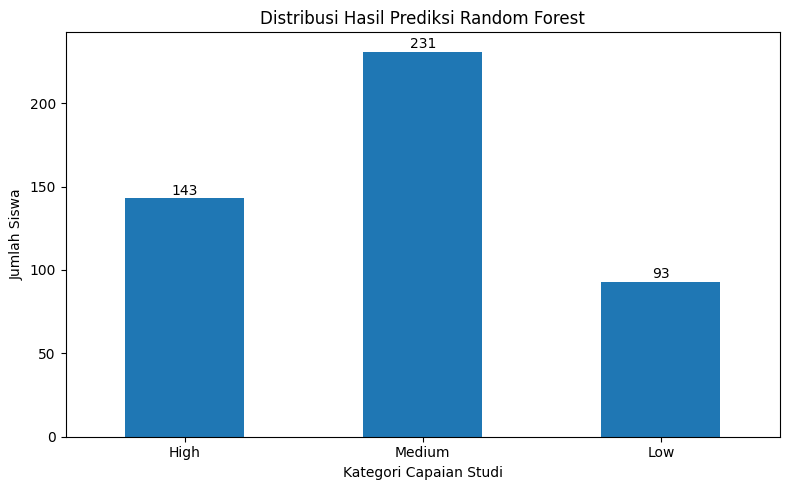

In [ ]:
# ==========================================
# GRAFIK DISTRIBUSI HASIL PREDIKSI
# ==========================================

import matplotlib.pyplot as plt

# Menghitung jumlah masing-masing kategori
jumlah_prediksi = hasil_prediksi_rf["Prediksi"].value_counts()

# Mengatur urutan kategori
urutan_kategori = ["High", "Medium", "Low"]
jumlah_prediksi = jumlah_prediksi.reindex(
    urutan_kategori,
    fill_value=0
)

# Membuat grafik
plt.figure(figsize=(8, 5))
jumlah_prediksi.plot(kind="bar")

plt.title("Distribusi Hasil Prediksi Random Forest")
plt.xlabel("Kategori Capaian Studi")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=0)

# Menampilkan nilai di atas batang
for i, nilai in enumerate(jumlah_prediksi):
    plt.text(i, nilai + 2, str(nilai), ha="center")

plt.tight_layout()
plt.show()

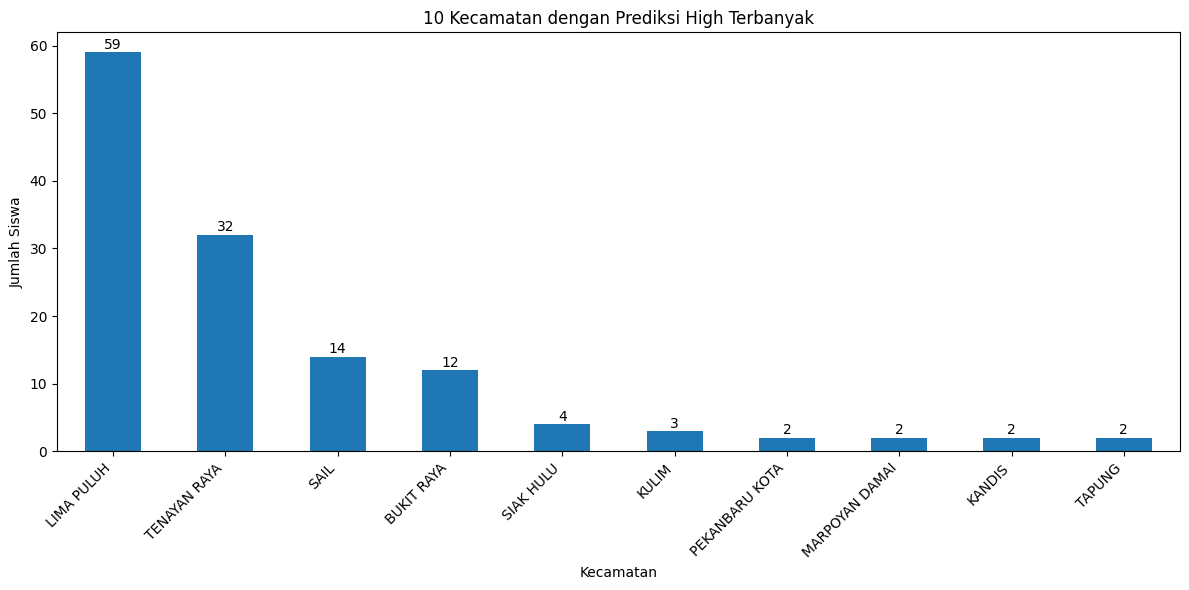

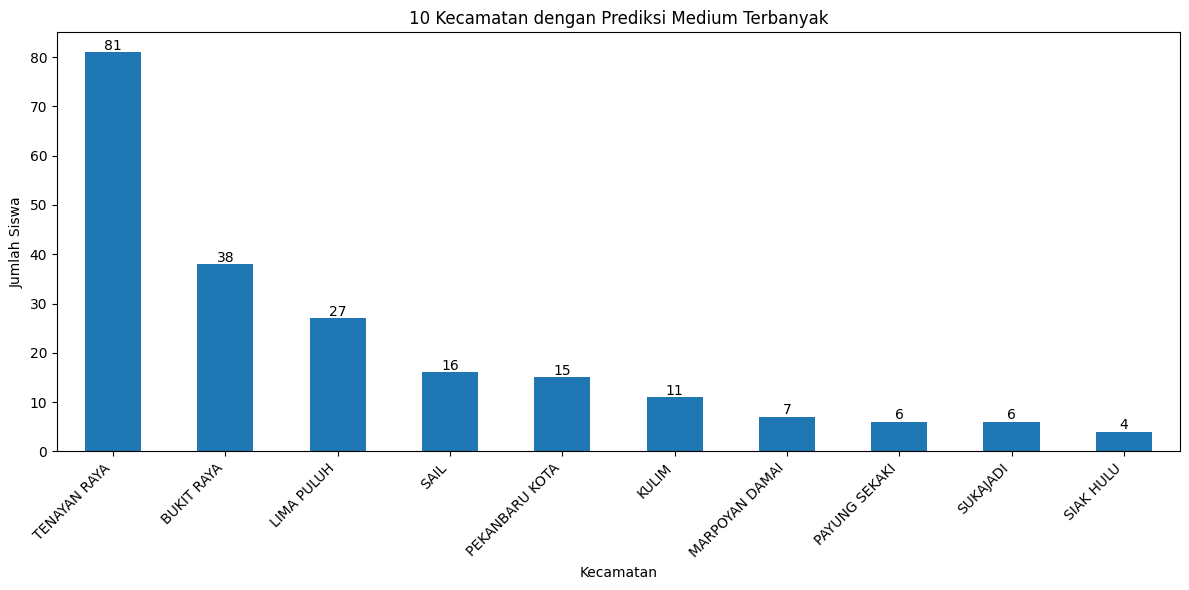

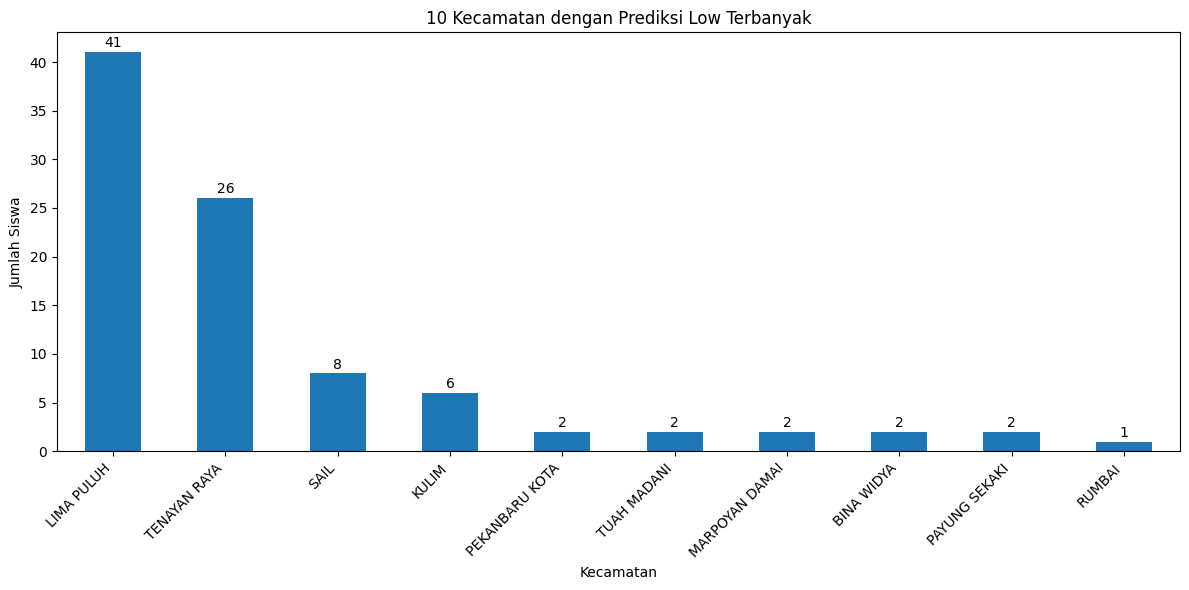

In [ ]:
# ==========================================
# GRAFIK PREDIKSI BERDASARKAN KECAMATAN
# ==========================================

import matplotlib.pyplot as plt

kategori = ["High", "Medium", "Low"]

for kat in kategori:
    data_kategori = hasil_prediksi_rf[
        hasil_prediksi_rf["Prediksi"] == kat
    ]

    jumlah_kecamatan = (
        data_kategori["Kecamatan_Dari_Kelurahan"]
        .value_counts()
        .head(10)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    jumlah_kecamatan.plot(kind="bar")

    plt.title(f"10 Kecamatan dengan Prediksi {kat} Terbanyak")
    plt.xlabel("Kecamatan")
    plt.ylabel("Jumlah Siswa")
    plt.xticks(rotation=45, ha="right")

    # Nilai di atas batang
    for i, nilai in enumerate(jumlah_kecamatan):
        plt.text(i, nilai + 0.5, str(nilai), ha="center")

    plt.tight_layout()
    plt.show()

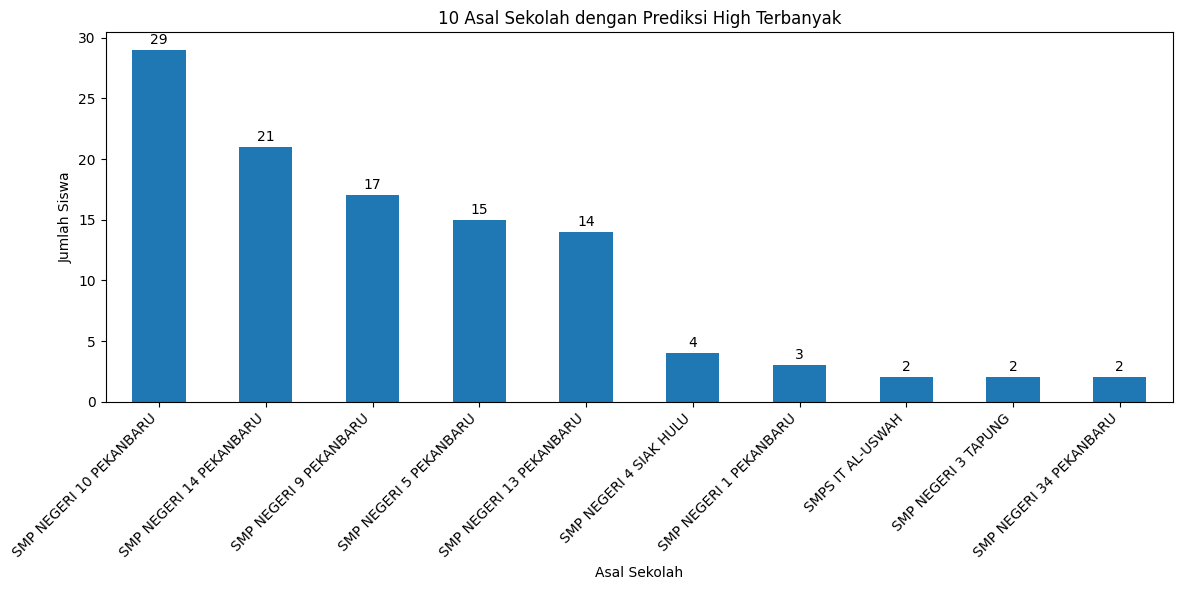

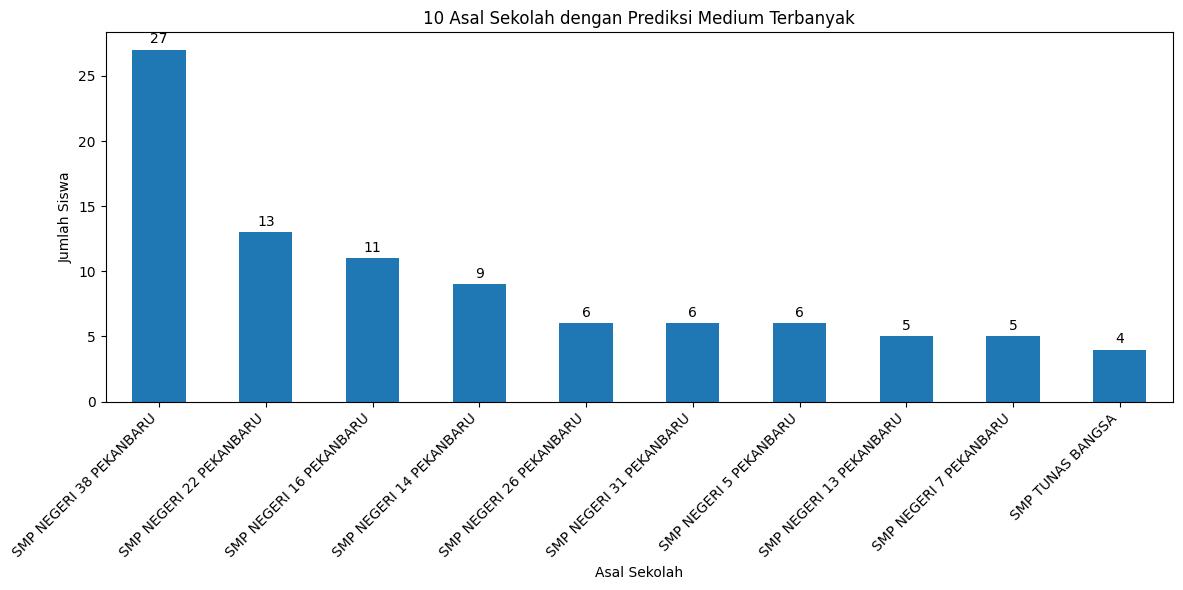

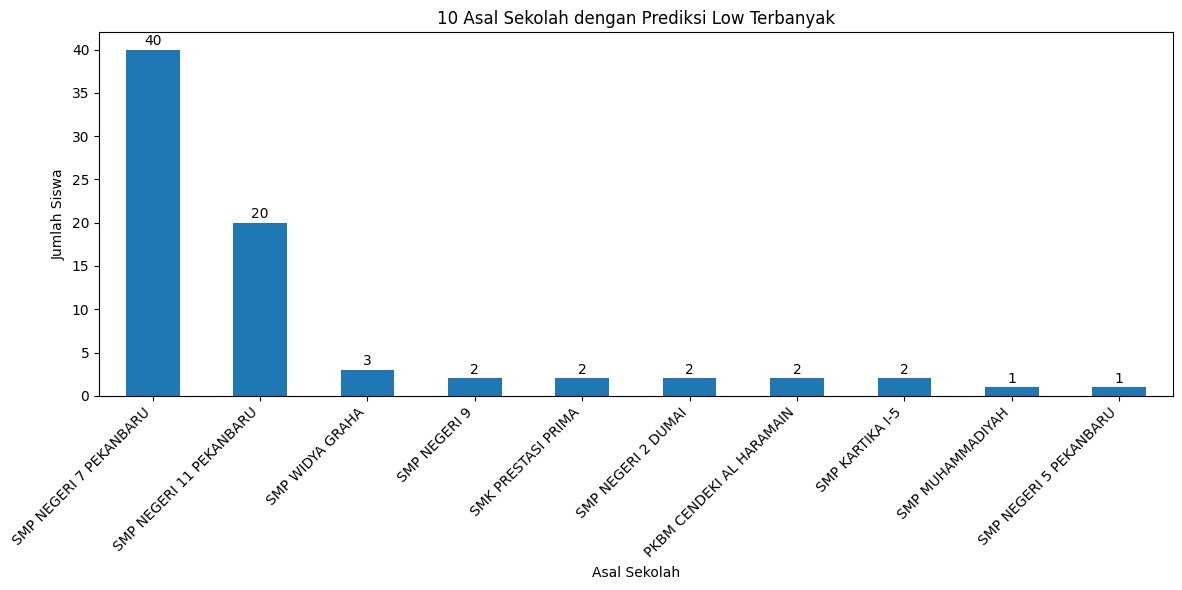

In [ ]:
# ==========================================
# GRAFIK PREDIKSI BERDASARKAN ASAL SEKOLAH
# ==========================================

for kat in kategori:
    data_kategori = hasil_prediksi_rf[
        hasil_prediksi_rf["Prediksi"] == kat
    ]

    jumlah_sekolah = (
        data_kategori["Asal Sekolah"]
        .value_counts()
        .head(10)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    jumlah_sekolah.plot(kind="bar")

    plt.title(f"10 Asal Sekolah dengan Prediksi {kat} Terbanyak")
    plt.xlabel("Asal Sekolah")
    plt.ylabel("Jumlah Siswa")
    plt.xticks(rotation=45, ha="right")

    # Nilai di atas batang
    for i, nilai in enumerate(jumlah_sekolah):
        plt.text(i, nilai + 0.5, str(nilai), ha="center")

    plt.tight_layout()
    plt.show()

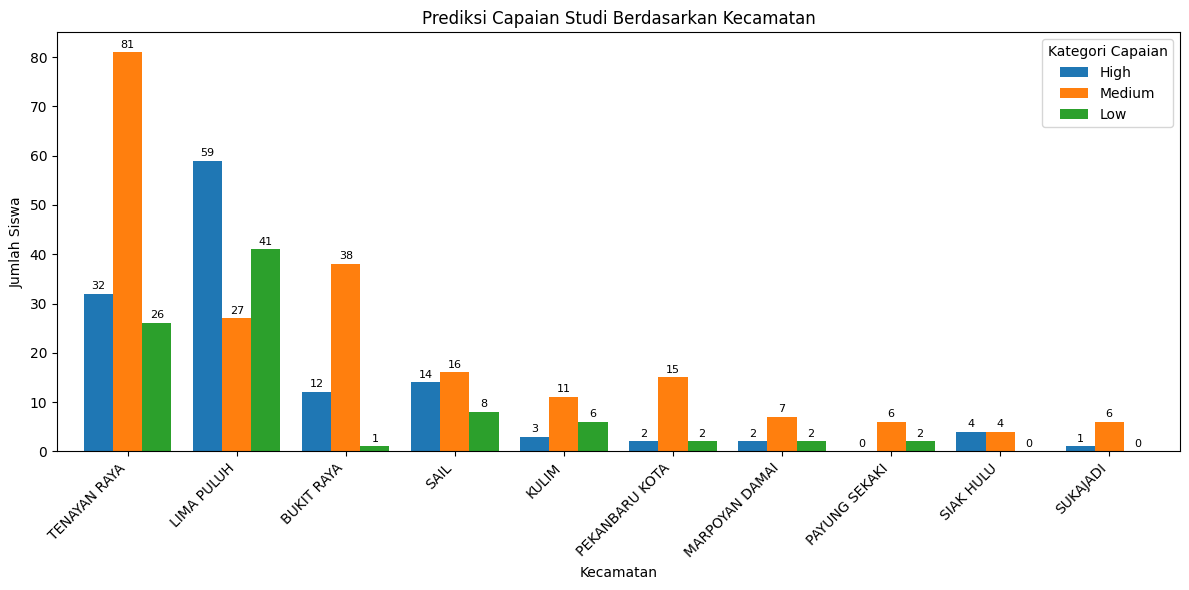

In [ ]:
# ==========================================
# GRAFIK CAPAIAN BERDASARKAN KECAMATAN
# ==========================================

import matplotlib.pyplot as plt

# Tabulasi Kecamatan dan kategori prediksi
data_kecamatan = pd.crosstab(
    hasil_prediksi_rf["Kecamatan_Dari_Kelurahan"],
    hasil_prediksi_rf["Prediksi"]
)

# Memastikan semua kategori tersedia
for kategori in ["High", "Medium", "Low"]:
    if kategori not in data_kecamatan.columns:
        data_kecamatan[kategori] = 0

# Urutan kolom
data_kecamatan = data_kecamatan[["High", "Medium", "Low"]]

# Ambil 10 kecamatan dengan jumlah siswa terbanyak
data_kecamatan["Total"] = data_kecamatan.sum(axis=1)
data_kecamatan = (
    data_kecamatan
    .sort_values("Total", ascending=False)
    .head(10)
    .drop(columns="Total")
)

# Grafik
ax = data_kecamatan.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Prediksi Capaian Studi Berdasarkan Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategori Capaian")

# Menampilkan angka di atas batang
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

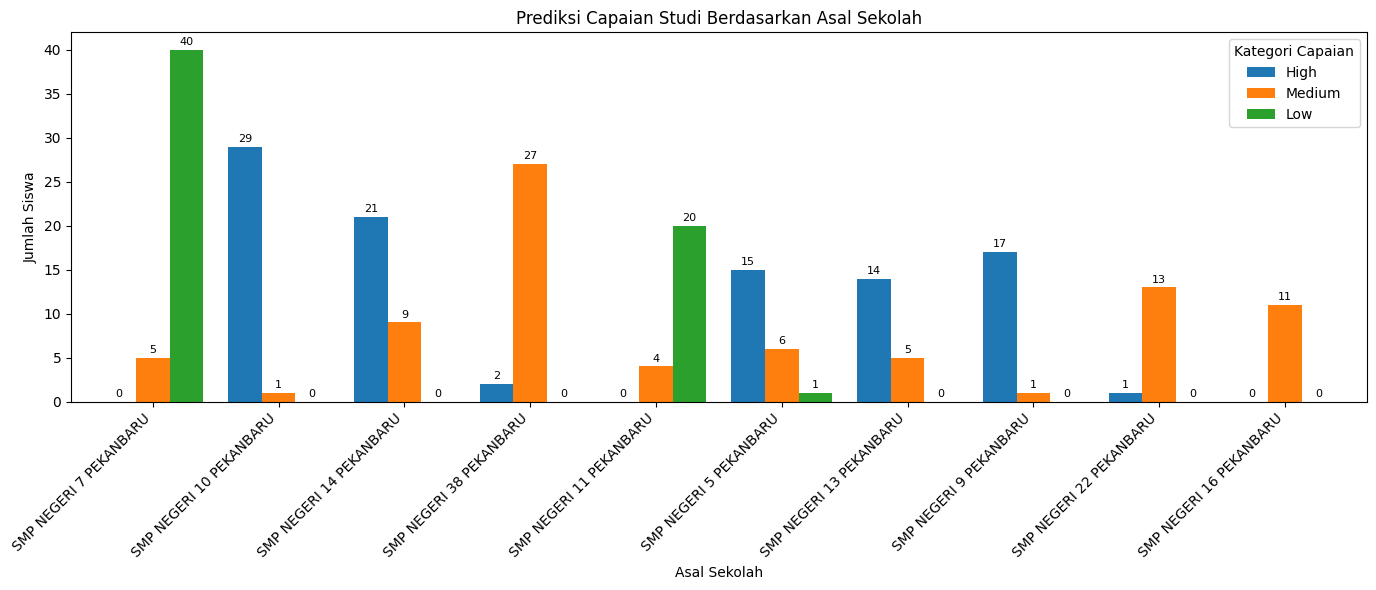

In [ ]:
# ==========================================
# GRAFIK CAPAIAN BERDASARKAN ASAL SEKOLAH
# ==========================================

# Tabulasi Asal Sekolah dan kategori prediksi
data_sekolah = pd.crosstab(
    hasil_prediksi_rf["Asal Sekolah"],
    hasil_prediksi_rf["Prediksi"]
)

# Memastikan semua kategori tersedia
for kategori in ["High", "Medium", "Low"]:
    if kategori not in data_sekolah.columns:
        data_sekolah[kategori] = 0

# Urutan kolom
data_sekolah = data_sekolah[["High", "Medium", "Low"]]

# Ambil 10 sekolah dengan jumlah siswa terbanyak
data_sekolah["Total"] = data_sekolah.sum(axis=1)
data_sekolah = (
    data_sekolah
    .sort_values("Total", ascending=False)
    .head(10)
    .drop(columns="Total")
)

# Grafik
ax = data_sekolah.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Prediksi Capaian Studi Berdasarkan Asal Sekolah")
plt.xlabel("Asal Sekolah")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategori Capaian")

# Menampilkan angka di atas batang
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

SVM

In [ ]:
# ==========================================
# STANDARDISASI UNTUK SVM
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler hanya pada data training
X_train_svm = scaler.fit_transform(X_train_final)

# Transform data testing menggunakan scaler yang sama
X_test_svm = scaler.transform(X_test_final)

print("Standardisasi SVM selesai.")
print("X_train_svm:", X_train_svm.shape)
print("X_test_svm :", X_test_svm.shape)

Standardisasi SVM selesai.
X_train_svm: (3852, 787)
X_test_svm : (467, 787)


In [ ]:
# SUPPORT VECTOR MACHINE (SVM)
from sklearn.svm import SVC
model_svm = SVC(
    kernel="rbf",
    class_weight=None,
    random_state=42
)
# Training menggunakan data hasil SMOTENC
model_svm.fit(
    X_train_svm,
    y_train_balanced
)
# Prediksi
y_pred_svm = model_svm.predict(X_test_svm)
print("SVM selesai dilatih.")

SVM selesai dilatih.


In [ ]:
# ==========================================
# MEMBUAT DATA HASIL PREDIKSI SVM
# ==========================================

hasil_prediksi_svm = X_test.copy()

# Menambahkan hasil prediksi
hasil_prediksi_svm["Prediksi"] = y_pred_svm

print("Data hasil prediksi SVM berhasil dibuat.")
display(hasil_prediksi_svm.head())

Data hasil prediksi SVM berhasil dibuat.


,Asal Sekolah,Kecamatan_Dari_Kelurahan,Frekuensi_Asal_Sekolah,Frekuensi_Kecamatan,Jenis_Sekolah,Asal_Sekolah_Kecamatan,Frekuensi_Asal_Sekolah_Kecamatan,Rasio_Sekolah_Kecamatan,Proporsi_Kombinasi_dalam_Sekolah,Proporsi_Kombinasi_dalam_Kecamatan,Log_Frekuensi_Asal_Sekolah,Log_Frekuensi_Kecamatan,Log_Frekuensi_Kombinasi,Prediksi
879,SMP NEGERI 7 PEKANBARU,PEKANBARU KOTA,177.0,65,SMP_NEGERI,SMP NEGERI 7 PEKANBARU | PEKANBARU KOTA,1.0,2.723077,0.00565,0.015385,5.181784,4.189655,0.693147,Low
711,SMP NEGERI 3 KUALUH LEIDONG,LIMA PULUH,2.0,492,SMP_NEGERI,SMP NEGERI 3 KUALUH LEIDONG | LIMA PULUH,2.0,0.004065,1.00000,0.004065,1.098612,6.200509,1.098612,High
1841,SMP NEGERI 3 SATAP PANAI TENGAH,TENAYAN RAYA,3.0,643,SMP_NEGERI,SMP NEGERI 3 SATAP PANAI TENGAH | TENAYAN RAYA,3.0,0.004666,1.00000,0.004666,1.386294,6.467699,1.386294,Medium
2083,SMP NEGERI 1 PERHENTIAN RAJA,PERHENTIAN RAJA,1.0,3,SMP_NEGERI,SMP NEGERI 1 PERHENTIAN RAJA | PERHENTIAN RAJA,1.0,0.333333,1.00000,0.333333,0.693147,1.386294,0.693147,Medium
1462,SMP NEGERI 11 PEKANBARU,TENAYAN RAYA,125.0,643,SMP_NEGERI,SMP NEGERI 11 PEKANBARU | TENAYAN RAYA,110.0,0.194401,0.88000,0.171073,4.836282,6.467699,4.709530,Low


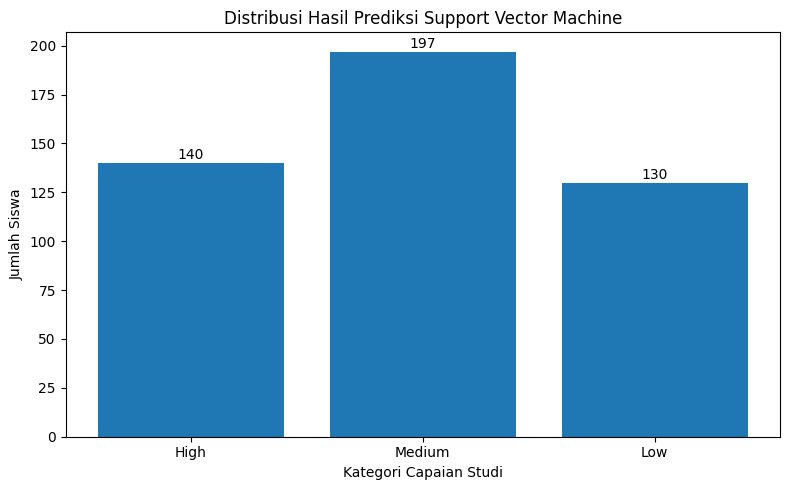

In [ ]:
# ==========================================
# DISTRIBUSI HASIL PREDIKSI SVM
# ==========================================

import matplotlib.pyplot as plt

# Menghitung jumlah masing-masing kategori
jumlah_prediksi_svm = (
    hasil_prediksi_svm["Prediksi"]
    .value_counts()
    .reindex(["High", "Medium", "Low"], fill_value=0)
)

# Membuat grafik
plt.figure(figsize=(8, 5))

bars = plt.bar(
    jumlah_prediksi_svm.index,
    jumlah_prediksi_svm.values
)

plt.title("Distribusi Hasil Prediksi Support Vector Machine")
plt.xlabel("Kategori Capaian Studi")
plt.ylabel("Jumlah Siswa")

# Menampilkan jumlah di atas batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        tinggi + 2,
        str(int(tinggi)),
        ha="center"
    )

plt.tight_layout()
plt.show()

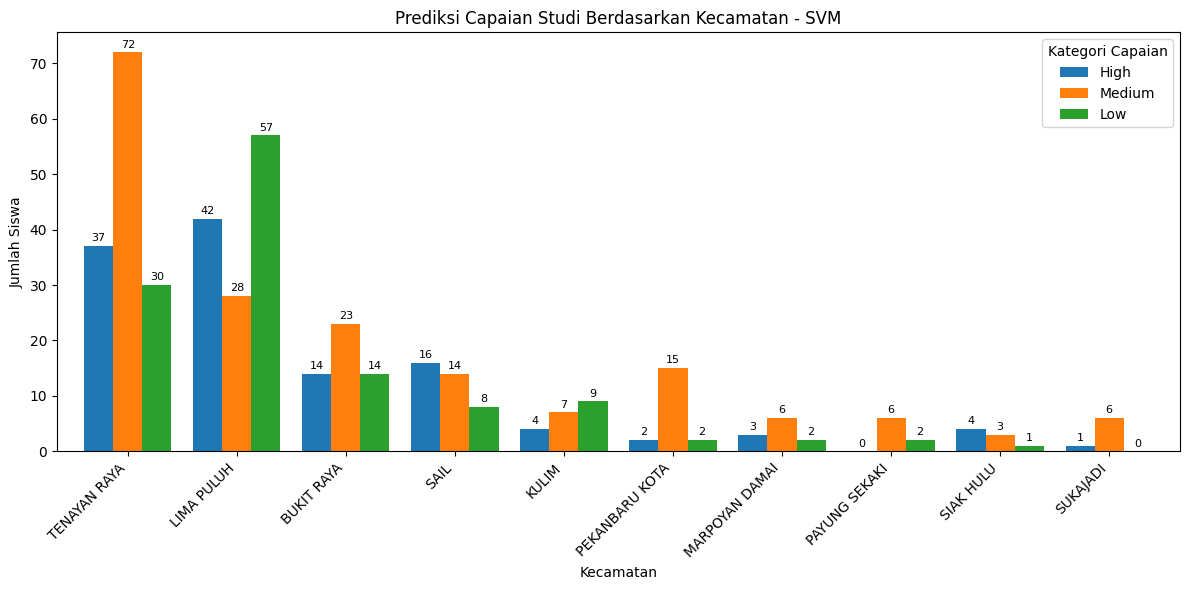

In [ ]:
# ==========================================
# DISTRIBUSI PREDIKSI CAPAIAN STUDI
# BERDASARKAN KECAMATAN - SVM
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Tabulasi Kecamatan dan kategori prediksi
data_kecamatan_svm = pd.crosstab(
    hasil_prediksi_svm["Kecamatan_Dari_Kelurahan"],
    hasil_prediksi_svm["Prediksi"]
)

# Memastikan semua kategori tersedia
for kategori in ["High", "Medium", "Low"]:
    if kategori not in data_kecamatan_svm.columns:
        data_kecamatan_svm[kategori] = 0

# Urutan kategori
data_kecamatan_svm = data_kecamatan_svm[
    ["High", "Medium", "Low"]
]

# Mengambil 10 kecamatan dengan jumlah siswa terbanyak
data_kecamatan_svm["Total"] = data_kecamatan_svm.sum(axis=1)

data_kecamatan_svm = (
    data_kecamatan_svm
    .sort_values("Total", ascending=False)
    .head(10)
    .drop(columns="Total")
)

# Membuat grafik
ax = data_kecamatan_svm.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Prediksi Capaian Studi Berdasarkan Kecamatan - SVM")
plt.xlabel("Kecamatan")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategori Capaian")

# Menampilkan nilai di atas setiap batang
for container in ax.containers:
    ax.bar_label(
        container,
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

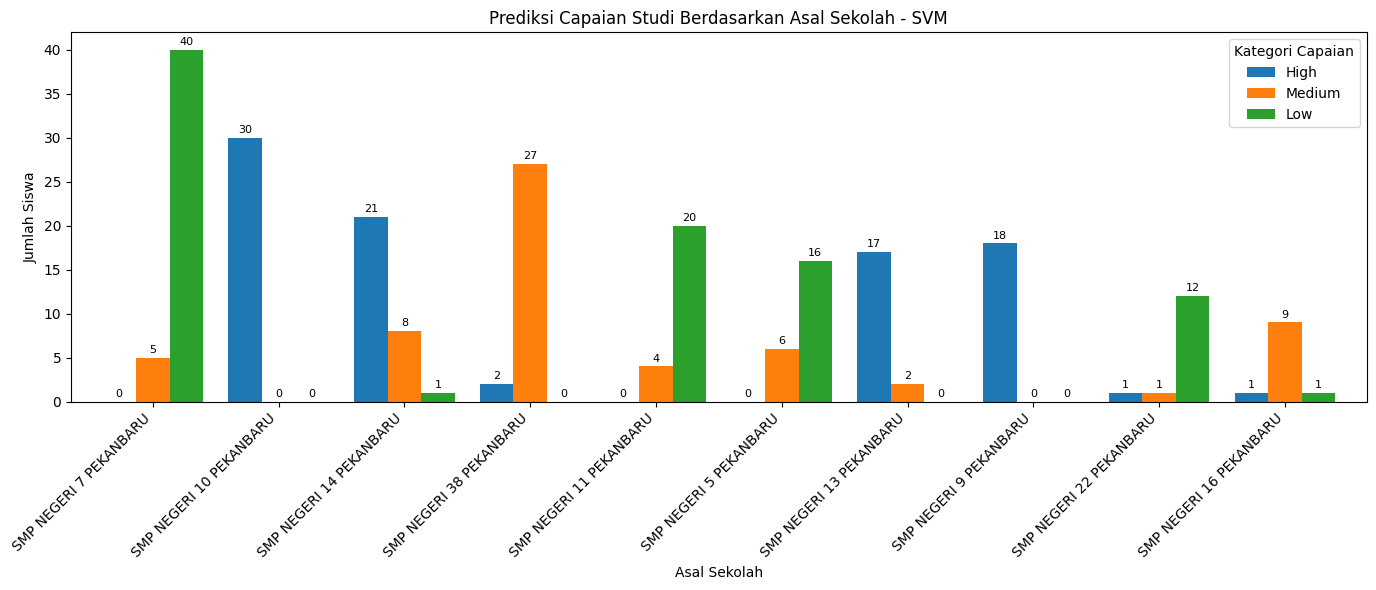

In [ ]:
# ==========================================
# DISTRIBUSI PREDIKSI CAPAIAN STUDI
# BERDASARKAN ASAL SEKOLAH - SVM
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Tabulasi Asal Sekolah dan kategori prediksi
data_sekolah_svm = pd.crosstab(
    hasil_prediksi_svm["Asal Sekolah"],
    hasil_prediksi_svm["Prediksi"]
)

# Memastikan semua kategori tersedia
for kategori in ["High", "Medium", "Low"]:
    if kategori not in data_sekolah_svm.columns:
        data_sekolah_svm[kategori] = 0

# Urutan kategori
data_sekolah_svm = data_sekolah_svm[
    ["High", "Medium", "Low"]
]

# Mengambil 10 sekolah dengan jumlah siswa terbanyak
data_sekolah_svm["Total"] = data_sekolah_svm.sum(axis=1)

data_sekolah_svm = (
    data_sekolah_svm
    .sort_values("Total", ascending=False)
    .head(10)
    .drop(columns="Total")
)

# Membuat grafik
ax = data_sekolah_svm.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Prediksi Capaian Studi Berdasarkan Asal Sekolah - SVM")
plt.xlabel("Asal Sekolah")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategori Capaian")

# Menampilkan nilai di atas batang
for container in ax.containers:
    ax.bar_label(
        container,
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

# Evaluasi

=== EVALUASI RANDOM FOREST ===

Accuracy:
0.591

Classification Report:
              precision    recall  f1-score   support

        High     0.4685    0.5982    0.5255       112
         Low     0.1828    0.5000    0.2677        34
      Medium     0.8312    0.5981    0.6957       321

    accuracy                         0.5910       467
   macro avg     0.4942    0.5654    0.4963       467
weighted avg     0.6970    0.5910    0.6237       467



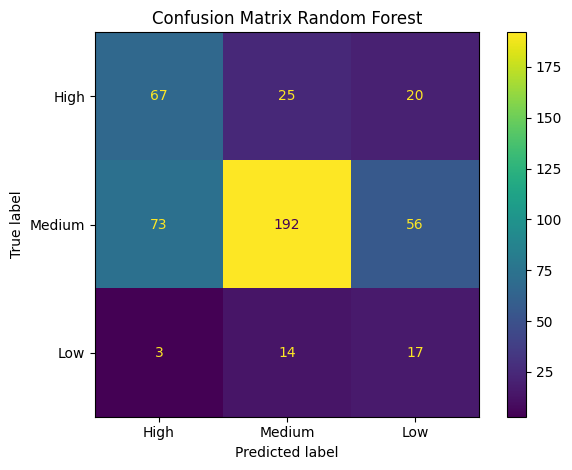

In [ ]:
# ==========================================
# EVALUASI RANDOM FOREST
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("=== EVALUASI RANDOM FOREST ===")
print("\nAccuracy:")
print(round(accuracy_rf, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    digits=4
))

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["High", "Medium", "Low"]
)

disp.plot()
plt.title("Confusion Matrix Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# ==========================================
# TUNING RANDOM FOREST - FOKUS KELAS LOW
# ==========================================

param_grid_rf_low = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],

    "class_weight": [
        "balanced",
        {
            "High": 1.0,
            "Medium": 1.0,
            "Low": 1.5
        },
        {
            "High": 1.0,
            "Medium": 1.0,
            "Low": 2.0
        },
        {
            "High": 1.0,
            "Medium": 1.0,
            "Low": 2.5
        }
    ]
}

rf_base_low = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_rf_low = GridSearchCV(
    estimator=rf_base_low,
    param_grid=param_grid_rf_low,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_rf_low.fit(
    X_train_final,
    y_train_balanced
)

print("=" * 60)
print("HASIL TUNING RANDOM FOREST - FOKUS LOW")
print("=" * 60)

print("\nParameter terbaik:")
print(grid_rf_low.best_params_)

print("\nMacro F1 terbaik:")
print(round(grid_rf_low.best_score_, 4))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
HASIL TUNING RANDOM FOREST - FOKUS LOW

Parameter terbaik:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Macro F1 terbaik:
0.7385


In [237]:
# ==========================================
# EVALUASI RANDOM FOREST TERBAIK
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

best_rf_low = grid_rf_low.best_estimator_

y_pred_rf_low = best_rf_low.predict(X_test_final)

print("=" * 60)
print("EVALUASI RANDOM FOREST - FOKUS LOW")
print("=" * 60)

print("\nAccuracy:")
print(round(
    accuracy_score(y_test, y_pred_rf_low), 4
))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf_low,
        labels=["High", "Medium", "Low"],
        digits=4
    )
)

EVALUASI RANDOM FOREST - FOKUS LOW

Accuracy:
0.591

Classification Report:
              precision    recall  f1-score   support

        High     0.4685    0.5982    0.5255       112
      Medium     0.8312    0.5981    0.6957       321
         Low     0.1828    0.5000    0.2677        34

    accuracy                         0.5910       467
   macro avg     0.4942    0.5654    0.4963       467
weighted avg     0.6970    0.5910    0.6237       467



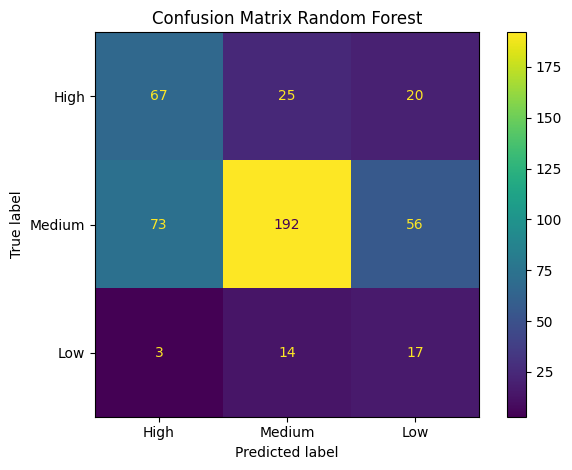

In [238]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["High", "Medium", "Low"]
)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["High", "Medium", "Low"]
)

disp_rf.plot()

plt.title("Confusion Matrix Random Forest")
plt.tight_layout()
plt.show()

=== EVALUASI SVM ===

Accuracy:
0.5675

Classification Report:
              precision    recall  f1-score   support

        High     0.5000    0.6250    0.5556       112
         Low     0.1692    0.6471    0.2683        34
      Medium     0.8782    0.5389    0.6680       321

    accuracy                         0.5675       467
   macro avg     0.5158    0.6037    0.4973       467
weighted avg     0.7359    0.5675    0.6119       467



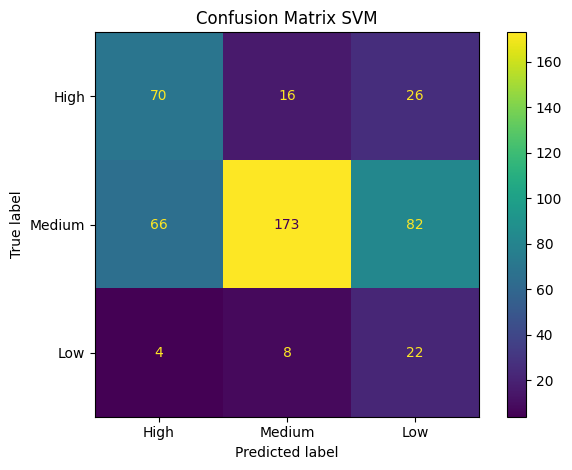

In [239]:
# ==========================================
# EVALUASI SVM
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("=== EVALUASI SVM ===")

print("\nAccuracy:")
print(round(accuracy_svm, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        digits=4
    )
)

# Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["High", "Medium", "Low"]
)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["High", "Medium", "Low"]
)

disp_svm.plot()
plt.title("Confusion Matrix SVM")
plt.tight_layout()
plt.show()

In [240]:
# ==========================================
# HYPERPARAMETER TUNING SVM
# ==========================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Standardisasi
scaler_svm = StandardScaler()

X_train_svm = scaler_svm.fit_transform(
    X_train_final
)

X_test_svm = scaler_svm.transform(
    X_test_final
)

# Parameter SVM
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "kernel": ["rbf"],
    "class_weight": [None, "balanced"]
}

svm_base = SVC(
    random_state=42
)

grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(
    X_train_svm,
    y_train_balanced
)

print("=" * 60)
print("HASIL TUNING SVM")
print("=" * 60)

print("\nParameter terbaik:")
print(grid_svm.best_params_)

print("\nMacro F1 terbaik:")
print(round(grid_svm.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
HASIL TUNING SVM

Parameter terbaik:
{'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

Macro F1 terbaik:
0.7235


In [241]:
# ==========================================
# EVALUASI SVM TERBAIK
# ==========================================

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(
    X_test_svm
)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="macro"
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="macro"
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print("=" * 60)
print("EVALUASI SVM")
print("=" * 60)

print(f"\nAccuracy     : {accuracy_svm:.4f}")
print(f"Precision    : {precision_svm:.4f}")
print(f"Recall       : {recall_svm:.4f}")
print(f"Macro F1     : {f1_svm:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=["High", "Medium", "Low"],
        digits=4
    )
)

EVALUASI SVM

Accuracy     : 0.5889
Precision    : 0.5122
Recall       : 0.6121
Macro F1     : 0.5117

Classification Report:
              precision    recall  f1-score   support

        High     0.4694    0.6161    0.5328       112
      Medium     0.8598    0.5732    0.6879       321
         Low     0.2075    0.6471    0.3143        34

    accuracy                         0.5889       467
   macro avg     0.5122    0.6121    0.5117       467
weighted avg     0.7187    0.5889    0.6235       467



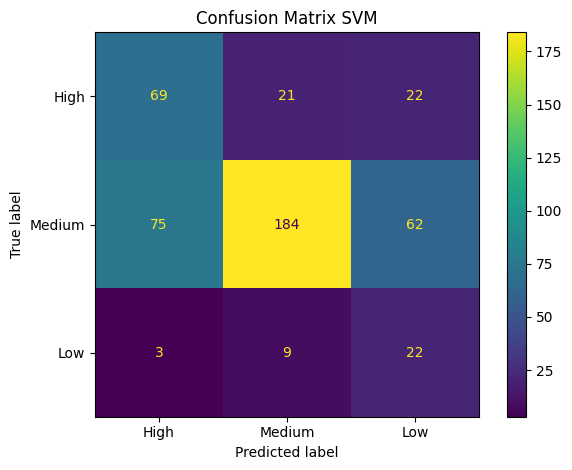

In [242]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["High", "Medium", "Low"]
)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["High", "Medium", "Low"]
)

disp_svm.plot()

plt.title("Confusion Matrix SVM")
plt.tight_layout()
plt.show()

In [245]:
# ============================================================
# PERBANDINGAN RANDOM FOREST VS SVM
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

hasil_perbandingan = pd.DataFrame({
    "Model": [
        "Random Forest - Fokus Low",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_low),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision Macro": [
        precision_score(
            y_test, y_pred_rf_low,
            average="macro", zero_division=0
        ),
        precision_score(
            y_test, y_pred_svm,
            average="macro", zero_division=0
        )
    ],

    "Recall Macro": [
        recall_score(
            y_test, y_pred_rf_low,
            average="macro", zero_division=0
        ),
        recall_score(
            y_test, y_pred_svm,
            average="macro", zero_division=0
        )
    ],

    "F1 Macro": [
        f1_score(
            y_test, y_pred_rf_low,
            average="macro", zero_division=0
        ),
        f1_score(
            y_test, y_pred_svm,
            average="macro", zero_division=0
        )
    ]
})

hasil_perbandingan = hasil_perbandingan.round(4)

display(hasil_perbandingan)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest - Fokus Low,0.5910,0.4942,0.5654,0.4963
1,SVM,0.5889,0.5122,0.6121,0.5117


In [246]:
# ==========================================
# PERFORMA SETIAP KELAS
# ==========================================

report_rf = classification_report(
    y_test,
    y_pred_rf,
    labels=["High", "Medium", "Low"],
    output_dict=True
)

report_svm = classification_report(
    y_test,
    y_pred_svm,
    labels=["High", "Medium", "Low"],
    output_dict=True
)

hasil_kelas = pd.DataFrame({
    "Kelas": ["High", "Medium", "Low"],

    "RF Precision": [
        report_rf["High"]["precision"],
        report_rf["Medium"]["precision"],
        report_rf["Low"]["precision"]
    ],

    "RF Recall": [
        report_rf["High"]["recall"],
        report_rf["Medium"]["recall"],
        report_rf["Low"]["recall"]
    ],

    "RF F1": [
        report_rf["High"]["f1-score"],
        report_rf["Medium"]["f1-score"],
        report_rf["Low"]["f1-score"]
    ],

    "SVM Precision": [
        report_svm["High"]["precision"],
        report_svm["Medium"]["precision"],
        report_svm["Low"]["precision"]
    ],

    "SVM Recall": [
        report_svm["High"]["recall"],
        report_svm["Medium"]["recall"],
        report_svm["Low"]["recall"]
    ],

    "SVM F1": [
        report_svm["High"]["f1-score"],
        report_svm["Medium"]["f1-score"],
        report_svm["Low"]["f1-score"]
    ]
})

hasil_kelas = hasil_kelas.round(4)

display(hasil_kelas)

,Kelas,RF Precision,RF Recall,RF F1,SVM Precision,SVM Recall,SVM F1
0,High,0.4685,0.5982,0.5255,0.4694,0.6161,0.5328
1,Medium,0.8312,0.5981,0.6957,0.8598,0.5732,0.6879
2,Low,0.1828,0.5000,0.2677,0.2075,0.6471,0.3143
